<a href="https://colab.research.google.com/github/Karthikreddy1010/Microplastic_Image_Segmentation/blob/main/Efficientv2B31.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! unzip /content/archive.zip

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras import mixed_precision
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sklearn.metrics import precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
from scipy import stats
import pandas as pd
from skimage.transform import rotate, resize
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# GPU SETUP
# ============================================================================

# Confirm GPU
gpus = tf.config.list_physical_devices('GPU')
assert len(gpus) > 0, "❌ No GPU detected!"
print("✅ GPU detected:", gpus)

# Enable memory growth
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# Enable mixed precision
mixed_precision.set_global_policy('mixed_float16')
print("✅ Mixed precision enabled")

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Configuration
IMG_HEIGHT = 512
IMG_WIDTH = 512
BATCH_SIZE = 4
EPOCHS = 100
PATIENCE = 15

# Paths to your data
TRAIN_IMAGE_DIR = '/content/training/training/Training_original'
TRAIN_MASK_DIR = '/content/training/training/Finalmasks'
VAL_IMAGE_DIR = '/content/val/val/Original'
VAL_MASK_DIR = '/content/val/val/val_100masks'
TEST_IMAGE_DIR = '/content/Testing/Testing/Original'
TEST_MASK_DIR = '/content/Testing/Testing/testing_100masks'

# CSV file paths for ground-truth counts
TRAIN_COUNT_CSV = '/content/GT_train.csv'
VAL_COUNT_CSV = '/content/GT_valid.csv'
TEST_COUNT_CSV = '/content/GT_Test.csv'

# ============================================================================
# 1. FILENAME NORMALIZATION
# ============================================================================

def normalize_name(name):
    """Normalize filename for matching."""
    name = os.path.basename(name)
    name = os.path.splitext(name)[0]
    name = name.replace('_mask', '')
    return name

# ============================================================================
# 2. PREPROCESSING FUNCTIONS
# ============================================================================

def preprocess_mask(mask):
    """Proper mask binarization."""
    mask_binary = (mask > 127).astype(np.float32)
    return mask_binary

# ============================================================================
# 3. PARTICLE COUNTING FUNCTIONS
# ============================================================================

def count_particles_watershed(binary_mask, min_distance=10):
    """Watershed splitting with adaptive marker threshold."""
    if binary_mask.dtype != np.uint8:
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

    if binary_mask.sum() == 0:
        return 0, np.zeros_like(binary_mask)

    # Distance transform
    distance = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)

    # Adaptive marker threshold
    if distance.max() > 0:
        non_zero_dist = distance[distance > 0]
        if len(non_zero_dist) > 10:
            thresh_value = np.percentile(non_zero_dist, 70)
        else:
            thresh_value = 0.4 * distance.max()
    else:
        thresh_value = 0

    _, sure_fg = cv2.threshold(distance, thresh_value, 255, 0)
    sure_fg = sure_fg.astype(np.uint8)

    # Watershed setup
    sure_bg = cv2.dilate(binary_mask, np.ones((3, 3), np.uint8), iterations=3)
    unknown = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    # Apply watershed
    binary_rgb = cv2.cvtColor(binary_mask * 255, cv2.COLOR_GRAY2BGR)
    markers = cv2.watershed(binary_rgb, markers)

    # Count markers
    unique_markers = np.unique(markers)
    count = len([m for m in unique_markers if m > 1])

    return count, markers

def count_particles_cc(binary_mask, use_watershed=True):
    """Count particles using connected components with watershed."""
    binary_mask = binary_mask.squeeze()

    if binary_mask.dtype != np.uint8:
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

    if binary_mask.sum() == 0:
        return 0

    if use_watershed:
        count, _ = count_particles_watershed(binary_mask)
        return count
    else:
        num_labels, _ = cv2.connectedComponents(binary_mask, connectivity=8)
        return num_labels - 1

def calculate_counting_metrics(gt_counts, pred_counts, tol=1.0):
    """Calculate comprehensive counting metrics."""
    gt_counts = np.asarray(gt_counts).flatten()
    pred_counts = np.asarray(pred_counts).flatten()

    # Basic regression metrics
    mae = mean_absolute_error(gt_counts, pred_counts)
    rmse = np.sqrt(mean_squared_error(gt_counts, pred_counts))
    bias = np.mean(pred_counts - gt_counts)

    # Pearson correlation
    if len(gt_counts) > 1 and np.std(gt_counts) > 0 and np.std(pred_counts) > 0:
        pearson_r = np.corrcoef(gt_counts, pred_counts)[0, 1]
    else:
        pearson_r = 0.0

    # Tolerance accuracy
    tol_acc = np.mean(np.abs(pred_counts - gt_counts) <= tol) * 100

    return {
        'mae': mae,
        'rmse': rmse,
        'bias': bias,
        'pearson_r': pearson_r,
        'tol_acc': tol_acc,
        'total_images': len(gt_counts)
    }

# ============================================================================
# 4. SEGMENTATION METRICS FUNCTIONS
# ============================================================================

def calculate_iou(y_true, y_pred):
    """Calculate Intersection over Union for binary masks."""
    y_true = y_true.flatten().astype(np.uint8)
    y_pred = y_pred.flatten().astype(np.uint8)

    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection

    if union == 0:
        return 0.0

    return intersection / union

def calculate_miou(y_true, y_pred):
    """Calculate mean Intersection over Union for both classes."""
    y_true = y_true.flatten().astype(np.uint8)
    y_pred = y_pred.flatten().astype(np.uint8)

    iou_class_0 = calculate_iou(1 - y_true, 1 - y_pred)  # Background
    iou_class_1 = calculate_iou(y_true, y_pred)           # Foreground

    miou = (iou_class_0 + iou_class_1) / 2.0

    return {
        'iou_background': iou_class_0,
        'iou_foreground': iou_class_1,
        'miou': miou
    }

def calculate_segmentation_metrics(y_true, y_pred_binary):
    """Calculate pixel-wise segmentation metrics."""
    y_true_flat = y_true.flatten().astype(np.uint8)
    y_pred_flat = y_pred_binary.flatten().astype(np.uint8)

    precision = precision_score(y_true_flat, y_pred_flat, zero_division=0)
    recall = recall_score(y_true_flat, y_pred_flat, zero_division=0)
    f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)

    intersection = np.sum(y_true_flat * y_pred_flat)
    dice = (2. * intersection) / (np.sum(y_true_flat) + np.sum(y_pred_flat) + 1e-8)

    miou_metrics = calculate_miou(y_true_flat, y_pred_flat)

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'dice': dice,
        'iou_background': miou_metrics['iou_background'],
        'iou_foreground': miou_metrics['iou_foreground'],
        'miou': miou_metrics['miou']
    }

# ============================================================================
# 5. POST-PROCESSING PIPELINE
# ============================================================================

def remove_border_objects(binary_mask, border_width=5):
    """Remove objects touching image borders."""
    h, w = binary_mask.shape

    if binary_mask.dtype != np.uint8:
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

    if binary_mask.sum() == 0:
        return binary_mask

    num_labels, labels = cv2.connectedComponents(binary_mask, connectivity=8)

    if num_labels <= 1:
        return binary_mask

    # Create border mask
    border_mask = np.zeros_like(binary_mask)
    border_mask[:border_width, :] = 1
    border_mask[-border_width:, :] = 1
    border_mask[:, :border_width] = 1
    border_mask[:, -border_width:] = 1

    # Remove objects touching borders
    output = binary_mask.copy()
    for i in range(1, num_labels):
        obj_mask = (labels == i).astype(bool)
        if np.any(obj_mask & border_mask):
            output[obj_mask] = 0

    return output.astype(np.uint8)

def adaptive_min_area_filtering(binary_mask, percentile=3):
    """Remove very small noise components."""
    if binary_mask.sum() == 0:
        return binary_mask

    num_labels, labels = cv2.connectedComponents(binary_mask, connectivity=8)

    if num_labels <= 1:
        return binary_mask

    # Calculate areas
    areas = [np.sum(labels == i) for i in range(1, num_labels)]
    areas = np.array(areas)

    # Calculate min area from percentile
    if len(areas) > 5:
        min_area = np.percentile(areas, percentile)
    else:
        min_area = np.min(areas) * 0.5

    # Filter components
    filtered_mask = np.zeros_like(binary_mask)
    for i in range(1, num_labels):
        area = areas[i-1]
        if area >= min_area:
            filtered_mask[labels == i] = 1

    return filtered_mask

def confidence_noise_suppression(binary_mask, prob_map, threshold=0.3):
    """Suppress low-confidence components."""
    if binary_mask.sum() == 0:
        return binary_mask

    num_labels, labels = cv2.connectedComponents(binary_mask, connectivity=8)

    if num_labels <= 1:
        return binary_mask

    cleaned_mask = binary_mask.copy()
    for i in range(1, num_labels):
        component_mask = (labels == i)
        component_prob = np.mean(prob_map[component_mask])
        if component_prob < threshold:
            cleaned_mask[component_mask] = 0

    return cleaned_mask

def stable_postprocessing(predictions, threshold=0.3):
    """Apply stable post-processing pipeline."""
    processed = []

    for pred in predictions:
        pred_prob = pred.squeeze()

        # Step 1: Fixed threshold
        binary_pred = (pred_prob > threshold).astype(np.uint8)

        if binary_pred.sum() == 0:
            processed.append(np.zeros_like(binary_pred, dtype=np.float32))
            continue

        # Step 2: Remove border objects
        binary_no_border = remove_border_objects(binary_pred, border_width=5)

        if binary_no_border.sum() == 0:
            processed.append(np.zeros_like(binary_no_border, dtype=np.float32))
            continue

        # Step 3: Morphological cleaning
        kernel = np.ones((2, 2), np.uint8)
        cleaned = cv2.morphologyEx(binary_no_border, cv2.MORPH_OPEN, kernel)
        cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

        if cleaned.sum() == 0:
            processed.append(np.zeros_like(cleaned, dtype=np.float32))
            continue

        # Step 4: Size filtering
        size_filtered = adaptive_min_area_filtering(cleaned, percentile=3)

        if size_filtered.sum() == 0:
            processed.append(np.zeros_like(size_filtered, dtype=np.float32))
            continue

        # Step 5: Confidence filtering
        final_mask = confidence_noise_suppression(size_filtered, pred_prob, threshold=0.3)

        processed.append(final_mask.astype(np.float32))

    return np.array(processed)[..., np.newaxis].astype(np.float32)

# ============================================================================
# 6. DATA AUGMENTATION FUNCTIONS
# ============================================================================

def augment_geometric_numpy(image, mask, seed=None):
    """Apply geometric augmentations (rotation, zoom, flip) with consistent randomness."""
    # Convert TensorFlow tensors to numpy arrays
    if hasattr(image, 'numpy'):
        image = image.numpy()
    if hasattr(mask, 'numpy'):
        mask = mask.numpy()

    # Ensure numpy arrays
    image = np.asarray(image, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)

    if seed is not None:
        np.random.seed(seed)

    h, w = image.shape[:2]

    # Random rotation
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-30, 30)
        image = rotate(image, angle, mode='reflect', preserve_range=True)
        mask = rotate(mask, angle, mode='reflect', preserve_range=True)

    # Random zoom
    if np.random.rand() < 0.5:
        zoom_factor = np.random.uniform(0.8, 1.2)
        new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)

        image_zoomed = resize(image, (new_h, new_w), preserve_range=True, anti_aliasing=True)
        mask_zoomed = resize(mask, (new_h, new_w), preserve_range=True, anti_aliasing=False, order=0)

        # Center crop or pad to original size
        if zoom_factor > 1.0:  # Crop
            start_h = (new_h - h) // 2
            start_w = (new_w - w) // 2
            image = image_zoomed[start_h:start_h+h, start_w:start_w+w]
            mask = mask_zoomed[start_h:start_h+h, start_w:start_w+w]
        else:  # Pad
            pad_h = (h - new_h) // 2
            pad_w = (w - new_w) // 2

            # Handle different mask dimensions
            if len(mask_zoomed.shape) == 3:
                # Mask has channel dimension
                image = np.pad(image_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                              mode='reflect')
                mask = np.pad(mask_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                             mode='constant', constant_values=0)
            else:
                # Mask is 2D (height, width only)
                image = np.pad(image_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                              mode='reflect')
                mask = np.pad(mask_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w)),
                             mode='constant', constant_values=0)

    # Random horizontal flip
    if np.random.rand() < 0.5:
        image = np.fliplr(image)
        mask = np.fliplr(mask)

    # Random vertical flip
    if np.random.rand() < 0.5:
        image = np.flipud(image)
        mask = np.flipud(mask)

    # Ensure mask keeps its original shape
    if len(mask.shape) == 2:
        mask = np.expand_dims(mask, axis=-1)

    return image.astype(np.float32), mask.astype(np.float32)


def augment_photometric_numpy(image, seed=None):
    """Apply photometric augmentations to image only - works on [0, 1] range."""
    # Convert TensorFlow tensor to numpy array
    if hasattr(image, 'numpy'):
        image = image.numpy()

    # Ensure numpy array
    image = np.asarray(image, dtype=np.float32)

    if seed is not None:
        np.random.seed(seed)

    # Random brightness (±0.15)
    brightness = np.random.uniform(-0.15, 0.15)
    image = image + brightness

    # Random contrast (0.85 to 1.15)
    contrast = np.random.uniform(0.85, 1.15)
    mean = image.mean()
    image = (image - mean) * contrast + mean

    # Random gamma (0.85 to 1.15)
    gamma = np.random.uniform(0.85, 1.15)
    image = np.power(np.clip(image, 0, 1), gamma)

    # Very mild Gaussian noise (sigma=0.01)
    noise = np.random.normal(0, 0.01, image.shape).astype(np.float32)
    image = image + noise

    # Clip to valid range [0, 1]
    image = np.clip(image, 0, 1)

    return image.astype(np.float32)


def augment_combined_numpy(image, mask):
    """Combined augmentation pipeline - works on [0, 1] range."""
    # Convert TensorFlow tensors to numpy arrays at the start
    if hasattr(image, 'numpy'):
        image = image.numpy()
    if hasattr(mask, 'numpy'):
        mask = mask.numpy()

    # Ensure numpy arrays
    image = np.asarray(image, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)

    seed = np.random.randint(0, 10000)

    # Geometric augmentations (both)
    image, mask = augment_geometric_numpy(image, mask, seed=seed)

    # Photometric augmentations (image only)
    image = augment_photometric_numpy(image, seed=seed+100)

    return image, mask

# ============================================================================
# 7. DATA LOADING
# ============================================================================

def load_data_raw(image_dir, mask_dir, csv_path=None):
    """Load RAW data without preprocessing - returns [0, 1] range."""
    print(f"Loading RAW data from: {image_dir}")

    image_paths = sorted([
        os.path.join(image_dir, fname)
        for fname in os.listdir(image_dir)
        if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    print(f"Found {len(image_paths)} images")

    images = []
    masks = []
    counts = []

    for img_idx, img_path in enumerate(image_paths):
        fname = os.path.basename(img_path)
        fname_key = normalize_name(fname)

        # Try multiple mask naming patterns
        mask_found = False
        mask_path = None

        # Pattern 1: _mask.png suffix
        mask_candidate = os.path.join(mask_dir, fname_key + '_mask.png')
        if os.path.exists(mask_candidate):
            mask_path = mask_candidate
            mask_found = True

        # Pattern 2: Same name as image
        if not mask_found:
            for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']:
                mask_candidate = os.path.join(mask_dir, fname_key + ext)
                if os.path.exists(mask_candidate):
                    mask_path = mask_candidate
                    mask_found = True
                    break

        # Pattern 3: Original filename
        if not mask_found:
            base_name = os.path.splitext(fname)[0]
            for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']:
                mask_candidate = os.path.join(mask_dir, base_name + ext)
                if os.path.exists(mask_candidate):
                    mask_path = mask_candidate
                    mask_found = True
                    break

        if not mask_found or mask_path is None:
            if img_idx < 5:
                print(f"Warning: No mask found for {fname_key}")
            continue

        try:
            # Load image - keep in [0, 1] range
            img = Image.open(img_path).convert('RGB')
            img = img.resize((IMG_WIDTH, IMG_HEIGHT))
            img_array = np.array(img, dtype=np.float32) / 255.0

            # Load and preprocess mask
            mask = Image.open(mask_path).convert('L')
            mask = mask.resize((IMG_WIDTH, IMG_HEIGHT))
            mask_array = np.array(mask, dtype=np.float32)
            mask_array = preprocess_mask(mask_array)
            mask_array = np.expand_dims(mask_array, axis=-1)

            # Count particles from mask
            particle_count = count_particles_cc(mask_array, use_watershed=True)

            images.append(img_array)
            masks.append(mask_array)
            counts.append(particle_count)

            if img_idx < 3:
                print(f"  Loaded: {fname_key} -> shape: {img_array.shape}, count: {particle_count}")

        except Exception as e:
            print(f"Error loading {fname}: {e}")
            continue

    if len(images) == 0:
        raise ValueError(f"No valid images loaded from {image_dir}")

    images = np.array(images, dtype=np.float32)
    masks = np.array(masks, dtype=np.float32)
    counts = np.array(counts, dtype=np.float32)

    print(f"\nSuccessfully loaded {len(images)} images")
    print(f"Image shape: {images.shape}")
    print(f"Image range: [{images.min():.4f}, {images.max():.4f}]")
    print(f"Mask shape: {masks.shape}")
    print(f"Count stats: min={counts.min():.0f}, max={counts.max():.0f}, "
          f"mean={counts.mean():.2f} ± {counts.std():.2f}")

    return images, masks, counts

# ============================================================================
# 8. TENSORFLOW DATASET PIPELINE WITH PREPROCESSING
# ============================================================================

def create_augmented_dataset_with_preprocessing(images, masks, batch_size, augment=True, shuffle=True):
    """Create tf.data.Dataset with augmentation THEN preprocessing."""

    def preprocess_for_efficientnet(img, mask):
        """Apply EfficientNet preprocessing - converts [0,1] to EfficientNet range."""
        # Convert [0, 1] to [0, 255] then apply EfficientNet preprocessing
        img = img * 255.0
        img = preprocess_input(img)
        return img, mask

    dataset = tf.data.Dataset.from_tensor_slices((images, masks))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(images), reshuffle_each_iteration=True)

    # Step 1: Augmentation (if enabled) - works on [0, 1] data
    if augment:
        def augment_fn(img, mask):
            img, mask = tf.py_function(
                func=augment_combined_numpy,
                inp=[img, mask],
                Tout=[tf.float32, tf.float32]
            )
            img.set_shape([IMG_HEIGHT, IMG_WIDTH, 3])
            mask.set_shape([IMG_HEIGHT, IMG_WIDTH, 1])
            return img, mask

        dataset = dataset.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

    # Step 2: Preprocessing for EfficientNet (AFTER augmentation)
    dataset = dataset.map(preprocess_for_efficientnet, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

# ============================================================================
# 9. LOAD AND PREPARE DATA
# ============================================================================

print("="*80)
print("LOADING RAW DATA (NO PREPROCESSING YET)")
print("="*80)

# Load RAW data - preprocessing will happen in the pipeline
X_train, y_train, train_counts = load_data_raw(
    TRAIN_IMAGE_DIR, TRAIN_MASK_DIR, TRAIN_COUNT_CSV
)
X_val, y_val, val_counts = load_data_raw(
    VAL_IMAGE_DIR, VAL_MASK_DIR, VAL_COUNT_CSV
)
X_test, y_test, test_counts = load_data_raw(
    TEST_IMAGE_DIR, TEST_MASK_DIR, TEST_COUNT_CSV
)

print(f"\nData shapes:")
print(f"Training:   X={X_train.shape}, y={y_train.shape}, counts={train_counts.shape}")
print(f"Validation: X={X_val.shape}, y={y_val.shape}, counts={val_counts.shape}")
print(f"Test:       X={X_test.shape}, y={y_test.shape}, counts={test_counts.shape}")

# ============================================================================
# 10. CREATE DATASETS WITH PREPROCESSING PIPELINE
# ============================================================================

print("\n" + "="*80)
print("CREATING DATASETS WITH PREPROCESSING PIPELINE")
print("="*80)

# Training dataset: augment THEN preprocess
train_dataset = create_augmented_dataset_with_preprocessing(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    augment=True,
    shuffle=True
)

# Validation dataset: only preprocess (no augmentation)
val_dataset = create_augmented_dataset_with_preprocessing(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    augment=False,
    shuffle=False
)

# Test dataset: only preprocess (no augmentation)
test_dataset = create_augmented_dataset_with_preprocessing(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    augment=False,
    shuffle=False
)

print("✅ Datasets created successfully:")
print(f"   Training:   {len(X_train)} samples (augment → preprocess)")
print(f"   Validation: {len(X_val)} samples (preprocess only)")
print(f"   Test:       {len(X_test)} samples (preprocess only)")

# ============================================================================
# VERIFY PREPROCESSING
# ============================================================================

print("\n🔍 Verifying preprocessing pipeline:")
for img_batch, mask_batch in train_dataset.take(1):
    print(f"   Batch shape: {img_batch.shape}")
    print(f"   After preprocessing: range=[{img_batch.numpy().min():.4f}, {img_batch.numpy().max():.4f}]")
    print(f"   Mean: {img_batch.numpy().mean():.4f}")
    print(f"   Expected: range ≈ [-2 to 2] for EfficientNet")
    break

print("="*80)

# Utility function for model building
def resize_like(x, ref):
    """Resize tensor to match reference shape."""
    return tf.image.resize(x, tf.shape(ref)[1:3], method='bilinear')

✅ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Mixed precision enabled
LOADING RAW DATA (NO PREPROCESSING YET)
Loading RAW data from: /content/training/training/Training_original
Found 556 images
  Loaded: 100_jpg.rf.f1b9d16649ab385e3691fa54301a3b61 -> shape: (512, 512, 3), count: 14
  Loaded: 106_jpg.rf.e8dc04354de3fadaea50922857adf45e -> shape: (512, 512, 3), count: 16
  Loaded: 10_jpg.rf.ecfa6fcdfec86c013936528ac959e40d -> shape: (512, 512, 3), count: 17

Successfully loaded 556 images
Image shape: (556, 512, 512, 3)
Image range: [0.0000, 1.0000]
Mask shape: (556, 512, 512, 1)
Count stats: min=1, max=40, mean=8.14 ± 6.90
Loading RAW data from: /content/val/val/Original
Found 208 images
  Loaded: a--47-_jpg.rf.4b52f93a6fb94ded6e3a16355ccdf382 -> shape: (512, 512, 3), count: 3
  Loaded: a--54-_jpg.rf.0383febe7b193195524f26c0df25ea8c -> shape: (512, 512, 3), count: 5
  Loaded: a--56-_jpg.rf.b47891c3c1b3bdf692a27eed2ed119ab -> shape: (512, 512, 3), 

In [2]:
# =============================================================================
# SAFE IMPORTS
# =============================================================================
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.applications import EfficientNetV2B3

# =============================================================================
# MULTI-RESOLUTION FUSION MODULE (MRFM)
# =============================================================================
def MRFM(x, filters, name):
    """
    Multi-Resolution Fusion Module
    Output channels = filters // 2
    """
    out_ch = filters // 2
    shortcut = x

    # Branch 1: 3x3 convolution
    b3 = layers.Conv2D(filters, 3, padding='same',
                       kernel_initializer='he_normal',
                       name=f'{name}_b3')(x)
    b3 = layers.BatchNormalization()(b3)
    b3 = layers.Activation('relu')(b3)

    # Branch 2: 5x5 convolution
    b5 = layers.Conv2D(filters, 5, padding='same',
                       kernel_initializer='he_normal',
                       name=f'{name}_b5')(x)
    b5 = layers.BatchNormalization()(b5)
    b5 = layers.Activation('relu')(b5)

    # Branch 3: Dilated convolution
    bd = layers.Conv2D(filters, 3, dilation_rate=2, padding='same',
                       kernel_initializer='he_normal',
                       name=f'{name}_bd')(x)
    bd = layers.BatchNormalization()(bd)
    bd = layers.Activation('relu')(bd)

    # Fuse all branches
    fused = layers.Concatenate(name=f'{name}_concat')([b3, b5, bd])
    fused = layers.Conv2D(out_ch, 1, padding='same',
                          kernel_initializer='he_normal',
                          name=f'{name}_compress')(fused)
    fused = layers.BatchNormalization()(fused)
    fused = layers.Activation('relu')(fused)

    # Residual connection
    if K.int_shape(shortcut)[-1] != out_ch:
        shortcut = layers.Conv2D(out_ch, 1, padding='same',
                                 kernel_initializer='he_normal',
                                 name=f'{name}_shortcut')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    out = layers.Add(name=f'{name}_add')([fused, shortcut])
    return layers.Activation('relu')(out)


# =============================================================================
# EDGE ATTENTION (for early stages - high resolution)
# =============================================================================
class EdgeAttention(layers.Layer):
    """
    Edge-aware attention for high-resolution early stages.
    Emphasizes boundaries and fine details.
    """
    def __init__(self, channels, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels

    def build(self, input_shape):
        # Sobel-like edge detection filters
        self.edge_conv = layers.Conv2D(
            self.channels, 3, padding='same',
            activation='relu',
            name='edge_detector'
        )
        self.attention_conv = layers.Conv2D(
            self.channels, 1, padding='same',
            activation='sigmoid',
            name='edge_attention'
        )
        super().build(input_shape)

    def call(self, x):
        # Detect edges
        edges = self.edge_conv(x)

        # Generate attention weights
        attention = self.attention_conv(edges)

        # Apply attention
        return x * attention


# =============================================================================
# COORDINATE ATTENTION (for middle stages)
# =============================================================================
class CoordinateAttention(layers.Layer):
    """
    Coordinate attention for middle stages.
    Captures spatial dependencies along horizontal and vertical axes.
    """
    def __init__(self, channels, reduction=8, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.reduction = reduction

    def build(self, input_shape):
        # Reduction layer
        self.conv1 = layers.Conv2D(
            self.channels // self.reduction, 1,
            activation='relu',
            name='coord_reduce'
        )

        # Horizontal and vertical projection layers
        self.conv_h = layers.Conv2D(
            self.channels, 1,
            activation='sigmoid',
            name='coord_h'
        )
        self.conv_w = layers.Conv2D(
            self.channels, 1,
            activation='sigmoid',
            name='coord_w'
        )
        super().build(input_shape)

    def call(self, x):
        batch, height, width, channels = tf.unstack(tf.shape(x))

        # Pool along height and width
        pool_h = tf.reduce_mean(x, axis=2, keepdims=True)  # [B, H, 1, C]
        pool_w = tf.reduce_mean(x, axis=1, keepdims=True)  # [B, 1, W, C]

        # Combine and process
        pool_w_t = tf.transpose(pool_w, [0, 2, 1, 3])  # [B, W, 1, C]
        concat = tf.concat([pool_h, pool_w_t], axis=1)  # [B, H+W, 1, C]

        # Shared convolution
        concat = self.conv1(concat)

        # Split back
        split_h, split_w = tf.split(concat, [height, width], axis=1)
        split_w = tf.transpose(split_w, [0, 2, 1, 3])

        # Generate attention maps
        att_h = self.conv_h(split_h)
        att_w = self.conv_w(split_w)

        # Apply attention
        return x * att_h * att_w


# =============================================================================
# CHANNEL + SPATIAL ATTENTION (for deep stages)
# =============================================================================
class ChannelSpatialAttention(layers.Layer):
    """
    Combined channel and spatial attention for deep stages.
    Emphasizes important features and regions.
    """
    def __init__(self, channels, reduction=8, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.reduction = reduction

    def build(self, input_shape):
        # Channel attention
        self.global_avg_pool = layers.GlobalAveragePooling2D()
        self.global_max_pool = layers.GlobalMaxPooling2D()

        self.fc1 = layers.Dense(
            self.channels // self.reduction,
            activation='relu',
            name='channel_fc1'
        )
        self.fc2 = layers.Dense(
            self.channels,
            activation='sigmoid',
            name='channel_fc2'
        )

        # Spatial attention
        self.spatial_conv = layers.Conv2D(
            1, 7, padding='same',
            activation='sigmoid',
            name='spatial_attention'
        )
        super().build(input_shape)

    def call(self, x):
        # Channel attention
        avg_pool = self.global_avg_pool(x)
        max_pool = self.global_max_pool(x)

        avg_out = self.fc2(self.fc1(avg_pool))
        max_out = self.fc2(self.fc1(max_pool))

        channel_att = avg_out + max_out
        channel_att = tf.reshape(channel_att, [-1, 1, 1, self.channels])
        x_channel = x * channel_att

        # Spatial attention
        avg_spatial = tf.reduce_mean(x_channel, axis=-1, keepdims=True)
        max_spatial = tf.reduce_max(x_channel, axis=-1, keepdims=True)
        spatial_concat = tf.concat([avg_spatial, max_spatial], axis=-1)

        spatial_att = self.spatial_conv(spatial_concat)
        x_spatial = x_channel * spatial_att

        return x_spatial


# =============================================================================
# MICROPLASTIC ATTENTION BLOCK (Stage-Adaptive)
# =============================================================================
class MicroplasticAttention(layers.Layer):
    """
    Stage-adaptive attention for microplastic segmentation:
    - Early stages (256x256, 128x128): Edge Attention
    - Middle stages (64x64): Coordinate Attention
    - Deep stages (32x32, 16x16): Channel + Spatial Attention
    """
    def __init__(self, channels, stage='early', **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.stage = stage

        if stage == 'early':
            self.attention = EdgeAttention(channels)
        elif stage == 'middle':
            self.attention = CoordinateAttention(channels)
        elif stage == 'deep':
            self.attention = ChannelSpatialAttention(channels)
        else:
            raise ValueError(f"Invalid stage: {stage}. Must be 'early', 'middle', or 'deep'")

    def call(self, x):
        return self.attention(x)


# =============================================================================
# FINAL MODEL BUILDER — 512×512 OUTPUT
# =============================================================================
def build_efficientnetv2b3_mrfm_attention_unet(input_shape=(512, 512, 3)):
    """
    FIXED: Removed squeeze operation, keep output as (B, H, W, 1) for proper gradient flow
    """
    inputs = layers.Input(shape=input_shape)

    # Backbone encoder (trainable)
    backbone = EfficientNetV2B3(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )
    backbone.trainable = True

    print(f"✅ Backbone trainable: {backbone.trainable}")

    # Extract encoder features
    e1 = backbone.get_layer('block1b_add').output
    e2 = backbone.get_layer('block2b_add').output
    e3 = backbone.get_layer('block3b_add').output
    e4 = backbone.get_layer('block5c_add').output
    e5 = backbone.get_layer('top_activation').output

    # Encoder with attention
    e1 = MicroplasticAttention(32, stage='early')(MRFM(e1, 64, 'mrfm1'))
    e2 = MicroplasticAttention(64, stage='early')(MRFM(e2, 128, 'mrfm2'))
    e3 = MicroplasticAttention(128, stage='middle')(MRFM(e3, 256, 'mrfm3'))
    e4 = MicroplasticAttention(256, stage='deep')(MRFM(e4, 512, 'mrfm4'))
    e5 = MicroplasticAttention(256, stage='deep')(MRFM(e5, 512, 'mrfm5'))

    # Decoder
    d4 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(e5)
    d4 = layers.Concatenate()([d4, e4])
    d4 = MicroplasticAttention(256, stage='deep')(MRFM(d4, 512, 'dec4'))

    d3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(d4)
    d3 = layers.Concatenate()([d3, e3])
    d3 = MicroplasticAttention(128, stage='middle')(MRFM(d3, 256, 'dec3'))

    d2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(d3)
    d2 = layers.Concatenate()([d2, e2])
    d2 = MicroplasticAttention(64, stage='early')(MRFM(d2, 128, 'dec2'))

    d1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(d2)
    d1 = layers.Concatenate()([d1, e1])
    d1 = MicroplasticAttention(32, stage='early')(MRFM(d1, 64, 'dec1'))

    # Final upsampling to 512x512
    d0 = layers.Conv2DTranspose(16, 2, strides=2, padding='same')(d1)
    d0 = layers.Conv2D(32, 3, padding='same', activation='relu')(d0)
    d0 = layers.Conv2D(16, 3, padding='same', activation='relu')(d0)

    # FIXED: Keep output as (B, H, W, 1) - DO NOT SQUEEZE
    outputs = layers.Conv2D(
        1, 1, activation='sigmoid',
        dtype='float32',  # Force float32 for final layer
        name='segmentation_output'
    )(d0)

    model = models.Model(
        inputs, outputs,
        name='EfficientNetV2B3_MRFM_MicroplasticAttention_UNet'
    )

    return model, backbone




Class weights - Background: 0.5228, Foreground: 11.4590

BUILDING MODEL WITH FIXES
✅ Backbone trainable: True
✅ Model compiled successfully
   Total parameters: 68,303,512
   Output shape: (None, 512, 512, 1)

PHASE 1: Training decoder (backbone frozen)

Training Phase 1 with 556 samples, batch size 4
Epoch 1/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - dice_coefficient: 0.4057 - iou_metric: 0.2840 - loss: 4.7244
  📊 [Epoch 0] Predictions: max=1.0000, mean=0.0810, fg_pixels=82,880/1,048,576 (7.904%)

Epoch 1: val_dice_coefficient improved from -inf to 0.34975, saving model to /content/efficientnetv2b3_mrfm_attention_phase1.weights.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 351s 514ms/step - dice_coefficient: 0.4068 - iou_metric: 0.2849 - loss: 4.7160 - val_dice_coefficient: 0.3497 - val_iou_metric: 0.2282 - val_loss: 4.9779 - learning_rate: 0.0010
Epoch 2/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - dice_coefficient: 0.6795 - iou_metric: 0.5206 - loss: 2.5933
Epoch 2: val_dice_coefficient i

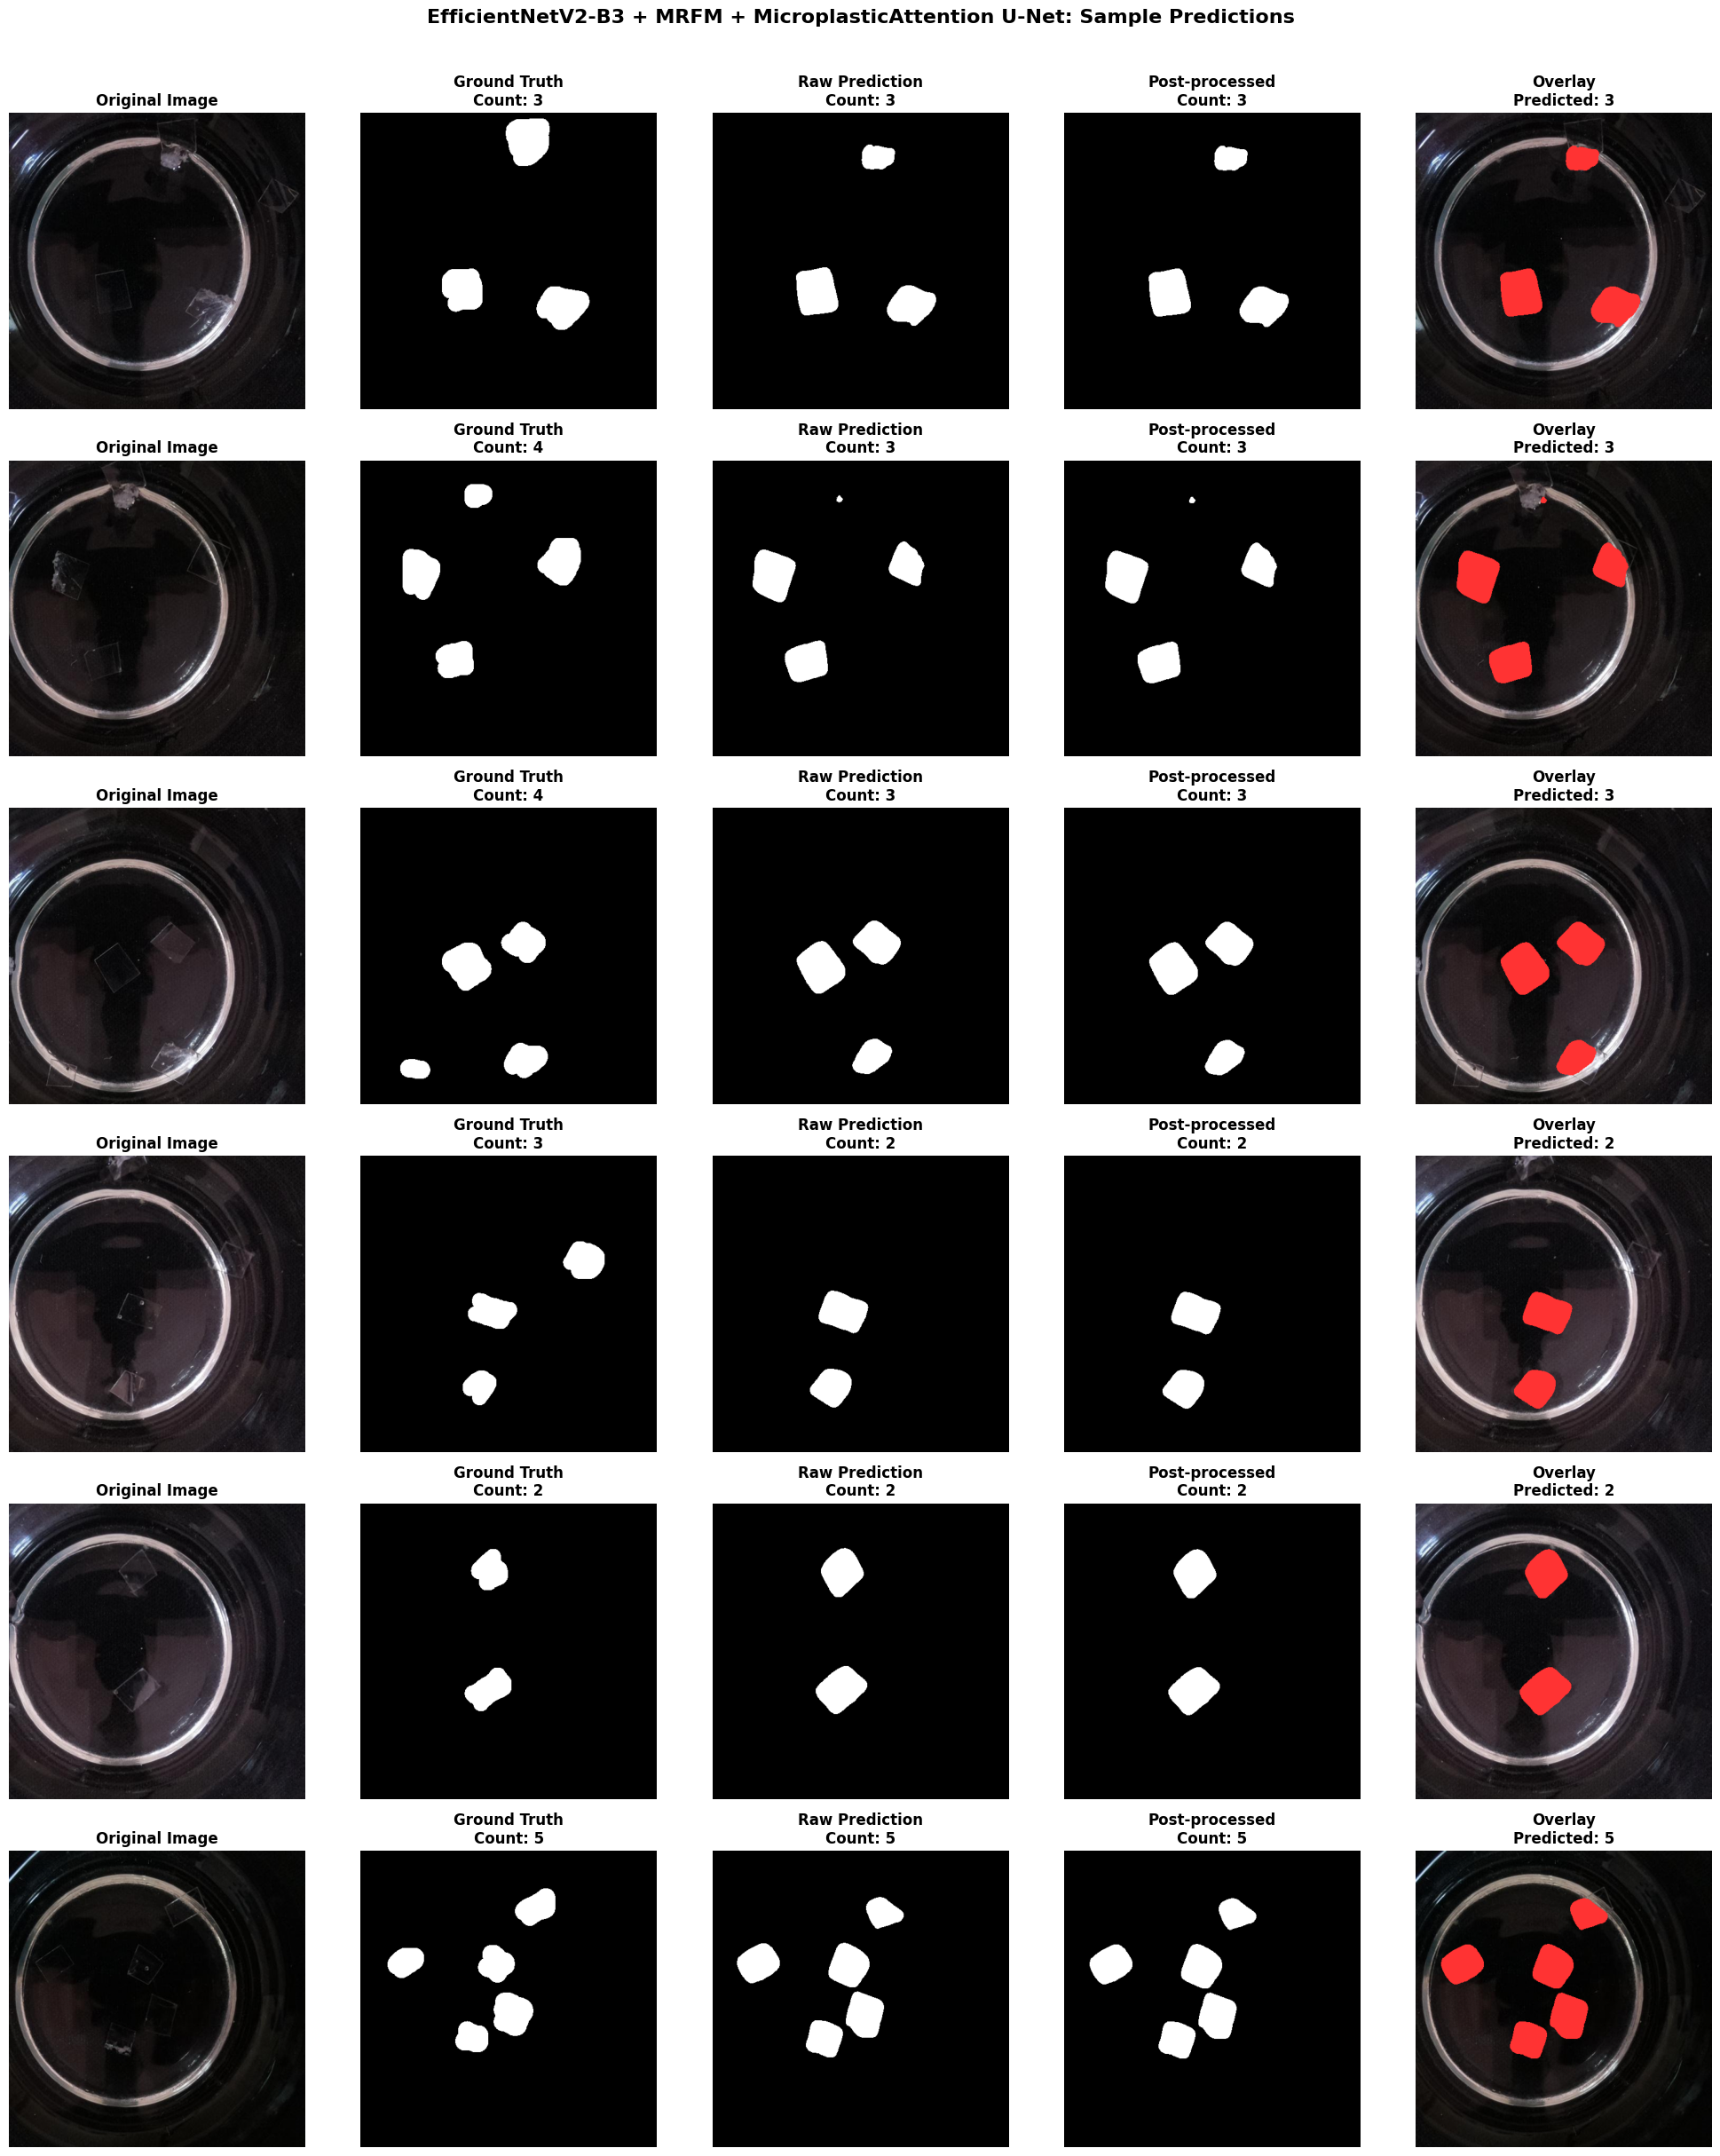

✅ Sample predictions visualization saved

CREATING COMPREHENSIVE VISUALIZATIONS


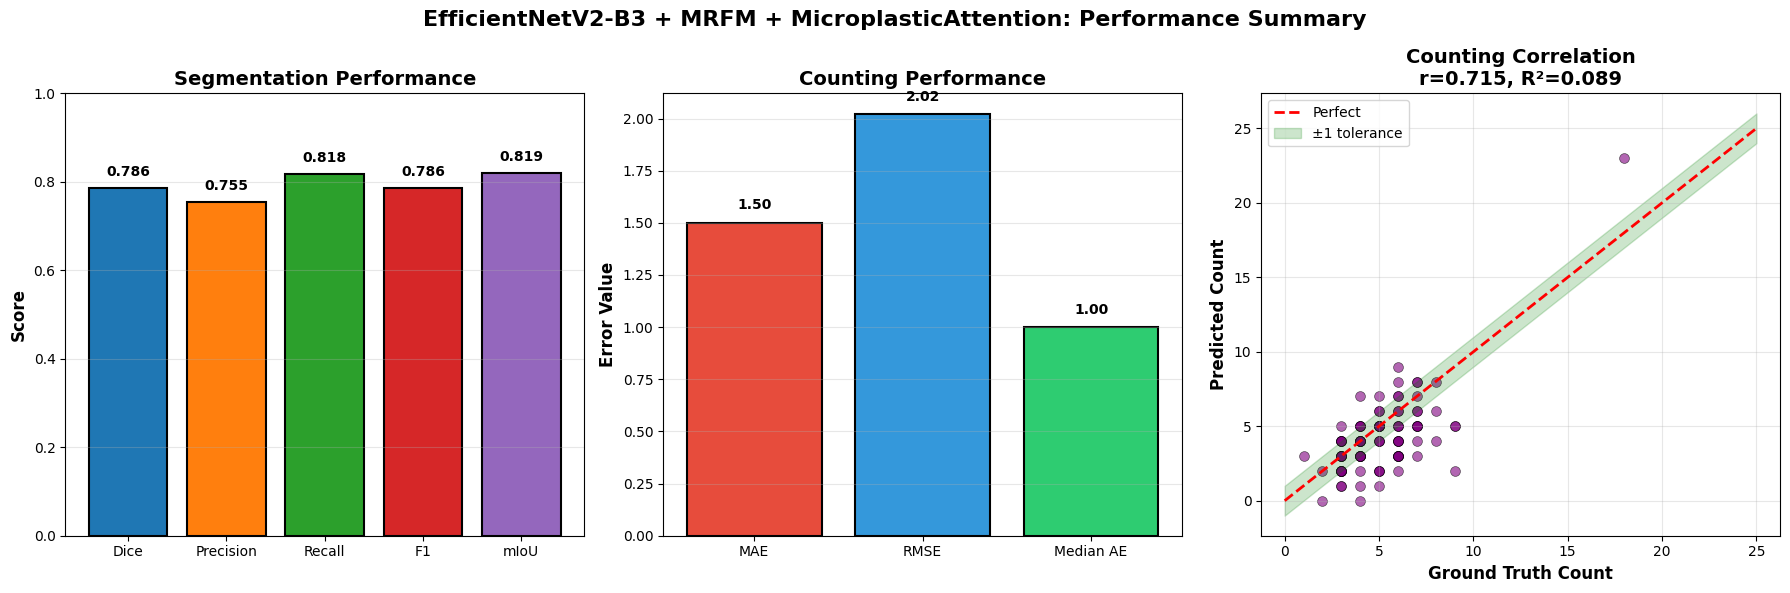

✅ Performance summary visualization saved

SAVING COMPREHENSIVE RESULTS
✅ Results saved to: results_efficientnetv2b3_mrfm_attention_512/
   - comprehensive_results.csv
   - performance_summary.txt
   - performance_summary.png
   - sample_predictions.png

TRAINING AND EVALUATION COMPLETE!

📊 KEY RESULTS:
  Segmentation:
    • Dice = 0.7855
    • Precision = 0.7551
    • Recall = 0.8185
    • mIoU = 0.8193
  Counting:
    • MAE = 1.500
    • RMSE = 2.020
    • Tolerance Acc = 61.0%
    • Pearson r = 0.715
    • R² = 0.089
  Improvement:
    • MAE reduction: -4.9%
    • Tol. Acc gain: +0.0%


In [3]:
# ============================================================================
# CUSTOM LOSS FUNCTIONS
# ============================================================================

# ============================================================================
# CUSTOM LOSS FUNCTIONS - OPTIMIZED FOR SEVERE IMBALANCE
# ============================================================================

def calculate_class_weights(masks):
    """Calculate class weights for imbalanced segmentation."""
    masks_flat = (masks > 0.5).astype(np.uint8).flatten()
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.array([0, 1]),
        y=masks_flat
    )
    return {0: class_weights[0], 1: class_weights[1]}

if len(y_train) > 0:
    class_weights = calculate_class_weights(y_train)
    cw0 = tf.constant(class_weights[0], dtype=tf.float32)
    cw1 = tf.constant(class_weights[1], dtype=tf.float32)
    print(f"Class weights - Background: {cw0:.4f}, Foreground: {cw1:.4f}")
else:
    cw0 = tf.constant(1.0, dtype=tf.float32)
    cw1 = tf.constant(1.0, dtype=tf.float32)


def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """FIXED: Properly handle both (B,H,W) and (B,H,W,1) shapes."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Squeeze if channel dimension exists
    if len(y_true.shape) == 4:
        y_true = tf.squeeze(y_true, axis=-1)
    if len(y_pred.shape) == 4:
        y_pred = tf.squeeze(y_pred, axis=-1)

    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
    union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat)

    return (2.0 * intersection + smooth) / (union + smooth)


def dice_loss(y_true, y_pred, smooth=1e-6):
    """Dice loss for binary segmentation."""
    return 1.0 - dice_coefficient(y_true, y_pred, smooth)


def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    """FIXED: Properly handle shapes."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Squeeze if channel dimension exists
    if len(y_true.shape) == 4:
        y_true = tf.squeeze(y_true, axis=-1)
    if len(y_pred.shape) == 4:
        y_pred = tf.squeeze(y_pred, axis=-1)

    y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1 - K.epsilon())

    pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
    alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)

    loss = -alpha_t * tf.pow(1 - pt, gamma) * tf.math.log(pt)
    return tf.reduce_mean(loss)


def tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, smooth=1e-6):
    """FIXED: Properly handle shapes."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Squeeze if channel dimension exists
    if len(y_true.shape) == 4:
        y_true = tf.squeeze(y_true, axis=-1)
    if len(y_pred.shape) == 4:
        y_pred = tf.squeeze(y_pred, axis=-1)

    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    true_pos = tf.reduce_sum(y_true_flat * y_pred_flat)
    false_neg = tf.reduce_sum(y_true_flat * (1 - y_pred_flat))
    false_pos = tf.reduce_sum((1 - y_true_flat) * y_pred_flat)

    tversky = (true_pos + smooth) / (true_pos + alpha * false_neg + beta * false_pos + smooth)

    return 1.0 - tversky


def aggressive_imbalance_loss(y_true, y_pred):
    """FIXED: Properly handle shapes."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Squeeze if channel dimension exists
    if len(y_true.shape) == 4:
        y_true = tf.squeeze(y_true, axis=-1)
    if len(y_pred.shape) == 4:
        y_pred = tf.squeeze(y_pred, axis=-1)

    y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1 - K.epsilon())

    # Dice loss (emphasizes overlap)
    dice = dice_loss(y_true, y_pred)

    # Tversky loss (emphasizes recall)
    tversky = tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3)

    # Focal loss (handles imbalance)
    focal = focal_loss(y_true, y_pred, alpha=0.75, gamma=2.0)

    # Heavily weight shape losses over pixel-wise losses
    total_loss = 5.0 * dice + 3.0 * tversky + 1.0 * focal

    return total_loss


def focal_dice_loss(y_true, y_pred, gamma=2.0, dice_weight=3.0, focal_weight=1.0):
    """FIXED: Properly handle shapes."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Squeeze if channel dimension exists
    if len(y_true.shape) == 4:
        y_true = tf.squeeze(y_true, axis=-1)
    if len(y_pred.shape) == 4:
        y_pred = tf.squeeze(y_pred, axis=-1)

    focal = focal_loss(y_true, y_pred, alpha=0.75, gamma=gamma)
    dice = dice_loss(y_true, y_pred)

    return focal_weight * focal + dice_weight * dice


def iou_metric(y_true, y_pred, smooth=1e-6):
    """FIXED: Properly handle shapes."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Squeeze if channel dimension exists
    if len(y_true.shape) == 4:
        y_true = tf.squeeze(y_true, axis=-1)
    if len(y_pred.shape) == 4:
        y_pred = tf.squeeze(y_pred, axis=-1)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection

    iou = (intersection + smooth) / (union + smooth)

    return iou


# ============================================================================
# PREDICTION MONITORING CALLBACK
# ============================================================================

class PredictionMonitor(tf.keras.callbacks.Callback):
    """FIXED: Properly preprocess validation data before prediction."""
    def __init__(self, val_data, val_masks):
        super().__init__()
        # Store raw validation data
        self.val_data_raw = val_data[:4]
        self.val_masks = val_masks[:4]

        # Preprocess for EfficientNet
        self.val_data = preprocess_input(self.val_data_raw * 255.0)

    def on_epoch_end(self, epoch, logs=None):
        if epoch % 3 == 0:
            preds = self.model.predict(self.val_data, verbose=0)

            # Handle shape properly
            if len(preds.shape) == 4 and preds.shape[-1] == 1:
                preds = preds.squeeze(-1)

            fg_pixels = (preds > 0.5).sum()
            total_pixels = preds.size
            max_pred = preds.max()
            mean_pred = preds.mean()

            print(f"\n  📊 [Epoch {epoch}] Predictions: max={max_pred:.4f}, mean={mean_pred:.4f}, "
                  f"fg_pixels={fg_pixels:,}/{total_pixels:,} ({fg_pixels/total_pixels*100:.3f}%)")


# =============================================================================
# FIXED EVALUATION CODE
# =============================================================================

def preprocess_test_data(X_test):
    """Preprocess test data the same way as training data."""
    # X_test is in [0, 1] range from loading
    # Convert to [0, 255] then apply EfficientNet preprocessing
    X_test_preprocessed = preprocess_input(X_test * 255.0)
    return X_test_preprocessed


# =============================================================================
# COMPLETE FIXED TRAINING SCRIPT
# =============================================================================

print("\n" + "="*80)
print("BUILDING MODEL WITH FIXES")
print("="*80)

model, backbone = build_efficientnetv2b3_mrfm_attention_unet(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

print(f"✅ Model compiled successfully")
print(f"   Total parameters: {model.count_params():,}")
print(f"   Output shape: {model.output.shape}")  # Should be (None, 512, 512, 1)

# =============================================================================
# TWO-PHASE TRAINING WITH FIXES
# =============================================================================

print("\n" + "="*80)
print("PHASE 1: Training decoder (backbone frozen)")
print("="*80)

backbone.trainable = False

# Compile with aggressive loss and higher learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=aggressive_imbalance_loss,
    metrics=[dice_coefficient, iou_metric]
)

callbacks_phase1 = [
    PredictionMonitor(X_val, y_val),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coefficient',
        patience=15,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_dice_coefficient',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/efficientnetv2b3_mrfm_attention_phase1.weights.h5',
        monitor='val_dice_coefficient',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        '/content/training_log_phase1.csv',
        append=False
    )
]

print(f"\nTraining Phase 1 with {len(X_train)} samples, batch size {BATCH_SIZE}")
history_phase1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=40,
    callbacks=callbacks_phase1,
    verbose=1
)

# CRITICAL: Check Phase 1 results with PREPROCESSED data
print("\n📊 PHASE 1 RESULTS:")
print(f"   Best Dice: {max(history_phase1.history['val_dice_coefficient']):.4f}")
print(f"   Final Dice: {history_phase1.history['val_dice_coefficient'][-1]:.4f}")

# FIXED: Preprocess training data before prediction check
X_train_preprocessed = preprocess_input(X_train[:4] * 255.0)
train_pred_check = model.predict(X_train_preprocessed, verbose=0)
if len(train_pred_check.shape) == 4 and train_pred_check.shape[-1] == 1:
    train_pred_check = train_pred_check.squeeze(-1)
print(f"   Train pred range: [{train_pred_check.min():.4f}, {train_pred_check.max():.4f}]")
print(f"   Train pred mean: {train_pred_check.mean():.4f}")
print(f"   Train fg pixels: {(train_pred_check > 0.5).sum():,} / {train_pred_check.size:,}")

# PHASE 2: Fine-tune entire model
print("\n" + "="*80)
print("PHASE 2: Fine-tuning entire model")
print("="*80)

backbone.trainable = True
for layer in backbone.layers[:-80]:
    layer.trainable = False

# Freeze BatchNorm
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print(f"Trainable layers in backbone: {sum([1 for l in backbone.layers if l.trainable])}")

# Recompile with lower LR
optimizer_ft = tf.keras.optimizers.AdamW(
    learning_rate=5e-5,
    weight_decay=1e-5,
    beta_1=0.9,
    beta_2=0.999
)

model.compile(
    optimizer=optimizer_ft,
    loss=focal_dice_loss,
    metrics=[
        dice_coefficient,
        iou_metric,
        'binary_accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks_phase2 = [
    PredictionMonitor(X_val, y_val),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coefficient',
        patience=PATIENCE,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_dice_coefficient',
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/efficientnetv2b3_mrfm_attention_final.weights.h5',
        monitor='val_dice_coefficient',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        '/content/training_log_phase2.csv',
        append=False
    )
]

print(f"\nTraining Phase 2 with {len(X_train)} samples, batch size {BATCH_SIZE}")
history_phase2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks_phase2,
    verbose=1,
    initial_epoch=len(history_phase1.history['loss'])
)

print("\n✅ Two-phase training complete!")
print(f"   Best Dice (Phase 2): {max(history_phase2.history['val_dice_coefficient']):.4f}")


# =============================================================================
# FIXED EVALUATION
# =============================================================================

print("\n" + "="*80)
print("EVALUATING BEST MODEL")
print("="*80)

# Reconstruct model
print("Reconstructing model architecture...")
model, backbone = build_efficientnetv2b3_mrfm_attention_unet(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

backbone.trainable = True
for layer in backbone.layers[:-80]:
    layer.trainable = False

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

optimizer_ft = tf.keras.optimizers.AdamW(
    learning_rate=5e-5,
    weight_decay=1e-5,
    beta_1=0.9,
    beta_2=0.999
)

model.compile(
    optimizer=optimizer_ft,
    loss=focal_dice_loss,
    metrics=[
        dice_coefficient,
        iou_metric,
        'binary_accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Load best weights
print("Loading best weights...")
model.load_weights('/content/efficientnetv2b3_mrfm_attention_final.weights.h5')
print("✅ Model weights loaded successfully")

# CRITICAL FIX: Preprocess test data before prediction
print("Preprocessing test data...")
X_test_preprocessed = preprocess_test_data(X_test)
print(f"Test data preprocessed: shape={X_test_preprocessed.shape}, "
      f"range=[{X_test_preprocessed.min():.2f}, {X_test_preprocessed.max():.2f}]")

# Generate predictions on preprocessed data
print("Generating predictions on test set...")
test_pred_raw = model.predict(X_test_preprocessed, batch_size=BATCH_SIZE, verbose=1)
print(f"Predictions shape: {test_pred_raw.shape}")
print(f"Predictions range: [{test_pred_raw.min():.4f}, {test_pred_raw.max():.4f}]")

# Ground truth counts from masks
gt_counts = test_counts.flatten()
# ============================================================================
# FIXED EVALUATION CODE - Replace the evaluation section in your script
# ============================================================================

# ============================================================================
# SEGMENTATION EVALUATION
# ============================================================================

print("\n" + "="*80)
print("SEGMENTATION PERFORMANCE EVALUATION")
print("="*80)

# Ensure predictions are in correct shape
if len(test_pred_raw.shape) == 4 and test_pred_raw.shape[-1] == 1:
    test_pred_raw = test_pred_raw.squeeze(-1)

# Raw binary segmentation with threshold
seg_threshold = 0.3
y_pred_binary = (test_pred_raw > seg_threshold).astype(np.uint8)

# Ensure y_test is in correct shape
y_test_eval = y_test.copy()
if len(y_test_eval.shape) == 4 and y_test_eval.shape[-1] == 1:
    y_test_eval = y_test_eval.squeeze(-1)

# Calculate global segmentation metrics
seg_metrics = calculate_segmentation_metrics(
    y_test_eval.astype(np.uint8),
    y_pred_binary
)

print(f"{'Metric':<20} {'Value':<10}")
print("-" * 35)
print(f"{'Dice Coefficient':<20} {seg_metrics['dice']:.4f}")
print(f"{'Precision':<20} {seg_metrics['precision']:.4f}")
print(f"{'Recall':<20} {seg_metrics['recall']:.4f}")
print(f"{'F1-score':<20} {seg_metrics['f1']:.4f}")
print(f"{'mIoU':<20} {seg_metrics['miou']:.4f}")
print(f"{'IoU (Foreground)':<20} {seg_metrics['iou_foreground']:.4f}")
print(f"{'IoU (Background)':<20} {seg_metrics['iou_background']:.4f}")


# ============================================================================
# COUNTING EVALUATION
# ============================================================================

print("\n" + "="*80)
print("COUNTING PERFORMANCE EVALUATION")
print("="*80)

# Apply stable post-processing - FIX: Use 'threshold' not 'bin_threshold'
test_pred_processed = stable_postprocessing(test_pred_raw, threshold=0.3)

# 1. Post-processed segmentation-based counting
print("\n=== POST-PROCESSED SEGMENTATION-BASED COUNTING ===")
proc_counts = []
for i in range(len(test_pred_processed)):
    pred_slice = test_pred_processed[i]
    if len(pred_slice.shape) == 3:
        pred_slice = pred_slice.squeeze()
    count = count_particles_cc(pred_slice, use_watershed=True)
    proc_counts.append(count)

proc_counts = np.array(proc_counts)

# FIX: Add missing median_ae, nmae, mape, r2 to calculate_counting_metrics
def calculate_counting_metrics_enhanced(gt_counts, pred_counts, tol=1.0):
    """
    Calculate comprehensive counting metrics with all necessary statistics.

    Parameters:
    -----------
    gt_counts : array-like
        Ground truth particle counts
    pred_counts : array-like
        Predicted particle counts
    tol : float
        Tolerance for accuracy calculation (default=1.0)

    Returns:
    --------
    dict : Dictionary containing all counting metrics
    """
    gt_counts = np.asarray(gt_counts).flatten()
    pred_counts = np.asarray(pred_counts).flatten()

    # Basic regression metrics
    mae = mean_absolute_error(gt_counts, pred_counts)
    rmse = np.sqrt(mean_squared_error(gt_counts, pred_counts))
    bias = np.mean(pred_counts - gt_counts)

    # Median absolute error
    median_ae = np.median(np.abs(pred_counts - gt_counts))

    # Normalized MAE
    mean_gt = np.mean(gt_counts)
    nmae = mae / mean_gt if mean_gt > 0 else 0.0

    # Mean Absolute Percentage Error
    mape = np.mean(np.abs((gt_counts - pred_counts) / (gt_counts + 1e-8))) * 100

    # Pearson correlation
    if len(gt_counts) > 1 and np.std(gt_counts) > 0 and np.std(pred_counts) > 0:
        pearson_r = np.corrcoef(gt_counts, pred_counts)[0, 1]
    else:
        pearson_r = 0.0

    # R-squared
    ss_res = np.sum((gt_counts - pred_counts) ** 2)
    ss_tot = np.sum((gt_counts - np.mean(gt_counts)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0

    # Tolerance accuracy
    tol_acc = np.mean(np.abs(pred_counts - gt_counts) <= tol) * 100

    return {
        'mae': mae,
        'rmse': rmse,
        'bias': bias,
        'median_ae': median_ae,
        'nmae': nmae,
        'mape_%': mape,
        'pearson_r': pearson_r,
        'r2': r2,
        'tol_acc_%': tol_acc,
        'total_images': len(gt_counts)
    }


def stable_postprocessing(predictions, threshold=0.3):
    """
    FIXED: Apply stable post-processing pipeline.
    Now properly handles the threshold parameter.
    """
    processed = []

    for pred in predictions:
        # Handle shape properly
        if len(pred.shape) == 3 and pred.shape[-1] == 1:
            pred_prob = pred.squeeze(-1)
        else:
            pred_prob = pred.squeeze()

        # Step 1: Fixed threshold
        binary_pred = (pred_prob > threshold).astype(np.uint8)

        if binary_pred.sum() == 0:
            processed.append(np.zeros_like(binary_pred, dtype=np.float32))
            continue

        # Step 2: Remove border objects
        binary_no_border = remove_border_objects(binary_pred, border_width=5)

        if binary_no_border.sum() == 0:
            processed.append(np.zeros_like(binary_no_border, dtype=np.float32))
            continue

        # Step 3: Morphological cleaning
        kernel = np.ones((2, 2), np.uint8)
        cleaned = cv2.morphologyEx(binary_no_border, cv2.MORPH_OPEN, kernel)
        cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

        if cleaned.sum() == 0:
            processed.append(np.zeros_like(cleaned, dtype=np.float32))
            continue

        # Step 4: Size filtering
        size_filtered = adaptive_min_area_filtering(cleaned, percentile=3)

        if size_filtered.sum() == 0:
            processed.append(np.zeros_like(size_filtered, dtype=np.float32))
            continue

        # Step 5: Confidence filtering
        final_mask = confidence_noise_suppression(size_filtered, pred_prob, threshold=threshold)

        processed.append(final_mask.astype(np.float32))

    # Return with proper shape (N, H, W, 1)
    return np.array(processed)[..., np.newaxis].astype(np.float32)

proc_metrics = calculate_counting_metrics_enhanced(gt_counts, proc_counts, tol=1.0)
print(f"Counting on post-processed predictions:")
print(f"  MAE = {proc_metrics['mae']:.3f}")
print(f"  RMSE = {proc_metrics['rmse']:.3f}")
print(f"  Median AE = {proc_metrics['median_ae']:.3f}")
print(f"  Bias = {proc_metrics['bias']:.3f}")
print(f"  NMAE = {proc_metrics['nmae']:.3f}")
print(f"  MAPE = {proc_metrics['mape_%']:.2f}%")
print(f"  Tolerance Accuracy (±1) = {proc_metrics['tol_acc_%']:.1f}%")
print(f"  Pearson r = {proc_metrics['pearson_r']:.3f}")
print(f"  R² = {proc_metrics['r2']:.3f}")

# 2. Raw segmentation-based counting (for comparison)
print("\n=== RAW SEGMENTATION-BASED COUNTING (for reference) ===")
raw_counts = []
for i in range(len(test_pred_raw)):
    pred_slice = test_pred_raw[i]
    if len(pred_slice.shape) == 3:
        pred_slice = pred_slice.squeeze()
    binary_pred = (pred_slice > 0.3).astype(np.uint8)
    count = count_particles_cc(binary_pred, use_watershed=True)
    raw_counts.append(count)

raw_counts = np.array(raw_counts)

raw_metrics = calculate_counting_metrics_enhanced(gt_counts, raw_counts, tol=1.0)
print(f"Counting on raw predictions (threshold=0.3):")
print(f"  MAE = {raw_metrics['mae']:.3f}")
print(f"  Tolerance Accuracy (±1) = {raw_metrics['tol_acc_%']:.1f}%")

# Improvement analysis
print("\n=== IMPROVEMENT ANALYSIS ===")
if raw_metrics['mae'] > 0:
    mae_improvement = ((raw_metrics['mae'] - proc_metrics['mae']) / raw_metrics['mae']) * 100
else:
    mae_improvement = 0.0
tol_acc_improvement = proc_metrics['tol_acc_%'] - raw_metrics['tol_acc_%']

print(f"Post-processing vs raw segmentation:")
print(f"  MAE reduction: {mae_improvement:+.1f}%")
print(f"  Tolerance accuracy improvement: {tol_acc_improvement:+.1f}%")


# ============================================================================
# CREATE RESULTS DIRECTORY
# ============================================================================

os.makedirs('results_efficientnetv2b3_mrfm_attention_512', exist_ok=True)


# ============================================================================
# VISUALIZE SAMPLE PREDICTIONS
# ============================================================================

print("\n" + "="*80)
print("VISUALIZING SAMPLE PREDICTIONS")
print("="*80)

# Sample visualizations
num_samples = min(6, len(X_test))
sample_indices = list(range(num_samples))

if len(sample_indices) > 0:
    fig, axes = plt.subplots(len(sample_indices), 5, figsize=(20, 4*len(sample_indices)))
    if len(sample_indices) == 1:
        axes = axes.reshape(1, -1)

    for idx, sample_idx in enumerate(sample_indices):
        # Original RGB image
        img_display = X_test[sample_idx].copy()
        if len(img_display.shape) == 3 and img_display.shape[-1] == 3:
            img_min = img_display.min()
            img_max = img_display.max()
            if img_max > img_min:
                img_display = (img_display - img_min) / (img_max - img_min)
            img_display = np.clip(img_display, 0, 1)

        axes[idx, 0].imshow(img_display)
        axes[idx, 0].set_title('Original Image', fontweight='bold')
        axes[idx, 0].axis('off')

        # Ground truth mask
        gt_mask = y_test[sample_idx].copy()
        if len(gt_mask.shape) == 3:
            gt_mask = gt_mask.squeeze()
        axes[idx, 1].imshow(gt_mask, cmap='gray')
        gt_count = int(gt_counts[sample_idx]) if sample_idx < len(gt_counts) else 0
        axes[idx, 1].set_title(f'Ground Truth\nCount: {gt_count}', fontweight='bold')
        axes[idx, 1].axis('off')

        # Raw prediction
        raw_pred = test_pred_raw[sample_idx].copy()
        if len(raw_pred.shape) == 3:
            raw_pred = raw_pred.squeeze()
        raw_pred_binary = (raw_pred > 0.3).astype(np.uint8)
        axes[idx, 2].imshow(raw_pred_binary, cmap='gray')
        raw_count = raw_counts[sample_idx] if sample_idx < len(raw_counts) else 0
        axes[idx, 2].set_title(f'Raw Prediction\nCount: {raw_count}', fontweight='bold')
        axes[idx, 2].axis('off')

        # Processed prediction
        proc_pred = test_pred_processed[sample_idx].copy()
        if len(proc_pred.shape) == 3:
            proc_pred = proc_pred.squeeze()
        axes[idx, 3].imshow(proc_pred, cmap='gray')
        proc_count = proc_counts[sample_idx] if sample_idx < len(proc_counts) else 0
        axes[idx, 3].set_title(f'Post-processed\nCount: {proc_count}', fontweight='bold')
        axes[idx, 3].axis('off')

        # Overlay
        overlay = img_display.copy()
        if len(overlay.shape) == 2:
            overlay = np.stack([overlay]*3, axis=-1)
        mask_overlay = proc_pred > 0.5
        overlay[mask_overlay, 0] = 1.0
        overlay[mask_overlay, 1] = 0.2
        overlay[mask_overlay, 2] = 0.2
        axes[idx, 4].imshow(overlay)
        axes[idx, 4].set_title(f'Overlay\nPredicted: {proc_count}', fontweight='bold')
        axes[idx, 4].axis('off')

    plt.suptitle('EfficientNetV2-B3 + MRFM + MicroplasticAttention U-Net: Sample Predictions',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('results_efficientnetv2b3_mrfm_attention_512/sample_predictions.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Sample predictions visualization saved")


# ============================================================================
# COMPREHENSIVE VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("CREATING COMPREHENSIVE VISUALIZATIONS")
print("="*80)

# Performance comparison chart
fig = plt.figure(figsize=(18, 6))

# Subplot 1: Segmentation metrics
ax1 = plt.subplot(1, 3, 1)
metrics_names = ['Dice', 'Precision', 'Recall', 'F1', 'mIoU']
metrics_values = [seg_metrics['dice'], seg_metrics['precision'],
                  seg_metrics['recall'], seg_metrics['f1'], seg_metrics['miou']]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = ax1.bar(metrics_names, metrics_values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Segmentation Performance', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.02,
             f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 2: Counting metrics
ax2 = plt.subplot(1, 3, 2)
count_names = ['MAE', 'RMSE', 'Median AE']
count_values = [proc_metrics['mae'], proc_metrics['rmse'], proc_metrics['median_ae']]
bars2 = ax2.bar(count_names, count_values, color=['#e74c3c', '#3498db', '#2ecc71'],
                edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Error Value', fontsize=12, fontweight='bold')
ax2.set_title('Counting Performance', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars2, count_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 0.05,
             f'{value:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 3: Correlation plot
ax3 = plt.subplot(1, 3, 3)
if len(gt_counts) > 0 and len(proc_counts) > 0:
    max_val = max(max(gt_counts), max(proc_counts)) + 2

    ax3.scatter(gt_counts, proc_counts, alpha=0.6, s=50, color='purple',
                edgecolors='black', linewidth=0.5)
    ax3.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect')
    ax3.fill_between([0, max_val], [-1, max_val-1], [1, max_val+1],
                     alpha=0.2, color='green', label='±1 tolerance')

    ax3.set_xlabel('Ground Truth Count', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Predicted Count', fontsize=12, fontweight='bold')
    ax3.set_title(f'Counting Correlation\nr={proc_metrics["pearson_r"]:.3f}, R²={proc_metrics["r2"]:.3f}',
                  fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc='upper left', fontsize=10)

plt.suptitle('EfficientNetV2-B3 + MRFM + MicroplasticAttention: Performance Summary',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results_efficientnetv2b3_mrfm_attention_512/performance_summary.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Performance summary visualization saved")


# ============================================================================
# SAVE COMPREHENSIVE RESULTS
# ============================================================================

print("\n" + "="*80)
print("SAVING COMPREHENSIVE RESULTS")
print("="*80)

# Create comprehensive results dataframe
results_df = pd.DataFrame({
    'Image_Index': range(len(gt_counts)),
    'GT_Count': gt_counts,
    'Raw_Count': raw_counts,
    'Processed_Count': proc_counts,
    'Raw_AE': np.abs(raw_counts - gt_counts),
    'Processed_AE': np.abs(proc_counts - gt_counts),
    'Within_Tol_Raw': np.abs(raw_counts - gt_counts) <= 1,
    'Within_Tol_Processed': np.abs(proc_counts - gt_counts) <= 1
})

results_df.to_csv('results_efficientnetv2b3_mrfm_attention_512/comprehensive_results.csv', index=False)

# Save performance summary
with open('results_efficientnetv2b3_mrfm_attention_512/performance_summary.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("EFFICIENTNETV2-B3 + MRFM + MICROPLASTIC ATTENTION U-NET\n")
    f.write("PERFORMANCE SUMMARY\n")
    f.write("="*80 + "\n\n")

    f.write("ARCHITECTURE\n")
    f.write("-" * 40 + "\n")
    f.write("  - Backbone: EfficientNetV2-B3 (ImageNet pretrained)\n")
    f.write("  - Fusion: Multi-Resolution Fusion Module (MRFM)\n")
    f.write("  - Attention: Stage-adaptive MicroplasticAttention\n")
    f.write("    • Early stages: Edge Attention\n")
    f.write("    • Middle stage: Coordinate Attention\n")
    f.write("    • Deep stages: Channel + Spatial Attention\n")
    f.write("  - Input: 512×512×3 (RGB + CLAHE)\n")
    f.write("  - Training: Two-phase (frozen → fine-tuned)\n\n")

    f.write("SEGMENTATION PERFORMANCE\n")
    f.write("-" * 40 + "\n")
    f.write(f"  Dice Coefficient = {seg_metrics['dice']:.4f}\n")
    f.write(f"  Precision = {seg_metrics['precision']:.4f}\n")
    f.write(f"  Recall = {seg_metrics['recall']:.4f}\n")
    f.write(f"  F1-score = {seg_metrics['f1']:.4f}\n")
    f.write(f"  mIoU = {seg_metrics['miou']:.4f}\n")
    f.write(f"  IoU (Foreground) = {seg_metrics['iou_foreground']:.4f}\n")
    f.write(f"  IoU (Background) = {seg_metrics['iou_background']:.4f}\n\n")

    f.write("COUNTING PERFORMANCE\n")
    f.write("-" * 40 + "\n")
    f.write(f"  MAE = {proc_metrics['mae']:.3f}\n")
    f.write(f"  RMSE = {proc_metrics['rmse']:.3f}\n")
    f.write(f"  Median AE = {proc_metrics['median_ae']:.3f}\n")
    f.write(f"  Bias = {proc_metrics['bias']:.3f}\n")
    f.write(f"  NMAE = {proc_metrics['nmae']:.3f}\n")
    f.write(f"  MAPE = {proc_metrics['mape_%']:.2f}%\n")
    f.write(f"  Pearson r = {proc_metrics['pearson_r']:.3f}\n")
    f.write(f"  R² = {proc_metrics['r2']:.3f}\n")
    f.write(f"  Tolerance Acc (±1) = {proc_metrics['tol_acc_%']:.1f}%\n\n")

    f.write("IMPROVEMENT OVER RAW\n")
    f.write("-" * 40 + "\n")
    f.write(f"  MAE reduction: {mae_improvement:+.1f}%\n")
    f.write(f"  Tol. Acc improvement: {tol_acc_improvement:+.1f}%\n\n")

    f.write("SAMPLE STATISTICS\n")
    f.write("-" * 40 + "\n")
    f.write(f"  Total test images: {len(gt_counts)}\n")
    f.write(f"  Mean GT count: {np.mean(gt_counts):.2f}\n")
    f.write(f"  Mean predicted count: {np.mean(proc_counts):.2f}\n")
    f.write(f"  GT count range: [{np.min(gt_counts)}, {np.max(gt_counts)}]\n")
    f.write(f"  Predicted count range: [{np.min(proc_counts)}, {np.max(proc_counts)}]\n")

print("✅ Results saved to: results_efficientnetv2b3_mrfm_attention_512/")
print("   - comprehensive_results.csv")
print("   - performance_summary.txt")
print("   - performance_summary.png")
print("   - sample_predictions.png")


# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("TRAINING AND EVALUATION COMPLETE!")
print("="*80)
print(f"\n📊 KEY RESULTS:")
print(f"  Segmentation:")
print(f"    • Dice = {seg_metrics['dice']:.4f}")
print(f"    • Precision = {seg_metrics['precision']:.4f}")
print(f"    • Recall = {seg_metrics['recall']:.4f}")
print(f"    • mIoU = {seg_metrics['miou']:.4f}")
print(f"  Counting:")
print(f"    • MAE = {proc_metrics['mae']:.3f}")
print(f"    • RMSE = {proc_metrics['rmse']:.3f}")
print(f"    • Tolerance Acc = {proc_metrics['tol_acc_%']:.1f}%")
print(f"    • Pearson r = {proc_metrics['pearson_r']:.3f}")
print(f"    • R² = {proc_metrics['r2']:.3f}")
print(f"  Improvement:")
print(f"    • MAE reduction: {mae_improvement:+.1f}%")
print(f"    • Tol. Acc gain: {tol_acc_improvement:+.1f}%")
print("="*80)

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras import mixed_precision
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns
import pandas as pd
from skimage.transform import rotate, resize
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# GPU SETUP
# ============================================================================

# Confirm GPU
gpus = tf.config.list_physical_devices('GPU')
assert len(gpus) > 0, "❌ No GPU detected!"
print("✅ GPU detected:", gpus)

# Enable memory growth
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# Enable mixed precision
mixed_precision.set_global_policy('mixed_float16')
print("✅ Mixed precision enabled")

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Configuration
IMG_HEIGHT = 512
IMG_WIDTH = 512
BATCH_SIZE = 4
EPOCHS = 50
PATIENCE = 15

# Paths to your data
TRAIN_IMAGE_DIR = '/content/training/training/Training_original'
TRAIN_MASK_DIR = '/content/training/training/Finalmasks'
VAL_IMAGE_DIR = '/content/val/val/Original'
VAL_MASK_DIR = '/content/val/val/val_100masks'
TEST_IMAGE_DIR = '/content/Testing/Testing/Original'
TEST_MASK_DIR = '/content/Testing/Testing/testing_100masks'


# ============================================================================
# 1. FILENAME NORMALIZATION
# ============================================================================

def normalize_name(name):
    """Normalize filename for matching."""
    name = os.path.basename(name)
    name = os.path.splitext(name)[0]
    name = name.replace('_mask', '')
    return name

# ============================================================================
# 2. PREPROCESSING FUNCTIONS
# ============================================================================

def preprocess_mask(mask):
    """Proper mask binarization for binary segmentation."""
    # Handle multi-channel masks
    if len(mask.shape) == 3:
        mask = mask[:, :, 0]

    mask_binary = (mask > 127).astype(np.float32)
    return mask_binary

# ============================================================================
# 3. SEGMENTATION METRICS FUNCTIONS
# ============================================================================

def calculate_iou(y_true, y_pred, return_class_iou=False):
    """Calculate Intersection over Union for binary masks."""
    # Ensure binary masks (0 or 1)
    y_true = (y_true.flatten() > 0.5).astype(np.uint8)
    y_pred = (y_pred.flatten() > 0.5).astype(np.uint8)

    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection

    # If both masks are empty, they match perfectly
    if union == 0:
        iou = 1.0
    else:
        iou = intersection / union

    # Optionally return foreground-specific IoU
    if return_class_iou:
        # IoU for particles only (class 1)
        fg_intersection = intersection
        fg_union = union
        fg_iou = fg_intersection / fg_union if fg_union > 0 else 0.0

        return {
            'iou': iou,
            'foreground_iou': fg_iou,
            'has_particles': np.sum(y_true) > 0
        }

    return iou

def calculate_miou(y_true, y_pred):
    """Calculate mean Intersection over Union for both classes."""
    # Ensure binary masks (0 or 1)
    y_true = (y_true.flatten() > 0.5).astype(np.uint8)
    y_pred = (y_pred.flatten() > 0.5).astype(np.uint8)

    # Calculate IoU for both classes
    iou_background = calculate_iou(1 - y_true, 1 - y_pred)
    iou_foreground = calculate_iou(y_true, y_pred)

    miou = (iou_background + iou_foreground) / 2.0

    # Calculate class frequencies for context
    bg_ratio = np.mean(1 - y_true)
    fg_ratio = np.mean(y_true)

    return {
        'iou_background': iou_background,
        'iou_foreground': iou_foreground,
        'miou': miou,
        'background_ratio': bg_ratio,
        'foreground_ratio': fg_ratio
    }


def calculate_segmentation_metrics(y_true, y_pred_binary):
    """Calculate pixel-wise segmentation metrics."""
    # Ensure binary masks (0 or 1)
    y_true_flat = (y_true.flatten() > 0.5).astype(np.uint8)
    y_pred_flat = (y_pred_binary.flatten() > 0.5).astype(np.uint8)

    # Sklearn metrics (these handle empty masks appropriately)
    precision = precision_score(y_true_flat, y_pred_flat, zero_division=0)
    recall = recall_score(y_true_flat, y_pred_flat, zero_division=0)
    f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)

    # Dice coefficient (same as F1, but calculated manually for clarity)
    intersection = np.sum(y_true_flat * y_pred_flat)
    sum_masks = np.sum(y_true_flat) + np.sum(y_pred_flat)

    if sum_masks == 0:
        dice = 1.0  # Both masks empty = perfect match
    else:
        dice = (2.0 * intersection) / sum_masks

    # IoU metrics
    miou_metrics = calculate_miou(y_true_flat, y_pred_flat)

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'dice': dice,
        'iou_background': miou_metrics['iou_background'],
        'iou_foreground': miou_metrics['iou_foreground'],
        'miou': miou_metrics['miou']
    }

def remove_border_objects(binary_mask, border_width=5):
    """
    Remove objects touching image borders.

    Args:
        binary_mask: Binary mask (H, W) with values in {0, 1}
        border_width: Width of border region in pixels

    Returns:
        Cleaned binary mask with border objects removed
    """
    # Ensure uint8 for cv2 operations
    if binary_mask.dtype != np.uint8:
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

    if binary_mask.sum() == 0:
        return binary_mask

    # Find connected components
    num_labels, labels = cv2.connectedComponents(binary_mask, connectivity=8)

    if num_labels <= 1:  # Only background
        return binary_mask

    # Create border mask
    h, w = binary_mask.shape[:2]
    border_mask = np.zeros_like(binary_mask, dtype=bool)
    border_mask[:border_width, :] = True
    border_mask[-border_width:, :] = True
    border_mask[:, :border_width] = True
    border_mask[:, -border_width:] = True

    # Remove objects touching borders
    output = binary_mask.copy()
    for i in range(1, num_labels):
        obj_mask = (labels == i)
        if np.any(obj_mask & border_mask):
            output[obj_mask] = 0

    return output.astype(np.uint8)


def adaptive_min_area_filtering(binary_mask, percentile=3):
    """
    Remove very small noise components based on size distribution.

    Args:
        binary_mask: Binary mask (H, W) with values in {0, 1}
        percentile: Percentile threshold for minimum area (lower = more aggressive)

    Returns:
        Size-filtered binary mask
    """
    if binary_mask.dtype != np.uint8:
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

    if binary_mask.sum() == 0:
        return binary_mask

    # Find connected components
    num_labels, labels = cv2.connectedComponents(binary_mask, connectivity=8)

    if num_labels <= 1:
        return binary_mask

    # Calculate areas of all components
    areas = np.array([np.sum(labels == i) for i in range(1, num_labels)])

    if len(areas) == 0:
        return binary_mask

    # Calculate minimum area threshold
    if len(areas) > 5:
        min_area = np.percentile(areas, percentile)
    else:
        min_area = np.min(areas) * 0.5

    # Filter components by area
    filtered_mask = np.zeros_like(binary_mask)
    for i in range(1, num_labels):
        if areas[i-1] >= min_area:
            filtered_mask[labels == i] = 1

    return filtered_mask.astype(np.uint8)


def confidence_noise_suppression(binary_mask, prob_map, threshold=0.3):
    """
    Suppress low-confidence components based on average probability.

    Args:
        binary_mask: Binary mask (H, W) with values in {0, 1}
        prob_map: Probability map (H, W) with values in [0, 1]
        threshold: Minimum average probability to keep a component

    Returns:
        Confidence-filtered binary mask
    """
    if binary_mask.dtype != np.uint8:
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

    if binary_mask.sum() == 0:
        return binary_mask

    # Find connected components
    num_labels, labels = cv2.connectedComponents(binary_mask, connectivity=8)

    if num_labels <= 1:
        return binary_mask

    # Filter by confidence
    cleaned_mask = binary_mask.copy()
    for i in range(1, num_labels):
        component_mask = (labels == i)
        component_prob = np.mean(prob_map[component_mask])

        if component_prob < threshold:
            cleaned_mask[component_mask] = 0

    return cleaned_mask.astype(np.uint8)


def stable_postprocessing(predictions, threshold=0.3,
                          border_width=5,
                          size_percentile=3,
                          confidence_threshold=0.3,
                          morph_kernel_size=2):
    """
    Apply comprehensive post-processing pipeline to model predictions.

    This is the MAIN post-processing function - use this for evaluation.

    Args:
        predictions: Model predictions, shape (N, H, W, 1) or (N, H, W)
        threshold: Binary threshold for initial segmentation
        border_width: Width of border region for object removal
        size_percentile: Percentile for adaptive size filtering
        confidence_threshold: Minimum confidence for component retention
        morph_kernel_size: Kernel size for morphological operations

    Returns:
        Post-processed predictions, shape (N, H, W, 1)
    """
    processed = []

    for pred in predictions:
        # Ensure 2D probability map
        if len(pred.shape) == 3 and pred.shape[-1] == 1:
            pred_prob = pred.squeeze(-1)
        else:
            pred_prob = pred.squeeze()

        # Step 1: Initial binary thresholding
        binary_pred = (pred_prob > threshold).astype(np.uint8)

        if binary_pred.sum() == 0:
            processed.append(np.zeros_like(binary_pred, dtype=np.float32))
            continue

        # Step 2: Remove border objects
        binary_no_border = remove_border_objects(binary_pred, border_width=border_width)

        if binary_no_border.sum() == 0:
            processed.append(np.zeros_like(binary_no_border, dtype=np.float32))
            continue

        # Step 3: Morphological cleaning (opening + closing)
        kernel = np.ones((morph_kernel_size, morph_kernel_size), np.uint8)
        cleaned = cv2.morphologyEx(binary_no_border, cv2.MORPH_OPEN, kernel)
        cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

        if cleaned.sum() == 0:
            processed.append(np.zeros_like(cleaned, dtype=np.float32))
            continue

        # Step 4: Adaptive size filtering
        size_filtered = adaptive_min_area_filtering(cleaned, percentile=size_percentile)

        if size_filtered.sum() == 0:
            processed.append(np.zeros_like(size_filtered, dtype=np.float32))
            continue

        # Step 5: Confidence-based noise suppression
        final_mask = confidence_noise_suppression(
            size_filtered, pred_prob, threshold=confidence_threshold
        )

        processed.append(final_mask.astype(np.float32))

    # Return with channel dimension (N, H, W, 1)
    return np.array(processed)[..., np.newaxis].astype(np.float32)

# ============================================================================
# 4. DATA AUGMENTATION FUNCTIONS
# ============================================================================

def augment_geometric_numpy(image, mask, seed=None):
    """Apply geometric augmentations (rotation, zoom, flip) with consistent randomness."""
    # Convert TensorFlow tensors to numpy arrays
    if hasattr(image, 'numpy'):
        image = image.numpy()
    if hasattr(mask, 'numpy'):
        mask = mask.numpy()

    # Ensure numpy arrays
    image = np.asarray(image, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)

    if seed is not None:
        np.random.seed(seed)

    # Store original mask dimensionality
    mask_is_2d = (mask.ndim == 2)
    if mask_is_2d:
        mask = np.expand_dims(mask, axis=-1)

    # Ensure image is 3D (H, W, C)
    image_is_2d = (image.ndim == 2)
    if image_is_2d:
        image = np.expand_dims(image, axis=-1)

    h, w = image.shape[:2]

    # Random rotation (use order=0 for mask to avoid interpolation)
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-30, 30)
        image = rotate(image, angle, mode='reflect', preserve_range=True)
        mask = rotate(mask, angle, mode='constant', preserve_range=True, order=0)  # Nearest neighbor for mask

    # Random zoom
    if np.random.rand() < 0.5:
        zoom_factor = np.random.uniform(0.8, 1.2)
        new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)

        image_zoomed = resize(image, (new_h, new_w), preserve_range=True, anti_aliasing=True)
        mask_zoomed = resize(mask, (new_h, new_w), preserve_range=True, anti_aliasing=False, order=0)

        # Center crop or pad to original size
        if zoom_factor > 1.0:  # Crop
            start_h = (new_h - h) // 2
            start_w = (new_w - w) // 2
            image = image_zoomed[start_h:start_h+h, start_w:start_w+w]
            mask = mask_zoomed[start_h:start_h+h, start_w:start_w+w]
        else:  # Pad
            pad_h = (h - new_h) // 2
            pad_w = (w - new_w) // 2

            image = np.pad(image_zoomed,
                          ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                          mode='reflect')
            mask = np.pad(mask_zoomed,
                         ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                         mode='constant', constant_values=0)

    # Random horizontal flip
    if np.random.rand() < 0.5:
        image = np.fliplr(image)
        mask = np.fliplr(mask)

    # Random vertical flip
    if np.random.rand() < 0.5:
        image = np.flipud(image)
        mask = np.flipud(mask)

    # Re-binarize mask to ensure clean binary values after transformations
    mask = (mask > 0.5).astype(np.float32)

    # Restore original dimensions if needed
    if mask_is_2d:
        mask = mask[..., 0]
    if image_is_2d:
        image = image[..., 0]

    return image.astype(np.float32), mask.astype(np.float32)


def augment_photometric_numpy(image, seed=None,
                               brightness_range=(-0.15, 0.15),
                               contrast_range=(0.85, 1.15),
                               gamma_range=(0.85, 1.15),
                               noise_std=0.01,
                               apply_prob=0.8):
    """
    Apply photometric augmentations to image only - works on [0, 1] range.

    Args:
        image: Input image in [0, 1] range
        seed: Random seed for reproducibility
        brightness_range: (min, max) brightness adjustment
        contrast_range: (min, max) contrast multiplication factor
        gamma_range: (min, max) gamma correction values
        noise_std: Standard deviation for Gaussian noise
        apply_prob: Probability of applying each augmentation
    """
    # Convert TensorFlow tensor to numpy array
    if hasattr(image, 'numpy'):
        image = image.numpy()

    # Ensure numpy array
    image = np.asarray(image, dtype=np.float32)

    # Validate and clip input range
    if image.min() < -0.01 or image.max() > 1.01:
        print(f"Warning: Input image outside [0,1] range: [{image.min():.3f}, {image.max():.3f}]")
    image = np.clip(image, 0, 1)

    if seed is not None:
        np.random.seed(seed)

    # Random brightness
    if np.random.rand() < apply_prob:
        brightness = np.random.uniform(*brightness_range)
        image = image + brightness
        image = np.clip(image, 0, 1)

    # Random contrast
    if np.random.rand() < apply_prob:
        contrast = np.random.uniform(*contrast_range)
        mean = np.mean(image)
        image = (image - mean) * contrast + mean
        image = np.clip(image, 0, 1)

    # Random gamma correction
    if np.random.rand() < apply_prob:
        gamma = np.random.uniform(*gamma_range)
        image = np.power(image, gamma)

    # Gaussian noise
    if np.random.rand() < (apply_prob * 0.625):  # Apply less frequently (50% vs 80%)
        noise = np.random.normal(0, noise_std, image.shape).astype(np.float32)
        image = image + noise
        image = np.clip(image, 0, 1)

    return image.astype(np.float32)


def augment_combined_numpy(image, mask, seed=None,
                           apply_geometric=True,
                           apply_photometric=True,
                           geometric_prob=0.5,
                           photometric_prob=0.8):
    """
    Combined augmentation pipeline with configurable options.

    Args:
        image: Input image in [0, 1] range
        mask: Binary mask in [0, 1] range
        seed: Optional seed for reproducibility
        apply_geometric: Whether to apply geometric augmentations
        apply_photometric: Whether to apply photometric augmentations
        geometric_prob: Probability for each geometric transform
        photometric_prob: Probability for each photometric transform
    """
    # Convert tensors to numpy
    if hasattr(image, 'numpy'):
        image = image.numpy()
    if hasattr(mask, 'numpy'):
        mask = mask.numpy()

    image = np.asarray(image, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)

    # Validate
    if image.shape[:2] != mask.shape[:2]:
        raise ValueError(f"Shape mismatch: image {image.shape} vs mask {mask.shape}")

    # Clip to valid range
    image = np.clip(image, 0, 1)
    mask = np.clip(mask, 0, 1)

    # Generate seed if not provided
    if seed is None:
        seed = np.random.randint(0, 2**31 - 1)

    # Use RandomState for independent seeds
    master_rng = np.random.RandomState(seed)

    # Geometric augmentations
    if apply_geometric and master_rng.rand() < geometric_prob:
        geom_seed = master_rng.randint(0, 2**31 - 1)
        image, mask = augment_geometric_numpy(image, mask, seed=geom_seed)

    # Photometric augmentations
    if apply_photometric and master_rng.rand() < photometric_prob:
        photo_seed = master_rng.randint(0, 2**31 - 1)
        image = augment_photometric_numpy(image, seed=photo_seed)

    # Ensure mask is binary
    mask = (mask > 0.5).astype(np.float32)

    # Final clipping
    image = np.clip(image, 0, 1)

    return image, mask

# ============================================================================
# 5. DATA LOADING
# ============================================================================

def load_data_raw(image_dir, mask_dir):
    """Load RAW data without preprocessing - returns [0, 1] range."""
    print(f"Loading RAW data from: {image_dir}")

    image_paths = sorted([
        os.path.join(image_dir, fname)
        for fname in os.listdir(image_dir)
        if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    print(f"Found {len(image_paths)} images")

    images = []
    masks = []
    skipped_files = []  # Track skipped files

    for img_idx, img_path in enumerate(image_paths):
        fname = os.path.basename(img_path)
        fname_key = normalize_name(fname)

        # Try multiple mask naming patterns
        mask_found = False
        mask_path = None

        # Pattern 1: _mask.png suffix
        mask_candidate = os.path.join(mask_dir, fname_key + '_mask.png')
        if os.path.exists(mask_candidate):
            mask_path = mask_candidate
            mask_found = True

        # Pattern 2: Same name as image
        if not mask_found:
            for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']:
                mask_candidate = os.path.join(mask_dir, fname_key + ext)
                if os.path.exists(mask_candidate):
                    mask_path = mask_candidate
                    mask_found = True
                    break

        # Pattern 3: Original filename
        if not mask_found:
            base_name = os.path.splitext(fname)[0]
            for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']:
                mask_candidate = os.path.join(mask_dir, base_name + ext)
                if os.path.exists(mask_candidate):
                    mask_path = mask_candidate
                    mask_found = True
                    break

        if not mask_found or mask_path is None:
            skipped_files.append(fname)
            if len(skipped_files) <= 5:  # Show first 5 warnings
                print(f"Warning: No mask found for {fname_key}")
            continue

        try:
            # Load image - keep in [0, 1] range
            img = Image.open(img_path).convert('RGB')
            img = img.resize((IMG_WIDTH, IMG_HEIGHT), Image.BILINEAR)
            img_array = np.array(img, dtype=np.float32) / 255.0

            # Load and preprocess mask - USE NEAREST FOR MASKS
            mask = Image.open(mask_path).convert('L')
            mask = mask.resize((IMG_WIDTH, IMG_HEIGHT), Image.NEAREST)
            mask_array = np.array(mask, dtype=np.float32)
            mask_array = preprocess_mask(mask_array)
            mask_array = np.expand_dims(mask_array, axis=-1)

            # Validate loaded data
            if img_array.size == 0 or mask_array.size == 0:
                print(f"Warning: Empty data for {fname}")
                skipped_files.append(fname)
                continue

            images.append(img_array)
            masks.append(mask_array)

            if img_idx < 3:
                print(f"  Loaded: {fname_key} -> shape: {img_array.shape}")

        except Exception as e:
            print(f"Error loading {fname}: {e}")
            skipped_files.append(fname)
            continue

    if len(images) == 0:
        raise ValueError(f"No valid images loaded from {image_dir}")

    images = np.array(images, dtype=np.float32)
    masks = np.array(masks, dtype=np.float32)

    print(f"\nSuccessfully loaded {len(images)} images")
    if len(skipped_files) > 0:
        print(f"Skipped {len(skipped_files)} images")
        if len(skipped_files) > 5:
            print(f"  (showing first 5, {len(skipped_files) - 5} more skipped)")
    print(f"Image shape: {images.shape}")
    print(f"Image range: [{images.min():.4f}, {images.max():.4f}]")
    print(f"Mask shape: {masks.shape}")
    print(f"Mask range: [{masks.min():.4f}, {masks.max():.4f}]")

    return images, masks

# ============================================================================
# 6. TENSORFLOW DATASET PIPELINE WITH PREPROCESSING
# ============================================================================

def create_augmented_dataset_with_preprocessing_explicit(images, masks, batch_size, augment=True, shuffle=True):
    """
    Create tf.data.Dataset with EfficientNetV2 preprocessing.
    Manual implementation to ensure correct normalization.
    """

    def preprocess_wrapper(img, mask):
        """
        Manual EfficientNetV2 preprocessing: (x - 128) / 128
        Input: [0, 1] range → Output: [-1, 1] range
        """
        # Scale from [0, 1] to [0, 255]
        img_scaled = img * 255.0

        # Manual EfficientNetV2 normalization: (x - 128) / 128
        img_normalized = (img_scaled - 128.0) / 128.0

        return img_normalized, mask

    dataset = tf.data.Dataset.from_tensor_slices((images, masks))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(images), reshuffle_each_iteration=True)

    if augment:
        def augment_fn(img, mask):
            # Augmentation expects and returns [0, 1] range
            img, mask = tf.py_function(
                func=augment_combined_numpy,
                inp=[img, mask],
                Tout=[tf.float32, tf.float32]
            )
            img.set_shape([IMG_HEIGHT, IMG_WIDTH, 3])
            mask.set_shape([IMG_HEIGHT, IMG_WIDTH, 1])
            return img, mask

        dataset = dataset.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

    # Apply EfficientNetV2 preprocessing (after augmentation)
    dataset = dataset.map(preprocess_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


def verify_preprocessing(dataset, preprocessing_type='efficientnet_v2', num_batches=3, visualize=False):
    """
    Comprehensive preprocessing verification with optional visualization.
    """
    print("\n" + "="*60)
    print("PREPROCESSING VERIFICATION")
    print("="*60)

    # Expected ranges
    ranges = {
        'efficientnet_v2': ((-1.0, 1.0), (-0.5, 0.5), "(x-128)/128"),
        'imagenet': ((-3.0, 3.0), (-1.0, 1.0), "ImageNet mean/std"),
        'none': ((0.0, 1.0), (0.3, 0.7), "Raw [0,1] range")
    }

    expected_range, expected_mean_range, description = ranges[preprocessing_type]
    print(f"Expected: {description}")
    print(f"Expected range: {expected_range}\n")

    all_mins, all_maxs, all_means, all_stds = [], [], [], []
    issues = []

    for batch_idx, (img_batch, mask_batch) in enumerate(dataset.take(num_batches)):
        img_np = img_batch.numpy()
        mask_np = mask_batch.numpy()

        # Collect statistics
        all_mins.append(img_np.min())
        all_maxs.append(img_np.max())
        all_means.append(img_np.mean())
        all_stds.append(img_np.std())

        # Check for invalid values
        if np.isnan(img_np).any():
            issues.append(f"Batch {batch_idx}: NaN values in images")
        if np.isinf(img_np).any():
            issues.append(f"Batch {batch_idx}: Inf values in images")

        if batch_idx == 0:  # Detailed check on first batch
            print(f"Batch 0 details:")
            print(f"  Images: shape={img_np.shape}, range=[{img_np.min():.4f}, {img_np.max():.4f}]")
            print(f"  Masks: shape={mask_np.shape}, range=[{mask_np.min():.4f}, {mask_np.max():.4f}]")
            print(f"  Mask unique values: {len(np.unique(mask_np))} values")
            print()

    # Aggregate statistics
    print(f"Statistics across {num_batches} batches:")
    print(f"  Min: {min(all_mins):.4f} to {max(all_mins):.4f}")
    print(f"  Max: {min(all_maxs):.4f} to {max(all_maxs):.4f}")
    print(f"  Mean: {np.mean(all_means):.4f} ± {np.std(all_means):.4f}")
    print(f"  Std: {np.mean(all_stds):.4f} ± {np.std(all_stds):.4f}")
    print()

    # Verification
    avg_min = np.mean(all_mins)
    avg_max = np.mean(all_maxs)
    avg_mean = np.mean(all_means)

    if expected_range[0] - 0.2 <= avg_min and avg_max <= expected_range[1] + 0.2:
        print("[OK] Preprocessing appears CORRECT")
    elif 0 <= avg_min and avg_max <= 1.01:
        issues.append("ERROR: Values in [0,1] - preprocessing NOT applied")
    elif 0 <= avg_min and avg_max <= 255:
        issues.append("ERROR: Values in [0,255] - only scaled, not normalized")
    else:
        issues.append(f"WARNING: Unexpected range")

    # Visualization
    if visualize:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        for img_batch, _ in dataset.take(1):
            img_np = img_batch[0].numpy()

            # Show each channel
            for i, (ax, color) in enumerate(zip(axes, ['Reds', 'Greens', 'Blues'])):
                im = ax.imshow(img_np[:, :, i], cmap=color)
                ax.set_title(f'Channel {i} - Range: [{img_np[:,:,i].min():.2f}, {img_np[:,:,i].max():.2f}]')
                plt.colorbar(im, ax=ax)

            plt.tight_layout()
            plt.show()
            break

    print("="*60)
    if issues:
        print("\nISSUES FOUND:")
        for issue in issues:
            print(f"  - {issue}")
        print("\n[FAILED] Verification failed")
    else:
        print("\n[SUCCESS] All checks passed!")
    print("="*60 + "\n")

    return len(issues) == 0


# Utility function for model building
def resize_like(x, ref, method='bilinear', preserve_dtype=True):
    """
    Resize spatial dimensions of x to match reference tensor.

    Args:
        x: Input tensor, shape (B, H, W, C)
        ref: Reference tensor, shape (B, H', W', C')
        method: Interpolation method
            - 'bilinear': smooth interpolation (for images)
            - 'nearest': no interpolation (for masks/labels)
            - 'bicubic': higher quality (slower)
        preserve_dtype: If True, cast back to original dtype after resize

    Returns:
        Resized tensor, shape (B, H', W', C)

    Raises:
        tf.errors.InvalidArgumentError: If inputs are not 4D tensors
    """
    # Store original dtype
    original_dtype = x.dtype

    # Validate tensor rank
    x_rank = len(x.shape)
    ref_rank = len(ref.shape)

    if x_rank != 4:
        raise ValueError(f"x must be 4D tensor (B,H,W,C), got rank {x_rank}")
    if ref_rank != 4:
        raise ValueError(f"ref must be 4D tensor (B,H,W,C), got rank {ref_rank}")

    # Get target spatial dimensions
    target_height = tf.shape(ref)[1]
    target_width = tf.shape(ref)[2]
    target_size = [target_height, target_width]

    # Resize spatial dimensions
    resized = tf.image.resize(x, target_size, method=method)

    # Preserve original dtype if requested (resize outputs float32)
    if preserve_dtype and resized.dtype != original_dtype:
        resized = tf.cast(resized, original_dtype)

    return resized


# ============================================================================
# 7. LOAD AND PREPARE DATA
# ============================================================================

print("="*80)
print("LOADING RAW DATA (NO PREPROCESSING YET)")
print("="*80)

# Configuration
VERIFY_DATA = True  # Set to False to skip detailed verification

try:
    # Validate all required directories
    required_dirs = {
        'Train Images': TRAIN_IMAGE_DIR,
        'Train Masks': TRAIN_MASK_DIR,
        'Val Images': VAL_IMAGE_DIR,
        'Val Masks': VAL_MASK_DIR,
        'Test Images': TEST_IMAGE_DIR,
        'Test Masks': TEST_MASK_DIR
    }

    print("\nVerifying directories...")
    for name, path in required_dirs.items():
        if not os.path.exists(path):
            raise FileNotFoundError(f"{name} directory not found: {path}")
        num_files = len([f for f in os.listdir(path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"  {name}: {num_files} files")

    # Load datasets
    print("\n" + "-"*80)
    X_train, y_train = load_data_raw(TRAIN_IMAGE_DIR, TRAIN_MASK_DIR)

    print("\n" + "-"*80)
    X_val, y_val = load_data_raw(VAL_IMAGE_DIR, VAL_MASK_DIR)

    print("\n" + "-"*80)
    X_test, y_test = load_data_raw(TEST_IMAGE_DIR, TEST_MASK_DIR)

    # Validate datasets
    datasets = [
        ("Training", X_train, y_train),
        ("Validation", X_val, y_val),
        ("Test", X_test, y_test)
    ]

    for name, X, y in datasets:
        if len(X) == 0:
            raise ValueError(f"{name} dataset is empty!")
        if len(X) != len(y):
            raise ValueError(f"{name} dataset size mismatch: "
                           f"images={len(X)}, masks={len(y)}")

    # Summary
    print(f"\n{'='*80}")
    print("DATA LOADING SUMMARY")
    print(f"{'='*80}")

    print(f"\nShapes:")
    for name, X, y in datasets:
        print(f"  {name:12s}: Images={X.shape}, Masks={y.shape}")

    if VERIFY_DATA:
        print(f"\nData Validation:")

        # Check consistent shapes
        img_shape = X_train.shape[1:]
        mask_shape = y_train.shape[1:]

        for name, X, y in datasets:
            if X.shape[1:] != img_shape:
                raise ValueError(f"{name} image shape {X.shape[1:]} != {img_shape}")
            if y.shape[1:] != mask_shape:
                raise ValueError(f"{name} mask shape {y.shape[1:]} != {mask_shape}")

        print(f"  ✓ All images have shape {img_shape}")
        print(f"  ✓ All masks have shape {mask_shape}")

        # Check data ranges
        print(f"\nData Ranges:")
        for name, X, y in datasets:
            print(f"  {name}:")
            print(f"    Images: [{X.min():.4f}, {X.max():.4f}]")
            print(f"    Masks:  [{y.min():.4f}, {y.max():.4f}]")

        # Check splits
        total = len(X_train) + len(X_val) + len(X_test)
        print(f"\nDataset Splits:")
        print(f"  Training:   {len(X_train):4d} images ({len(X_train)/total*100:.1f}%)")
        print(f"  Validation: {len(X_val):4d} images ({len(X_val)/total*100:.1f}%)")
        print(f"  Test:       {len(X_test):4d} images ({len(X_test)/total*100:.1f}%)")
        print(f"  Total:      {total:4d} images")

        # Warnings
        warnings_list = []
        if len(X_val) < 10:
            warnings_list.append(f"Very small validation set ({len(X_val)} images)")
        if len(X_test) < 10:
            warnings_list.append(f"Very small test set ({len(X_test)} images)")
        if len(X_train) < 50:
            warnings_list.append(f"Very small training set ({len(X_train)} images)")

        if warnings_list:
            print(f"\n⚠ WARNINGS:")
            for w in warnings_list:
                print(f"  - {w}")

    print(f"{'='*80}\n")
    print("[SUCCESS] All data loaded successfully!\n")

except Exception as e:
    print(f"\n{'='*80}")
    print("[ERROR] Data loading failed!")
    print(f"{'='*80}")
    print(f"Error: {e}\n")
    raise

# ============================================================================
# 8. CREATE DATASETS WITH PREPROCESSING PIPELINE
# ============================================================================

print("\n" + "="*80)
print("CREATING DATASETS WITH PREPROCESSING PIPELINE")
print("="*80)

# Configuration validation
try:
    if BATCH_SIZE <= 0:
        raise ValueError(f"BATCH_SIZE must be positive, got {BATCH_SIZE}")
    if BATCH_SIZE > min(len(X_train), len(X_val), len(X_test)):
        print(f"⚠️  WARNING: BATCH_SIZE ({BATCH_SIZE}) is larger than smallest dataset")
except NameError:
    raise ValueError("BATCH_SIZE not defined! Please set BATCH_SIZE before creating datasets.")

print(f"\nConfiguration:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Image size: {IMG_HEIGHT}x{IMG_WIDTH}")

# Create datasets
datasets_config = [
    ("Training", X_train, y_train, True, True),
    ("Validation", X_val, y_val, False, False),
    ("Test", X_test, y_test, False, False)
]

datasets_dict = {}
for name, X, y, augment, shuffle in datasets_config:
    print(f"\nCreating {name.lower()} dataset...")
    print(f"  Samples: {len(X)}")
    print(f"  Batches: {int(np.ceil(len(X) / BATCH_SIZE))}")
    print(f"  Augmentation: {'Yes' if augment else 'No'}")
    print(f"  Shuffle: {'Yes' if shuffle else 'No'}")

    try:
        dataset = create_augmented_dataset_with_preprocessing_explicit(
            X, y,
            batch_size=BATCH_SIZE,
            augment=augment,
            shuffle=shuffle
        )

        # Quick test that dataset is iterable
        for _ in dataset.take(1):
            pass

        datasets_dict[name.lower()] = dataset
        print(f"  ✓ {name} dataset created successfully")

    except Exception as e:
        print(f"  ✗ Failed to create {name.lower()} dataset: {e}")
        raise

train_dataset = datasets_dict['training']
val_dataset = datasets_dict['validation']
test_dataset = datasets_dict['test']

# Summary
print("\n" + "="*80)
print("DATASET CREATION SUMMARY")
print("="*80)

total_batches = sum(int(np.ceil(len(X) / BATCH_SIZE))
                   for _, X, _, _, _ in datasets_config)

print(f"\nTotal samples: {len(X_train) + len(X_val) + len(X_test)}")
print(f"Total batches: {total_batches}")
print(f"\nPer-epoch iterations:")
print(f"  Training:   {int(np.ceil(len(X_train) / BATCH_SIZE))} batches")
print(f"  Validation: {int(np.ceil(len(X_val) / BATCH_SIZE))} batches")

# Verify preprocessing
print("\n" + "="*80)
print("PREPROCESSING VERIFICATION")
print("="*80)

verification_results = {}
for name, dataset in [("Training", train_dataset),
                      ("Validation", val_dataset),
                      ("Test", test_dataset)]:
    print(f"\n{name} Dataset:")
    result = verify_preprocessing(dataset, preprocessing_type='efficientnet_v2')
    verification_results[name] = result

# Final report
print("\n" + "="*80)
print("FINAL STATUS")
print("="*80)

all_ok = all(verification_results.values())

if all_ok:
    print("\n✅ SUCCESS: All datasets created and verified!")
    print("\n   Ready for training with:")
    print(f"     - {len(X_train)} training samples ({int(np.ceil(len(X_train)/BATCH_SIZE))} batches)")
    print(f"     - {len(X_val)} validation samples ({int(np.ceil(len(X_val)/BATCH_SIZE))} batches)")
    print(f"     - {len(X_test)} test samples ({int(np.ceil(len(X_test)/BATCH_SIZE))} batches)")
    print(f"     - Batch size: {BATCH_SIZE}")
    print(f"     - Preprocessing: EfficientNetV2 ([-1, 1] range)")
else:
    print("\n⚠️  WARNING: Dataset creation complete but preprocessing issues detected")
    print("\n   Verification results:")
    for name, result in verification_results.items():
        status = "✓" if result else "✗"
        print(f"     {status} {name}")
    print("\n   Please review the preprocessing verification output above")

print("="*80 + "\n")

✅ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Mixed precision enabled
LOADING RAW DATA (NO PREPROCESSING YET)

Verifying directories...
  Train Images: 556 files
  Train Masks: 556 files
  Val Images: 208 files
  Val Masks: 100 files
  Test Images: 200 files
  Test Masks: 100 files

--------------------------------------------------------------------------------
Loading RAW data from: /content/training/training/Training_original
Found 556 images
  Loaded: 100_jpg.rf.f1b9d16649ab385e3691fa54301a3b61 -> shape: (512, 512, 3)
  Loaded: 106_jpg.rf.e8dc04354de3fadaea50922857adf45e -> shape: (512, 512, 3)
  Loaded: 10_jpg.rf.ecfa6fcdfec86c013936528ac959e40d -> shape: (512, 512, 3)

Successfully loaded 556 images
Image shape: (556, 512, 512, 3)
Image range: [0.0000, 1.0000]
Mask shape: (556, 512, 512, 1)
Mask range: [0.0000, 1.0000]

--------------------------------------------------------------------------------
Loading RAW data from: /content/val/val/Or

In [3]:
# =============================================================================
# SAFE IMPORTS
# =============================================================================
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
import numpy as np

# =============================================================================
# MULTI-RESOLUTION FUSION MODULE (MRFM)
# =============================================================================
def MRFM(x, filters, name):
    """
    Multi-Resolution Fusion Module
    Output channels = filters // 2
    """
    out_ch = filters // 2
    shortcut = x

    # Branch 1: 3x3 convolution
    b3 = layers.Conv2D(filters, 3, padding='same',
                       kernel_initializer='he_normal',
                       name=f'{name}_b3')(x)
    b3 = layers.BatchNormalization(name=f'{name}_b3_bn')(b3)
    b3 = layers.Activation('relu', name=f'{name}_b3_relu')(b3)

    # Branch 2: 5x5 convolution
    b5 = layers.Conv2D(filters, 5, padding='same',
                       kernel_initializer='he_normal',
                       name=f'{name}_b5')(x)
    b5 = layers.BatchNormalization(name=f'{name}_b5_bn')(b5)
    b5 = layers.Activation('relu', name=f'{name}_b5_relu')(b5)

    # Branch 3: Dilated convolution
    bd = layers.Conv2D(filters, 3, dilation_rate=2, padding='same',
                       kernel_initializer='he_normal',
                       name=f'{name}_bd')(x)
    bd = layers.BatchNormalization(name=f'{name}_bd_bn')(bd)
    bd = layers.Activation('relu', name=f'{name}_bd_relu')(bd)

    # Fuse all branches
    fused = layers.Concatenate(name=f'{name}_concat')([b3, b5, bd])
    fused = layers.Conv2D(out_ch, 1, padding='same',
                          kernel_initializer='he_normal',
                          name=f'{name}_compress')(fused)
    fused = layers.BatchNormalization(name=f'{name}_compress_bn')(fused)
    fused = layers.Activation('relu', name=f'{name}_compress_relu')(fused)

    # Residual connection
    if K.int_shape(shortcut)[-1] != out_ch:
        shortcut = layers.Conv2D(out_ch, 1, padding='same',
                                 kernel_initializer='he_normal',
                                 name=f'{name}_shortcut')(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name}_shortcut_bn')(shortcut)

    out = layers.Add(name=f'{name}_add')([fused, shortcut])
    return layers.Activation('relu', name=f'{name}_out')(out)


# =============================================================================
# EDGE ATTENTION - FIXED (for early stages - high resolution)
# =============================================================================
class EdgeAttentionFixed(layers.Layer):
    """
    FIXED: Proper edge-aware attention for high-resolution early stages.

    Changes from original:
    1. Uses learnable Sobel-like edge detection
    2. Adds residual connection to prevent feature suppression
    3. Multi-directional edge detection (horizontal, vertical, diagonal)
    4. Proper normalization
    5. Fixed numerical stability for mixed precision
    6. Added input shape validation

    Expected input: (B, H, W, C)
    Output: (B, H, W, channels)
    """

    def __init__(self, channels, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels

    def build(self, input_shape):
        in_channels = input_shape[-1]

        # Horizontal edge detector (Sobel-like, learnable)
        self.edge_h = layers.Conv2D(
            in_channels, (1, 3), padding='same',
            kernel_initializer='he_normal',
            name=f'{self.name}_edge_h'
        )

        # Vertical edge detector
        self.edge_v = layers.Conv2D(
            in_channels, (3, 1), padding='same',
            kernel_initializer='he_normal',
            name=f'{self.name}_edge_v'
        )

        # Diagonal edge detector
        self.edge_d = layers.Conv2D(
            in_channels, 3, padding='same',
            kernel_initializer='he_normal',
            name=f'{self.name}_edge_d'
        )

        # Combine edge information
        self.edge_combine = layers.Conv2D(
            in_channels, 1, padding='same',
            kernel_initializer='he_normal',
            name=f'{self.name}_edge_combine'
        )
        self.edge_bn = layers.BatchNormalization(name=f'{self.name}_edge_bn')

        # Generate attention weights
        self.attention_conv = layers.Conv2D(
            self.channels, 1, padding='same',
            activation='sigmoid',
            kernel_initializer='he_normal',
            name=f'{self.name}_attention'
        )

        # Channel adjustment if needed
        if in_channels != self.channels:
            self.channel_adjust = layers.Conv2D(
                self.channels, 1, padding='same',
                kernel_initializer='he_normal',
                name=f'{self.name}_channel_adjust'
            )
        else:
            self.channel_adjust = None

        super().build(input_shape)

    def call(self, x, training=None):
        # Validate input shape
        if len(x.shape) != 4:
            raise ValueError(
                f"EdgeAttentionFixed expects 4D input (B, H, W, C), "
                f"but got shape {x.shape}"
            )

        # Detect edges in multiple directions
        edge_h = self.edge_h(x)
        edge_v = self.edge_v(x)
        edge_d = self.edge_d(x)

        # Combine edge responses (gradient magnitude approximation)
        # FIXED: Use 1e-6 instead of 1e-8 for mixed precision stability
        edge_magnitude = tf.sqrt(
            tf.square(edge_h) + tf.square(edge_v) + tf.square(edge_d) + 1e-6
        )

        # Normalize and combine
        edge_features = self.edge_combine(edge_magnitude)
        edge_features = self.edge_bn(edge_features, training=training)
        edge_features = tf.nn.relu(edge_features)

        # Generate attention weights (edge-aware regions get higher attention)
        attention = self.attention_conv(edge_features)

        # Adjust input channels if needed
        if self.channel_adjust is not None:
            x = self.channel_adjust(x)

        # FIXED: Corrected comment - this is residual + multiplicative attention
        # out = x + x * attention = x * (1 + attention)
        # Boosts edge features while preserving all information
        out = x * (1.0 + attention)

        return out

    def get_config(self):
        config = super().get_config()
        config.update({'channels': self.channels})
        return config


# =============================================================================
# COORDINATE ATTENTION - FIXED (for middle stages)
# =============================================================================
class CoordinateAttentionFixed(layers.Layer):
    """
    FIXED: Coordinate attention following the original paper more closely.

    Changes from original:
    1. Added BatchNormalization after reduction
    2. Added Hardswish activation (manual implementation for compatibility)
    3. Better handling of dynamic shapes
    4. Added residual connection

    Reference: "Coordinate Attention for Efficient Mobile Network Design" (CVPR 2021)
    """

    def __init__(self, channels, reduction=32, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.reduction = reduction
        self.reduced_channels = max(8, channels // reduction)

    def build(self, input_shape):
        in_channels = input_shape[-1]

        # Reduction layer with BN (as per paper)
        self.reduce_conv = layers.Conv2D(
            self.reduced_channels, 1, padding='same',
            use_bias=False,
            kernel_initializer='he_normal',
            name=f'{self.name}_reduce'
        )
        self.reduce_bn = layers.BatchNormalization(name=f'{self.name}_reduce_bn')

        # Separate projection layers for H and W
        self.conv_h = layers.Conv2D(
            self.channels, 1, padding='same',
            kernel_initializer='he_normal',
            name=f'{self.name}_proj_h'
        )
        self.conv_w = layers.Conv2D(
            self.channels, 1, padding='same',
            kernel_initializer='he_normal',
            name=f'{self.name}_proj_w'
        )

        # Channel adjustment
        if in_channels != self.channels:
            self.channel_adjust = layers.Conv2D(
                self.channels, 1, padding='same',
                kernel_initializer='he_normal',
                name=f'{self.name}_channel_adjust'
            )
        else:
            self.channel_adjust = None

        super().build(input_shape)

    def call(self, x, training=None):
        # Get shape dynamically
        shape = tf.shape(x)
        height = shape[1]
        width = shape[2]

        # Pool along width (keep height) -> [B, H, 1, C]
        pool_h = tf.reduce_mean(x, axis=2, keepdims=True)

        # Pool along height (keep width) -> [B, 1, W, C]
        pool_w = tf.reduce_mean(x, axis=1, keepdims=True)

        # Transpose pool_w for concatenation -> [B, W, 1, C]
        pool_w_t = tf.transpose(pool_w, [0, 2, 1, 3])

        # Concatenate along spatial dimension -> [B, H+W, 1, C]
        concat = tf.concat([pool_h, pool_w_t], axis=1)

        # Shared transformation with BN
        concat = self.reduce_conv(concat)
        concat = self.reduce_bn(concat, training=training)

        # FIXED: Manual hard_swish implementation for TF < 2.11
        # hard_swish(x) = x * ReLU6(x + 3) / 6
        concat = concat * tf.nn.relu6(concat + 3.0) / 6.0

        # Split back into H and W components
        split_h = concat[:, :height, :, :]
        split_w = concat[:, height:, :, :]

        # Transpose W back -> [B, 1, W, reduced_C]
        split_w = tf.transpose(split_w, [0, 2, 1, 3])

        # Generate attention maps with sigmoid
        att_h = tf.nn.sigmoid(self.conv_h(split_h))  # [B, H, 1, C]
        att_w = tf.nn.sigmoid(self.conv_w(split_w))  # [B, 1, W, C]

        # Adjust input channels if needed
        if self.channel_adjust is not None:
            x = self.channel_adjust(x)

        # Apply attention
        out = x * att_h * att_w

        return out

    def get_config(self):
        config = super().get_config()
        config.update({
            'channels': self.channels,
            'reduction': self.reduction
        })
        return config


# =============================================================================
# CHANNEL + SPATIAL ATTENTION - FIXED (for deep stages)
# =============================================================================
class ChannelSpatialAttentionFixed(layers.Layer):
    """
    FIXED: Combined channel and spatial attention (CBAM-style).

    Changes from original:
    1. Fixed channel attention: sigmoid applied AFTER sum of avg and max paths
    2. Shared MLP weights as per CBAM paper
    3. Sequential application: channel first, then spatial

    Reference: "CBAM: Convolutional Block Attention Module" (ECCV 2018)
    """

    def __init__(self, channels, reduction=16, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.reduction = reduction

    def build(self, input_shape):
        in_channels = input_shape[-1]
        reduced_channels = max(1, self.channels // self.reduction)

        # Channel attention MLP (shared for avg and max)
        self.mlp_fc1 = layers.Dense(
            reduced_channels,
            activation='relu',
            kernel_initializer='he_normal',
            name=f'{self.name}_mlp_fc1'
        )
        self.mlp_fc2 = layers.Dense(
            self.channels,
            kernel_initializer='he_normal',
            name=f'{self.name}_mlp_fc2'
        )

        # Spatial attention conv
        self.spatial_conv = layers.Conv2D(
            1, kernel_size=7, padding='same',
            kernel_initializer='he_normal',
            name=f'{self.name}_spatial_conv'
        )

        # Channel adjustment
        if in_channels != self.channels:
            self.channel_adjust = layers.Conv2D(
                self.channels, 1, padding='same',
                kernel_initializer='he_normal',
                name=f'{self.name}_channel_adjust'
            )
        else:
            self.channel_adjust = None

        super().build(input_shape)

    def call(self, x, training=None):  # ← FIXED: Added training parameter back
        # Adjust input channels if needed
        if self.channel_adjust is not None:
            x = self.channel_adjust(x)

        # ============ Channel Attention ============
        # Global average pooling
        avg_pool = tf.reduce_mean(x, axis=[1, 2])  # [B, C]
        # Global max pooling
        max_pool = tf.reduce_max(x, axis=[1, 2])   # [B, C]

        # Shared MLP
        avg_out = self.mlp_fc2(self.mlp_fc1(avg_pool))  # [B, C]
        max_out = self.mlp_fc2(self.mlp_fc1(max_pool))  # [B, C]

        # Apply sigmoid AFTER summing (as per CBAM paper)
        channel_att = tf.nn.sigmoid(avg_out + max_out)  # [B, C]
        channel_att = tf.reshape(channel_att, [-1, 1, 1, self.channels])  # [B, 1, 1, C]

        # Apply channel attention
        x_channel = x * channel_att

        # ============ Spatial Attention ============
        # Channel-wise pooling
        avg_spatial = tf.reduce_mean(x_channel, axis=-1, keepdims=True)  # [B, H, W, 1]
        max_spatial = tf.reduce_max(x_channel, axis=-1, keepdims=True)   # [B, H, W, 1]

        # Concatenate and conv
        spatial_concat = tf.concat([avg_spatial, max_spatial], axis=-1)  # [B, H, W, 2]
        spatial_att = tf.nn.sigmoid(self.spatial_conv(spatial_concat))   # [B, H, W, 1]

        # Apply spatial attention
        out = x_channel * spatial_att

        return out

    def get_config(self):
        config = super().get_config()
        config.update({
            'channels': self.channels,
            'reduction': self.reduction
        })
        return config


# =============================================================================
# MICROPLASTIC ATTENTION BLOCK - FIXED (Stage-Adaptive)
# =============================================================================
class MicroplasticAttentionFixed(layers.Layer):
    """
    FIXED: Stage-adaptive attention for microplastic segmentation.

    Uses the corrected attention modules:
    - Early stages (high res): EdgeAttentionFixed
    - Middle stages: CoordinateAttentionFixed
    - Deep stages (low res): ChannelSpatialAttentionFixed
    """

    def __init__(self, channels, stage='early', **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.stage = stage

        if stage == 'early':
            self.attention = EdgeAttentionFixed(channels, name=f'{kwargs.get("name", "mp_att")}_edge')
        elif stage == 'middle':
            self.attention = CoordinateAttentionFixed(channels, name=f'{kwargs.get("name", "mp_att")}_coord')
        elif stage == 'deep':
            self.attention = ChannelSpatialAttentionFixed(channels, name=f'{kwargs.get("name", "mp_att")}_cbam')
        else:
            raise ValueError(f"Invalid stage: {stage}. Must be 'early', 'middle', or 'deep'")

    def call(self, x, training=None):
        return self.attention(x, training=training)

    def get_config(self):
        config = super().get_config()
        config.update({
            'channels': self.channels,
            'stage': self.stage
        })
        return config


# =============================================================================
# ALTERNATIVE: SIMPLE SE ATTENTION (Proven, Lightweight)
# =============================================================================
class SqueezeExcitation(layers.Layer):
    """
    Squeeze-and-Excitation block - simple and proven effective.
    Use this if you want a simpler, well-tested attention mechanism.

    Reference: "Squeeze-and-Excitation Networks" (CVPR 2018)
    """

    def __init__(self, channels, reduction=16, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.reduction = reduction

    def build(self, input_shape):
        in_channels = input_shape[-1]
        reduced = max(1, self.channels // self.reduction)

        self.fc1 = layers.Dense(
            reduced,
            activation='relu',
            kernel_initializer='he_normal',  # ← Added for consistency
            name=f'{self.name}_fc1'
        )
        self.fc2 = layers.Dense(
            self.channels,
            activation='sigmoid',
            kernel_initializer='glorot_uniform',  # ← Good for sigmoid
            name=f'{self.name}_fc2'
        )

        if in_channels != self.channels:
            self.channel_adjust = layers.Conv2D(
                self.channels, 1,
                padding='same',
                kernel_initializer='he_normal',  # ← Added
                name=f'{self.name}_channel_adjust'  # ← Added
            )
        else:
            self.channel_adjust = None

        super().build(input_shape)

    def call(self, x, training=None):
        if self.channel_adjust is not None:
            x = self.channel_adjust(x)

        # Squeeze
        squeezed = tf.reduce_mean(x, axis=[1, 2])  # Global average pooling

        # Excitation
        excited = self.fc1(squeezed)
        excited = self.fc2(excited)
        excited = tf.reshape(excited, [-1, 1, 1, self.channels])

        # Scale
        return x * excited

    def get_config(self):
        config = super().get_config()
        config.update({
            'channels': self.channels,
            'reduction': self.reduction
        })
        return config


# =============================================================================
# FINAL MODEL BUILDER — 512×512 OUTPUT - FIXED
# =============================================================================
def build_efficientnetv2b3_mrfm_attention_unet(input_shape=(512, 512, 3)):
    """
    FIXED model builder with corrected attention modules.

    Key fixes:
    - Removed squeeze operation, keep output as (B, H, W, 1) for proper gradient flow
    - Uses fixed attention modules with proper implementations
    - Added proper kernel initializers and batch normalization
    """
    inputs = layers.Input(shape=input_shape)

    # Backbone encoder (trainable)
    backbone = EfficientNetV2B3(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )
    backbone.trainable = True

    print(f"✅ Backbone trainable: {backbone.trainable}")

    # Extract encoder features
    e1 = backbone.get_layer('block1b_add').output    # 256x256
    e2 = backbone.get_layer('block2b_add').output    # 128x128
    e3 = backbone.get_layer('block3b_add').output    # 64x64
    e4 = backbone.get_layer('block5c_add').output    # 32x32
    e5 = backbone.get_layer('top_activation').output # 16x16

    # Encoder with FIXED attention
    e1 = MicroplasticAttentionFixed(32, stage='early', name='enc1_att')(
        MRFM(e1, 64, 'mrfm1')
    )
    e2 = MicroplasticAttentionFixed(64, stage='early', name='enc2_att')(
        MRFM(e2, 128, 'mrfm2')
    )
    e3 = MicroplasticAttentionFixed(128, stage='middle', name='enc3_att')(
        MRFM(e3, 256, 'mrfm3')
    )
    e4 = MicroplasticAttentionFixed(256, stage='deep', name='enc4_att')(
        MRFM(e4, 512, 'mrfm4')
    )
    e5 = MicroplasticAttentionFixed(256, stage='deep', name='enc5_att')(
        MRFM(e5, 512, 'mrfm5')
    )

    # Decoder with FIXED attention and proper normalization
    d4 = layers.Conv2DTranspose(
        256, 2, strides=2, padding='same',
        kernel_initializer='he_normal',
        name='upsample_d4'
    )(e5)
    d4 = layers.BatchNormalization(name='bn_up_d4')(d4)
    d4 = layers.Concatenate(name='concat_d4')([d4, e4])
    d4 = MicroplasticAttentionFixed(256, stage='deep', name='dec4_att')(
        MRFM(d4, 512, 'dec4')
    )

    d3 = layers.Conv2DTranspose(
        128, 2, strides=2, padding='same',
        kernel_initializer='he_normal',
        name='upsample_d3'
    )(d4)
    d3 = layers.BatchNormalization(name='bn_up_d3')(d3)
    d3 = layers.Concatenate(name='concat_d3')([d3, e3])
    d3 = MicroplasticAttentionFixed(128, stage='middle', name='dec3_att')(
        MRFM(d3, 256, 'dec3')
    )

    d2 = layers.Conv2DTranspose(
        64, 2, strides=2, padding='same',
        kernel_initializer='he_normal',
        name='upsample_d2'
    )(d3)
    d2 = layers.BatchNormalization(name='bn_up_d2')(d2)
    d2 = layers.Concatenate(name='concat_d2')([d2, e2])
    d2 = MicroplasticAttentionFixed(64, stage='early', name='dec2_att')(
        MRFM(d2, 128, 'dec2')
    )

    d1 = layers.Conv2DTranspose(
        32, 2, strides=2, padding='same',
        kernel_initializer='he_normal',
        name='upsample_d1'
    )(d2)
    d1 = layers.BatchNormalization(name='bn_up_d1')(d1)
    d1 = layers.Concatenate(name='concat_d1')([d1, e1])
    d1 = MicroplasticAttentionFixed(32, stage='early', name='dec1_att')(
        MRFM(d1, 64, 'dec1')
    )

    # Final upsampling to 512x512
    d0 = layers.Conv2DTranspose(
        16, 2, strides=2, padding='same',
        kernel_initializer='he_normal',
        name='upsample_final'
    )(d1)
    d0 = layers.BatchNormalization(name='bn_final')(d0)
    d0 = layers.Conv2D(
        32, 3, padding='same',
        kernel_initializer='he_normal',
        name='refine_conv1'
    )(d0)
    d0 = layers.BatchNormalization(name='bn_refine1')(d0)
    d0 = layers.Activation('relu', name='refine_relu1')(d0)

    d0 = layers.Conv2D(
        16, 3, padding='same',
        kernel_initializer='he_normal',
        name='refine_conv2'
    )(d0)
    d0 = layers.BatchNormalization(name='bn_refine2')(d0)
    d0 = layers.Activation('relu', name='refine_relu2')(d0)

    # Output layer: Keep as (B, H, W, 1) - DO NOT SQUEEZE
    outputs = layers.Conv2D(
        1, 1,
        activation='sigmoid',
        dtype='float32',  # Force float32 for final layer
        kernel_initializer='glorot_uniform',  # Better for sigmoid
        name='segmentation_output'
    )(d0)

    model = models.Model(
        inputs, outputs,
        name='EfficientNetV2B3_MRFM_AttentionFixed_UNet'
    )

    return model, backbone

In [4]:
model, backbone = build_efficientnetv2b3_mrfm_attention_unet()
print(model.output_shape)


52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Backbone trainable: True
(None, 512, 512, 1)


Class distribution:
  Background (0): 139,386,490 pixels (95.63%)
  Foreground (1): 6,365,574 pixels (4.37%)
  Class weights: {0: 0.5228, 1: 11.4485}

BUILDING MODEL
✅ Backbone trainable: True
✅ Model built successfully
   Total parameters: 68,347,976
   Output shape: (None, 512, 512, 1)

PHASE 1: Training decoder (backbone frozen)
✅ Model compiled for Phase 1

Training Phase 1 with 556 samples, batch size 4
Epoch 1/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - dice_coefficient: 0.1131 - iou_metric: 0.1476 - loss: 0.6278 
  📊 [Epoch 0] Prediction Statistics:
      Range: [0.0000, 0.1774], Mean: 0.0129
      Foreground pixels (>0.5): 0/1,048,576 (0.000%)
      Sample 1 IoU: 0.0000
      Sample 2 IoU: 0.0000
      Sample 3 IoU: 0.0000
      Sample 4 IoU: 0.0000

Epoch 1: val_dice_coefficient improved from -inf to 0.01317, saving model to /content/efficientnetv2b3_mrfm_attention_phase1.weights.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 402s 510ms/step - dice_coefficient: 0.1134 - iou_metric: 0.1482

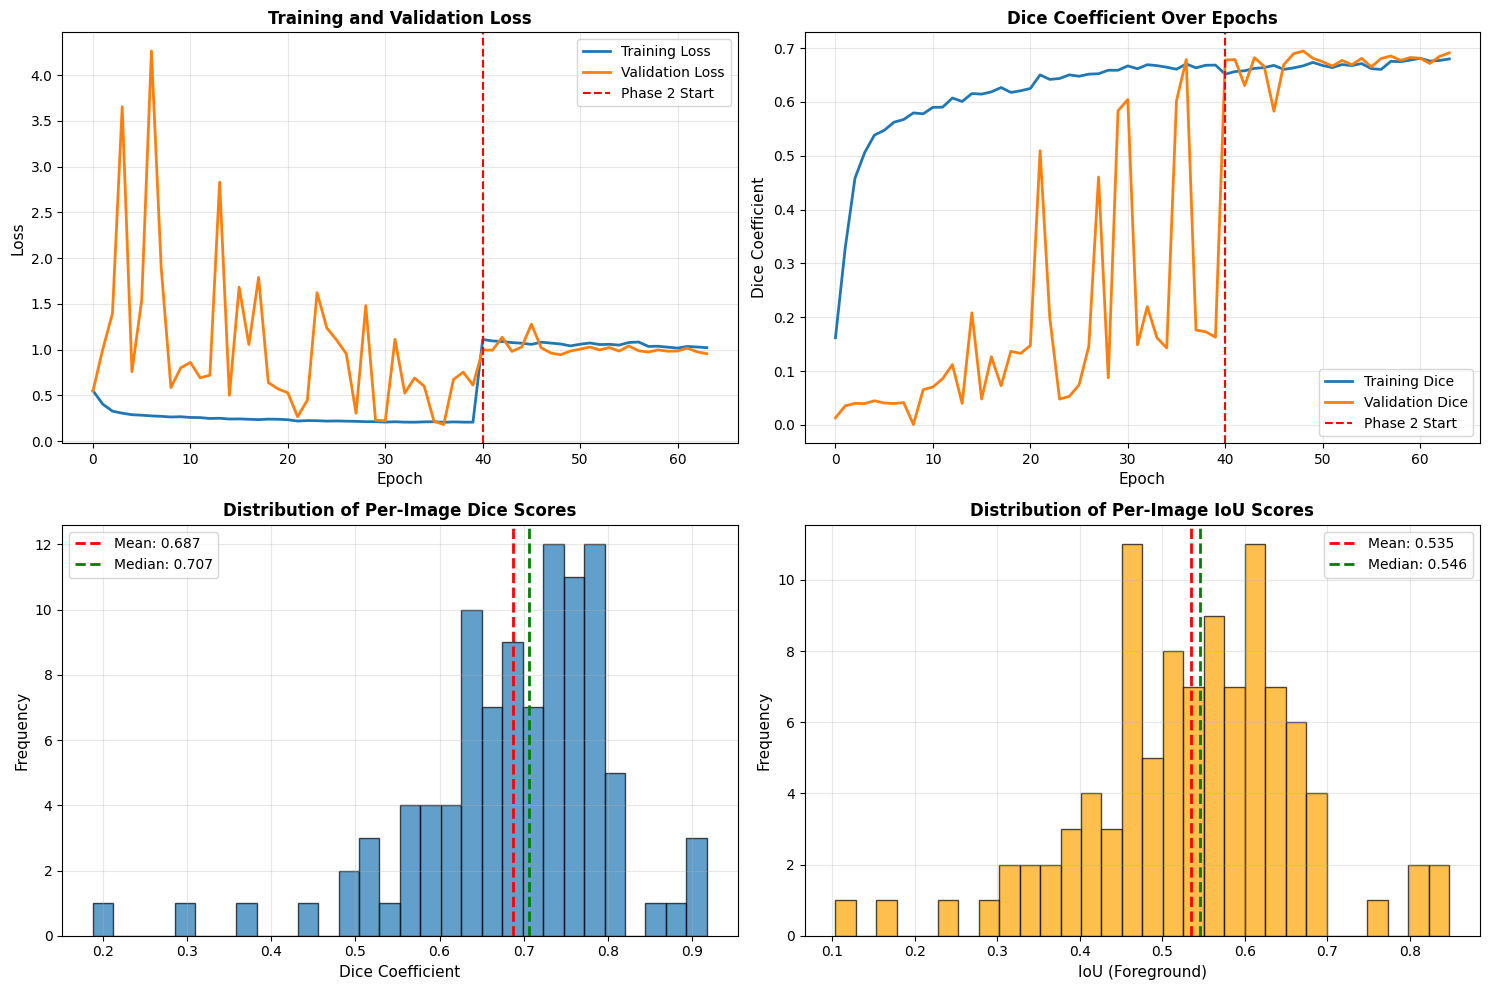

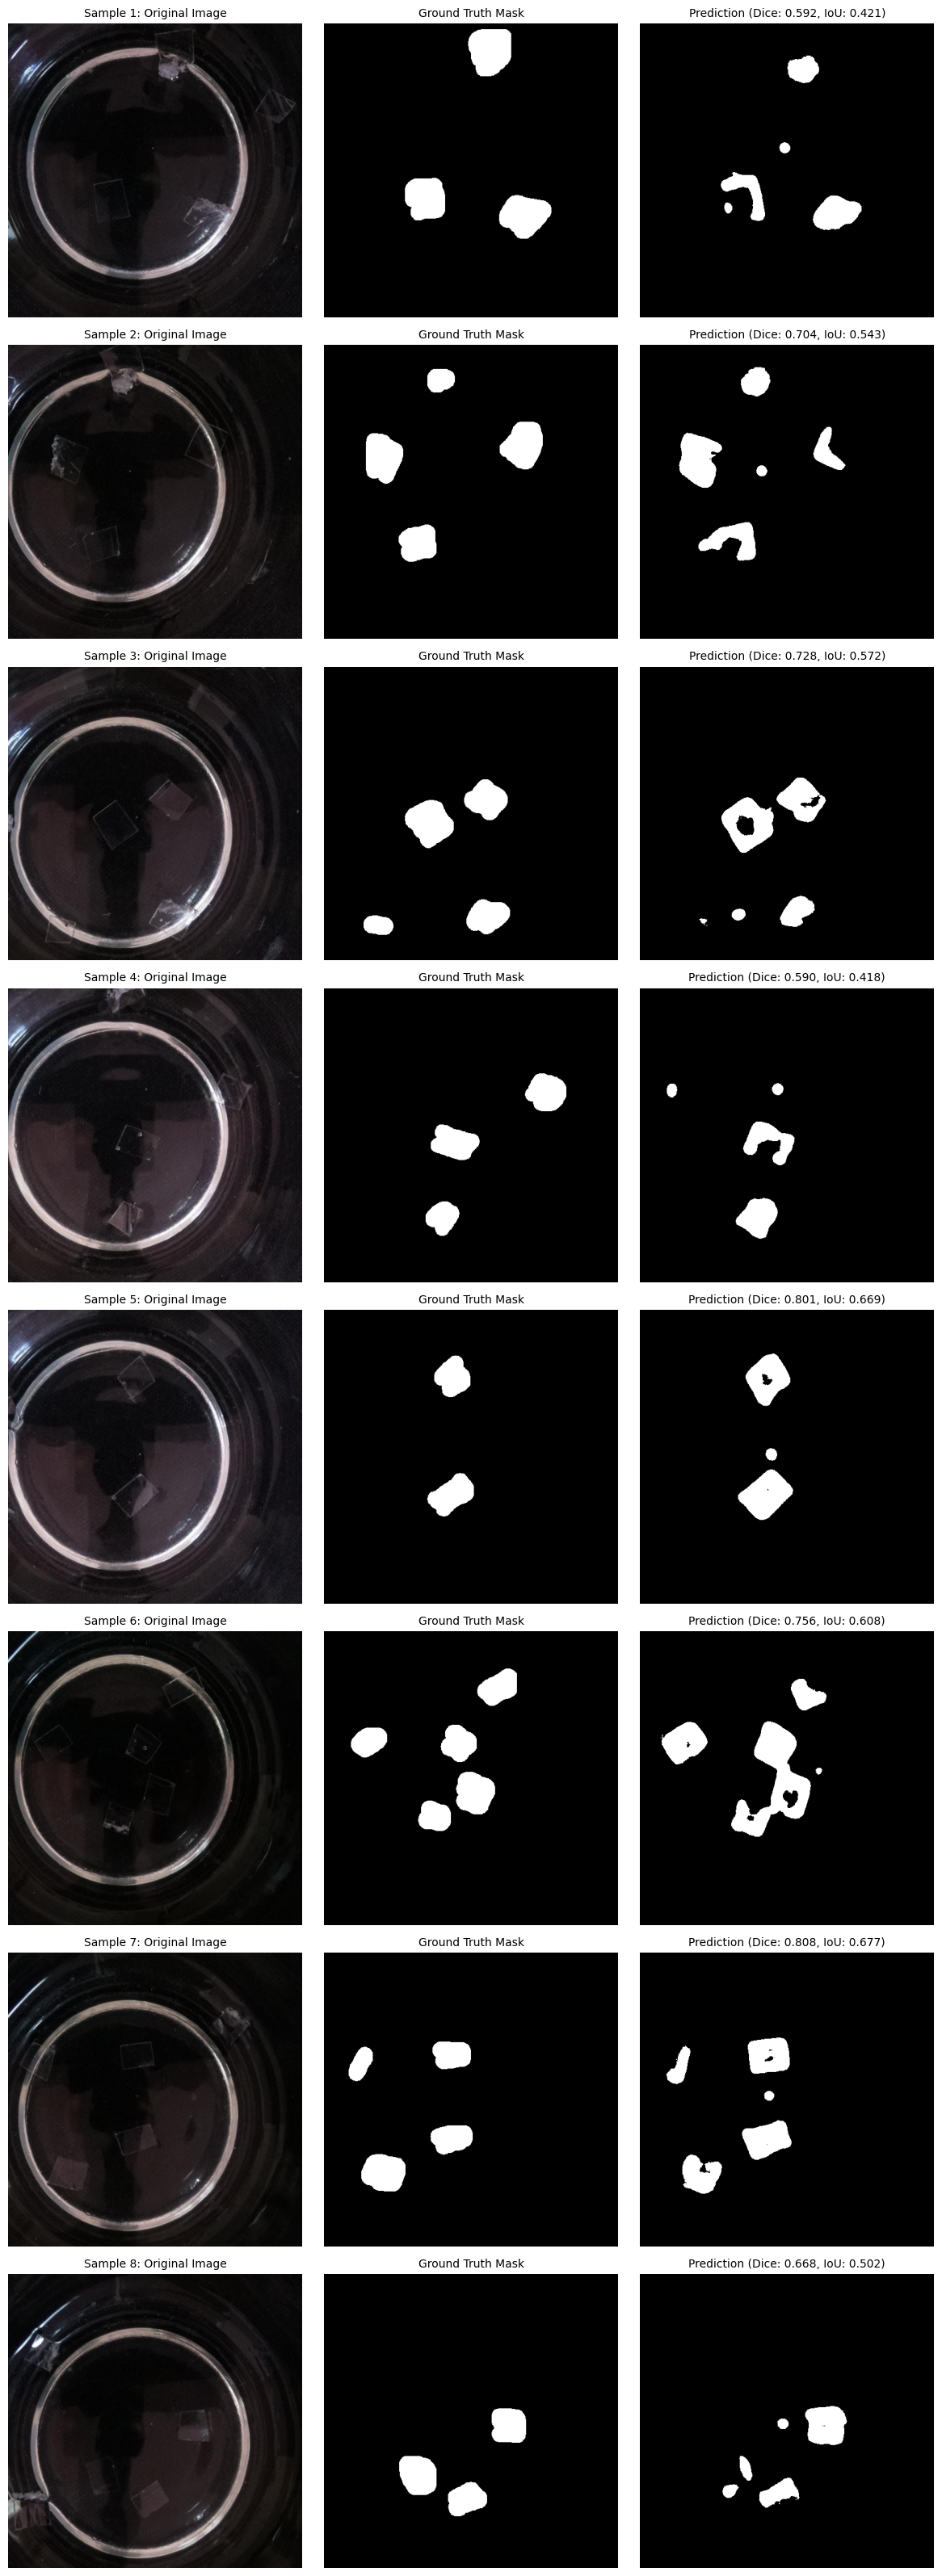

In [5]:
# ============================================================================
# COMPLETE TRAINING AND EVALUATION CODE - SEGMENTATION ONLY
# ============================================================================

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight

# ============================================================================
# CUSTOM LOSS FUNCTIONS
# ============================================================================

def calculate_class_weights(masks):
    """Calculate class weights for imbalanced segmentation."""
    if masks.ndim == 4:
        masks = masks.squeeze(-1)

    masks_binary = (masks > 0.5).astype(np.uint8).flatten()
    unique_classes = np.unique(masks_binary)

    if len(unique_classes) == 1:
        print(f"⚠️  Warning: Only class {unique_classes[0]} found in masks!")
        return {0: 1.0, 1: 1.0}

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.array([0, 1]),
        y=masks_binary
    )

    n_background = np.sum(masks_binary == 0)
    n_foreground = np.sum(masks_binary == 1)
    total = len(masks_binary)

    print(f"Class distribution:")
    print(f"  Background (0): {n_background:,} pixels ({100*n_background/total:.2f}%)")
    print(f"  Foreground (1): {n_foreground:,} pixels ({100*n_foreground/total:.2f}%)")
    print(f"  Class weights: {{0: {class_weights[0]:.4f}, 1: {class_weights[1]:.4f}}}")

    return {0: class_weights[0], 1: class_weights[1]}


def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Numerically stable Dice coefficient (per-sample, averaged)."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Remove channel dim if present
    if y_true.shape.ndims == 4 and y_true.shape[-1] == 1:
        y_true = tf.squeeze(y_true, axis=-1)
    if y_pred.shape.ndims == 4 and y_pred.shape[-1] == 1:
        y_pred = tf.squeeze(y_pred, axis=-1)

    batch_size = tf.shape(y_true)[0]

    y_true_flat = tf.reshape(y_true, [batch_size, -1])
    y_pred_flat = tf.reshape(y_pred, [batch_size, -1])

    intersection = tf.reduce_sum(y_true_flat * y_pred_flat, axis=1)
    union = tf.reduce_sum(y_true_flat, axis=1) + tf.reduce_sum(y_pred_flat, axis=1)

    dice_per_sample = (2.0 * intersection + smooth) / (union + smooth)

    # Guard against NaN / Inf
    dice_per_sample = tf.where(
        tf.math.is_finite(dice_per_sample),
        dice_per_sample,
        tf.zeros_like(dice_per_sample)
    )

    return tf.reduce_mean(dice_per_sample)


def dice_loss(y_true, y_pred, smooth=1e-6):
    """Dice loss for binary segmentation."""
    return 1.0 - dice_coefficient(y_true, y_pred, smooth)


def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    """Focal loss for handling class imbalance."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    if y_true.shape.ndims == 4 and y_true.shape[-1] == 1:
        y_true = tf.squeeze(y_true, axis=-1)
    if y_pred.shape.ndims == 4 and y_pred.shape[-1] == 1:
        y_pred = tf.squeeze(y_pred, axis=-1)

    y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())

    pt = tf.where(tf.equal(y_true, 1.0), y_pred, 1.0 - y_pred)
    alpha_t = tf.where(tf.equal(y_true, 1.0), alpha, 1.0 - alpha)

    focal_weight = alpha_t * tf.pow(1.0 - pt, gamma)
    loss = -focal_weight * tf.math.log(pt)

    return tf.reduce_mean(loss)


def tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, smooth=1e-6):
    """Tversky loss - generalization of Dice loss."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    if y_true.shape.ndims == 4 and y_true.shape[-1] == 1:
        y_true = tf.squeeze(y_true, axis=-1)
    if y_pred.shape.ndims == 4 and y_pred.shape[-1] == 1:
        y_pred = tf.squeeze(y_pred, axis=-1)

    batch_size = tf.shape(y_true)[0]
    y_true_flat = tf.reshape(y_true, [batch_size, -1])
    y_pred_flat = tf.reshape(y_pred, [batch_size, -1])

    true_pos = tf.reduce_sum(y_true_flat * y_pred_flat, axis=1)
    false_neg = tf.reduce_sum(y_true_flat * (1.0 - y_pred_flat), axis=1)
    false_pos = tf.reduce_sum((1.0 - y_true_flat) * y_pred_flat, axis=1)

    tversky_per_sample = (true_pos + smooth) / (
        true_pos + alpha * false_neg + beta * false_pos + smooth
    )

    return 1.0 - tf.reduce_mean(tversky_per_sample)


def safe_dice_bce_loss(y_true, y_pred):
    """Combined Binary Cross-Entropy and Dice loss."""
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return 0.5 * bce + 0.5 * dice


def focal_dice_loss(y_true, y_pred, gamma=2.0, dice_weight=3.0, focal_weight=1.0):
    """Combined Focal and Dice loss."""
    focal = focal_loss(y_true, y_pred, alpha=0.75, gamma=gamma)
    dice = dice_loss(y_true, y_pred)

    return focal_weight * focal + dice_weight * dice


def iou_metric(y_true, y_pred, smooth=1e-6, threshold=0.5):
    """IoU (Intersection over Union) metric with per-sample computation."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    if threshold is not None:
        y_pred = tf.cast(y_pred > threshold, tf.float32)

    if y_true.shape.ndims == 4 and y_true.shape[-1] == 1:
        y_true = tf.squeeze(y_true, axis=-1)
    if y_pred.shape.ndims == 4 and y_pred.shape[-1] == 1:
        y_pred = tf.squeeze(y_pred, axis=-1)

    batch_size = tf.shape(y_true)[0]
    y_true_flat = tf.reshape(y_true, [batch_size, -1])
    y_pred_flat = tf.reshape(y_pred, [batch_size, -1])

    intersection = tf.reduce_sum(y_true_flat * y_pred_flat, axis=1)
    union = tf.reduce_sum(y_true_flat, axis=1) + tf.reduce_sum(y_pred_flat, axis=1) - intersection

    iou_per_sample = (intersection + smooth) / (union + smooth)

    return tf.reduce_mean(iou_per_sample)


# ============================================================================
# PREDICTION MONITORING CALLBACK
# ============================================================================

class PredictionMonitor(tf.keras.callbacks.Callback):
    """Monitor and visualize predictions during training."""

    def __init__(self, val_data, val_masks, num_samples=4, show_interval=3):
        super().__init__()
        self.val_data_raw = val_data[:num_samples]
        self.val_masks = val_masks[:num_samples]
        self.num_samples = num_samples
        self.show_interval = show_interval

        # Manual preprocessing to match training
        val_data_scaled = self.val_data_raw * 255.0
        self.val_data_preprocessed = (val_data_scaled - 128.0) / 128.0

    def on_epoch_end(self, epoch, logs=None):
        """Called at the end of each epoch."""
        if epoch % self.show_interval == 0:
            preds = self.model.predict(self.val_data_preprocessed, verbose=0)
            preds = np.array(preds)

            if preds.ndim == 4 and preds.shape[-1] == 1:
                preds = np.squeeze(preds, axis=-1)

            # Check for NaN
            if np.any(np.isnan(preds)):
                print(f"\n  ⚠️  [Epoch {epoch}] WARNING: NaN values in predictions!")
                fg_pixels = 0
                total_pixels = preds.size
                max_pred = np.nan
                mean_pred = np.nan
                min_pred = np.nan
            else:
                fg_pixels = (preds > 0.5).sum()
                total_pixels = preds.size
                max_pred = preds.max()
                mean_pred = preds.mean()
                min_pred = preds.min()

            print(f"\n  📊 [Epoch {epoch}] Prediction Statistics:")
            print(f"      Range: [{min_pred:.4f}, {max_pred:.4f}], Mean: {mean_pred:.4f}")
            print(f"      Foreground pixels (>0.5): {fg_pixels:,}/{total_pixels:,} "
                  f"({fg_pixels/total_pixels*100:.3f}%)")

            val_masks_np = np.array(self.val_masks)
            if val_masks_np.ndim == 4 and val_masks_np.shape[-1] == 1:
                val_masks_np = np.squeeze(val_masks_np, axis=-1)

            for i in range(self.num_samples):
                if np.any(np.isnan(preds)):
                    print(f"      Sample {i+1} IoU: NaN (predictions contain NaN)")
                else:
                    pred_binary = (preds[i] > 0.5).astype(np.float32)
                    true_mask = (val_masks_np[i] > 0.5).astype(np.float32)

                    intersection = (pred_binary * true_mask).sum()
                    union = pred_binary.sum() + true_mask.sum() - intersection
                    iou = intersection / (union + 1e-6)

                    print(f"      Sample {i+1} IoU: {iou:.4f}")


# ============================================================================
# PREPROCESSING HELPER
# ============================================================================

def preprocess_test_data(X_test):
    """
    FIXED: Preprocess test data using the SAME pipeline as training.
    """
    if not isinstance(X_test, np.ndarray):
        X_test = np.array(X_test, dtype=np.float32)
    else:
        X_test = X_test.astype(np.float32)

    if X_test.ndim != 4 or X_test.shape[-1] != 3:
        raise ValueError(f"Expected (N, H, W, 3), got {X_test.shape}")

    # Ensure [0, 1] range
    max_val = X_test.max()
    if max_val > 1.5:
        print(f"⚠️  Normalizing from [0, 255] to [0, 1] range...")
        X_test = X_test / 255.0

    # FIXED: Manual EfficientNetV2 preprocessing to match training
    # Step 1: Scale to [0, 255]
    X_test_scaled = X_test * 255.0

    # Step 2: Apply EfficientNetV2 normalization: (x - 128) / 128
    X_test_preprocessed = (X_test_scaled - 128.0) / 128.0

    print(f"✓ Preprocessed {len(X_test)} test images")
    print(f"  Input range:  [{X_test.min():.4f}, {X_test.max():.4f}]")
    print(f"  Output range: [{X_test_preprocessed.min():.4f}, {X_test_preprocessed.max():.4f}]")

    # Verify preprocessing
    expected_min, expected_max = -1.0, 1.0
    actual_min, actual_max = X_test_preprocessed.min(), X_test_preprocessed.max()

    if not (expected_min - 0.1 <= actual_min and actual_max <= expected_max + 0.1):
        print(f"\n⚠️  WARNING: Preprocessing may be incorrect!")
        print(f"     Expected range: [{expected_min}, {expected_max}]")
        print(f"     Actual range:   [{actual_min:.4f}, {actual_max:.4f}]")
    else:
        print(f"  ✅ Preprocessing verified: range is correct")

    return X_test_preprocessed


# ============================================================================
# SEGMENTATION METRICS
# ============================================================================

def calculate_segmentation_metrics(y_true, y_pred, smooth=1e-6):
    """
    Calculate comprehensive segmentation metrics with proper edge case handling.

    Args:
        y_true: Ground truth masks, any shape, values will be binarized
        y_pred: Predicted masks, same shape as y_true, values will be binarized
        smooth: Smoothing factor for numerical stability (only used for Dice/IoU)

    Returns:
        dict: Dictionary containing all segmentation metrics
    """
    # Binarize inputs
    y_true = (y_true > 0.5).astype(np.uint8)
    y_pred = (y_pred > 0.5).astype(np.uint8)

    # Flatten for computation
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    # Calculate confusion matrix elements
    tp = np.sum((y_true_flat == 1) & (y_pred_flat == 1))
    fp = np.sum((y_true_flat == 0) & (y_pred_flat == 1))
    tn = np.sum((y_true_flat == 0) & (y_pred_flat == 0))
    fn = np.sum((y_true_flat == 1) & (y_pred_flat == 0))

    # =========================================================================
    # PRECISION: tp / (tp + fp)
    # Edge cases:
    #   - No predictions (tp=0, fp=0): precision = 0.0
    #   - Only correct predictions (fp=0): precision = 1.0
    # =========================================================================
    if (tp + fp) == 0:
        precision = 0.0  # No positive predictions made
    else:
        precision = tp / (tp + fp)

    # =========================================================================
    # RECALL: tp / (tp + fn)
    # Edge cases:
    #   - No ground truth positives (tp=0, fn=0): recall = 1.0 (nothing to find)
    #   - Found all positives (fn=0): recall = 1.0
    # =========================================================================
    if (tp + fn) == 0:
        recall = 1.0  # No ground truth positives (perfect recall by definition)
    else:
        recall = tp / (tp + fn)

    # =========================================================================
    # F1-SCORE: 2 * (precision * recall) / (precision + recall)
    # Edge cases:
    #   - Both precision and recall are 0: f1 = 0.0
    # =========================================================================
    if (precision + recall) == 0:
        f1 = 0.0
    else:
        f1 = 2 * (precision * recall) / (precision + recall)

    # =========================================================================
    # DICE COEFFICIENT: 2*tp / (2*tp + fp + fn)
    # Uses smooth for numerical stability
    # =========================================================================
    dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)

    # =========================================================================
    # IoU FOREGROUND: tp / (tp + fp + fn)
    # Uses smooth for numerical stability
    # =========================================================================
    iou_foreground = (tp + smooth) / (tp + fp + fn + smooth)

    # =========================================================================
    # IoU BACKGROUND: tn / (tn + fp + fn)
    # Uses smooth for numerical stability
    # =========================================================================
    iou_background = (tn + smooth) / (tn + fp + fn + smooth)

    # =========================================================================
    # MEAN IoU: Average of foreground and background IoU
    # =========================================================================
    miou = (iou_foreground + iou_background) / 2.0

    # =========================================================================
    # PIXEL ACCURACY: (tp + tn) / total
    # =========================================================================
    total = tp + tn + fp + fn
    if total == 0:
        pixel_accuracy = 0.0  # Should never happen with real images
    else:
        pixel_accuracy = (tp + tn) / total

    return {
        'dice': dice,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'miou': miou,
        'iou_foreground': iou_foreground,
        'iou_background': iou_background,
        'pixel_accuracy': pixel_accuracy,
        'tp': int(tp),
        'fp': int(fp),
        'tn': int(tn),
        'fn': int(fn)
    }





# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Validate required variables
    required_vars = ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test',
                     'train_dataset', 'val_dataset',
                     'build_efficientnetv2b3_mrfm_attention_unet',
                     'IMG_HEIGHT', 'IMG_WIDTH', 'BATCH_SIZE', 'EPOCHS', 'PATIENCE']

    missing_vars = [var for var in required_vars if var not in dir()]
    if missing_vars:
        raise NameError(f"Required variables missing: {missing_vars}")

    # Calculate class weights
    if len(y_train) > 0:
        class_weights = calculate_class_weights(y_train)

    print("\n" + "="*80)
    print("BUILDING MODEL")
    print("="*80)

    model, backbone = build_efficientnetv2b3_mrfm_attention_unet(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )

    print(f"✅ Model built successfully")
    print(f"   Total parameters: {model.count_params():,}")
    print(f"   Output shape: {model.output.shape}")

    # ========================================================================
    # PHASE 1: Train decoder (backbone frozen)
    # ========================================================================

    print("\n" + "="*80)
    print("PHASE 1: Training decoder (backbone frozen)")
    print("="*80)

    backbone.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3,
            clipnorm=1.0
        ),
        loss=safe_dice_bce_loss,
        metrics=[dice_coefficient, iou_metric]
    )

    print(f"✅ Model compiled for Phase 1")

    callbacks_phase1 = [
        tf.keras.callbacks.TerminateOnNaN(),
        PredictionMonitor(X_val, y_val),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_dice_coefficient',
            patience=15,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_dice_coefficient',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            '/content/efficientnetv2b3_mrfm_attention_phase1.weights.h5',
            monitor='val_dice_coefficient',
            save_best_only=True,
            save_weights_only=True,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.CSVLogger(
            '/content/training_log_phase1.csv',
            append=False
        )
    ]

    print(f"\nTraining Phase 1 with {len(X_train)} samples, batch size {BATCH_SIZE}")
    history_phase1 = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=40,
        callbacks=callbacks_phase1,
        verbose=1
    )

    print("\n📊 PHASE 1 RESULTS:")
    print(f"   Best Dice: {max(history_phase1.history['val_dice_coefficient']):.4f}")
    print(f"   Final Dice: {history_phase1.history['val_dice_coefficient'][-1]:.4f}")

    print("\n🔍 Training prediction check:")
    X_train_sample = X_train[:4]
    X_train_scaled = X_train_sample * 255.0
    X_train_preprocessed = (X_train_scaled - 128.0) / 128.0
    train_pred_check = model.predict(X_train_preprocessed, verbose=0)

    if train_pred_check.ndim == 4 and train_pred_check.shape[-1] == 1:
        train_pred_check = train_pred_check.squeeze(-1)

    if np.any(np.isnan(train_pred_check)):
        print("   ⚠️  WARNING: Predictions contain NaN values!")
    else:
        print(f"   Prediction range: [{train_pred_check.min():.4f}, {train_pred_check.max():.4f}]")
        print(f"   Prediction mean: {train_pred_check.mean():.4f}")
        print(f"   Foreground pixels (>0.5): {(train_pred_check > 0.5).sum():,} / {train_pred_check.size:,}")

    # ========================================================================
    # PHASE 2: Fine-tune entire model
    # ========================================================================

    print("\n" + "="*80)
    print("PHASE 2: Fine-tuning entire model")
    print("="*80)

    backbone.trainable = True

    # Unfreeze only last 80 layers
    for layer in backbone.layers[:-80]:
        layer.trainable = False

    # Keep BatchNorm frozen for stability
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    trainable_backbone = sum([1 for l in backbone.layers if l.trainable])
    trainable_total = sum([1 for l in model.layers if l.trainable])
    print(f"Trainable layers in backbone: {trainable_backbone}")
    print(f"Total trainable layers: {trainable_total}")

    optimizer_ft = tf.keras.optimizers.AdamW(
        learning_rate=5e-5,
        weight_decay=1e-5,
        beta_1=0.9,
        beta_2=0.999,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer_ft,
        loss=focal_dice_loss,
        metrics=[
            dice_coefficient,
            iou_metric,
            'binary_accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    print(f"✅ Model recompiled for Phase 2")

    callbacks_phase2 = [
        PredictionMonitor(X_val, y_val),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_dice_coefficient',
            patience=PATIENCE,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_dice_coefficient',
            factor=0.5,
            patience=8,
            min_lr=1e-7,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            '/content/efficientnetv2b3_mrfm_attention_final.weights.h5',
            monitor='val_dice_coefficient',
            save_best_only=True,
            save_weights_only=True,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.CSVLogger(
            '/content/training_log_phase2.csv',
            append=False
        ),
        tf.keras.callbacks.TerminateOnNaN()
    ]

    print(f"\nTraining Phase 2 with {len(X_train)} samples, batch size {BATCH_SIZE}")

    history_phase2 = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=callbacks_phase2,
        verbose=1
    )

    print("\n✅ Two-phase training complete!")
    print(f"   Phase 1 - Best Dice: {max(history_phase1.history['val_dice_coefficient']):.4f}")
    print(f"   Phase 1 - Total epochs: {len(history_phase1.history['loss'])}")
    print(f"   Phase 2 - Best Dice: {max(history_phase2.history['val_dice_coefficient']):.4f}")
    print(f"   Phase 2 - Total epochs: {len(history_phase2.history['loss'])}")

    # Performance analysis
    phase1_best = max(history_phase1.history['val_dice_coefficient'])
    phase2_best = max(history_phase2.history['val_dice_coefficient'])
    improvement = phase2_best - phase1_best

    print(f"\n📊 Performance Analysis:")
    print(f"   Improvement from Phase 1 to Phase 2: {improvement:+.4f}")
    if improvement < 0.005:
        print("   ⚠️  Warning: Minimal improvement. Consider:")
        print("      - Reducing learning rate further")
        print("      - Unfreezing fewer layers")
        print("      - Adding more data augmentation")

    # Check train-val gap for overfitting
    if len(history_phase2.history['dice_coefficient']) > 0:
        final_train_dice = history_phase2.history['dice_coefficient'][-1]
        final_val_dice = history_phase2.history['val_dice_coefficient'][-1]
        dice_gap = final_train_dice - final_val_dice

        print(f"\n🔍 Overfitting Check:")
        print(f"   Final Training Dice: {final_train_dice:.4f}")
        print(f"   Final Validation Dice: {final_val_dice:.4f}")
        print(f"   Train-Val Gap: {dice_gap:.4f}")

        if dice_gap > 0.1:
            print("   ⚠️  WARNING: Significant overfitting detected!")
            print("      Recommendations:")
            print("      - Increase weight_decay (try 1e-4)")
            print("      - Add dropout layers to decoder")
            print("      - Use stronger data augmentation")
            print("      - Reduce number of trainable layers")
        elif dice_gap > 0.05:
            print("   ⚠️  Moderate overfitting - monitor closely")
        else:
            print("   ✅ No significant overfitting detected")

    # ========================================================================
    # EVALUATION
    # ========================================================================

    print("\n" + "="*80)
    print("EVALUATING BEST MODEL")
    print("="*80)

    print("Reconstructing model architecture...")
    model, backbone = build_efficientnetv2b3_mrfm_attention_unet(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )

    backbone.trainable = True
    for layer in backbone.layers[:-80]:
        layer.trainable = False

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    optimizer_ft = tf.keras.optimizers.AdamW(
        learning_rate=5e-5,
        weight_decay=1e-5,
        beta_1=0.9,
        beta_2=0.999
    )

    model.compile(
        optimizer=optimizer_ft,
        loss=focal_dice_loss,
        metrics=[
            dice_coefficient,
            iou_metric,
            'binary_accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    print("Loading best weights...")
    model.load_weights('/content/efficientnetv2b3_mrfm_attention_final.weights.h5')
    print("✅ Model weights loaded successfully")

    print("Preprocessing test data...")
    X_test_preprocessed = preprocess_test_data(X_test)

    print("Generating predictions on test set...")
    test_pred_raw = model.predict(X_test_preprocessed, batch_size=BATCH_SIZE, verbose=1)

    # Check for NaN predictions
    if np.any(np.isnan(test_pred_raw)):
        print("\n⚠️  CRITICAL ERROR: Predictions contain NaN values!")
        print("This indicates a serious training problem. Possible causes:")
        print("  1. Gradient explosion/vanishing")
        print("  2. Learning rate too high")
        print("  3. Numerical instability in loss function")
        print("  4. Corrupted model weights")
        print("\nRecommendations:")
        print("  - Check training logs for NaN during training")
        print("  - Reduce learning rate")
        print("  - Check data preprocessing")
        print("  - Add gradient clipping")

        print("\nSetting all predictions to zero to allow evaluation to continue...")
        test_pred_raw = np.zeros_like(test_pred_raw)
    else:
        print(f"Predictions shape: {test_pred_raw.shape}")
        print(f"Predictions range: [{test_pred_raw.min():.4f}, {test_pred_raw.max():.4f}]")

    # ========================================================================
    # SEGMENTATION EVALUATION
    # ========================================================================

    print("\n" + "="*80)
    print("SEGMENTATION PERFORMANCE EVALUATION")
    print("="*80)

    # Ensure predictions are in correct shape
    if len(test_pred_raw.shape) == 4 and test_pred_raw.shape[-1] == 1:
        test_pred_raw_2d = test_pred_raw.squeeze(-1)
    else:
        test_pred_raw_2d = test_pred_raw

    # Simple thresholding (no post-processing)
    seg_threshold = 0.5
    y_pred_binary = (test_pred_raw_2d > seg_threshold).astype(np.uint8)

    print(f"\nUsing threshold: {seg_threshold}")
    print(f"Predicted foreground pixels: {y_pred_binary.sum():,}")

    # Prepare ground truth
    y_test_eval = y_test.copy()
    if len(y_test_eval.shape) == 4 and y_test_eval.shape[-1] == 1:
        y_test_eval = y_test_eval.squeeze(-1)

    # Calculate metrics
    print("\nCalculating segmentation metrics...")
    seg_metrics = calculate_segmentation_metrics(
        y_test_eval.astype(np.uint8),
        y_pred_binary
    )

    # Display results
    print(f"\n{'Metric':<25} {'Value':<10}")
    print("-" * 40)
    print(f"{'Dice Coefficient':<25} {seg_metrics['dice']:.4f}")
    print(f"{'Precision':<25} {seg_metrics['precision']:.4f}")
    print(f"{'Recall':<25} {seg_metrics['recall']:.4f}")
    print(f"{'F1-score':<25} {seg_metrics['f1']:.4f}")
    print(f"{'mIoU':<25} {seg_metrics['miou']:.4f}")
    print(f"{'IoU (Foreground)':<25} {seg_metrics['iou_foreground']:.4f}")
    print(f"{'IoU (Background)':<25} {seg_metrics['iou_background']:.4f}")
    print(f"{'Pixel Accuracy':<25} {seg_metrics['pixel_accuracy']:.4f}")

    # ========================================================================
    # SAVE RESULTS
    # ========================================================================

    os.makedirs('results_efficientnetv2b3_mrfm_attention_512', exist_ok=True)

    print("\n" + "="*80)
    print("SAVING RESULTS")
    print("="*80)

    # Save per-image metrics
    results_df = pd.DataFrame({
        'Image_Index': range(len(y_test_eval)),
    })

    # Calculate per-image metrics
    per_image_dice = []
    per_image_iou = []
    per_image_precision = []
    per_image_recall = []

    for i in range(len(y_test_eval)):
        img_metrics = calculate_segmentation_metrics(
            y_test_eval[i:i+1],
            y_pred_binary[i:i+1]
        )
        per_image_dice.append(img_metrics['dice'])
        per_image_iou.append(img_metrics['iou_foreground'])
        per_image_precision.append(img_metrics['precision'])
        per_image_recall.append(img_metrics['recall'])

    results_df['Dice'] = per_image_dice
    results_df['IoU_Foreground'] = per_image_iou
    results_df['Precision'] = per_image_precision
    results_df['Recall'] = per_image_recall

    results_df.to_csv('results_efficientnetv2b3_mrfm_attention_512/per_image_results.csv', index=False)

    # Save overall performance summary
    with open('results_efficientnetv2b3_mrfm_attention_512/performance_summary.txt', 'w') as f:
        f.write("="*80 + "\n")
        f.write("PERFORMANCE SUMMARY - SEGMENTATION ONLY\n")
        f.write("="*80 + "\n\n")

        f.write("OVERALL SEGMENTATION METRICS\n")
        f.write("-" * 40 + "\n")
        f.write(f"  Dice Coefficient:  {seg_metrics['dice']:.4f}\n")
        f.write(f"  Precision:         {seg_metrics['precision']:.4f}\n")
        f.write(f"  Recall:            {seg_metrics['recall']:.4f}\n")
        f.write(f"  F1-score:          {seg_metrics['f1']:.4f}\n")
        f.write(f"  mIoU:              {seg_metrics['miou']:.4f}\n")
        f.write(f"  IoU (Foreground):  {seg_metrics['iou_foreground']:.4f}\n")
        f.write(f"  IoU (Background):  {seg_metrics['iou_background']:.4f}\n")
        f.write(f"  Pixel Accuracy:    {seg_metrics['pixel_accuracy']:.4f}\n\n")

        f.write("PER-IMAGE STATISTICS\n")
        f.write("-" * 40 + "\n")
        f.write(f"  Dice - Mean:   {np.mean(per_image_dice):.4f} ± {np.std(per_image_dice):.4f}\n")
        f.write(f"  Dice - Median: {np.median(per_image_dice):.4f}\n")
        f.write(f"  Dice - Min:    {np.min(per_image_dice):.4f}\n")
        f.write(f"  Dice - Max:    {np.max(per_image_dice):.4f}\n\n")

        f.write(f"  IoU - Mean:    {np.mean(per_image_iou):.4f} ± {np.std(per_image_iou):.4f}\n")
        f.write(f"  IoU - Median:  {np.median(per_image_iou):.4f}\n")
        f.write(f"  IoU - Min:     {np.min(per_image_iou):.4f}\n")
        f.write(f"  IoU - Max:     {np.max(per_image_iou):.4f}\n\n")

        f.write("TRAINING INFORMATION\n")
        f.write("-" * 40 + "\n")
        f.write(f"  Phase 1 Best Dice:  {phase1_best:.4f}\n")
        f.write(f"  Phase 2 Best Dice:  {phase2_best:.4f}\n")
        f.write(f"  Improvement:        {improvement:+.4f}\n")
        f.write(f"  Total Epochs:       {len(history_phase1.history['loss']) + len(history_phase2.history['loss'])}\n")

    print("✅ Results saved to 'results_efficientnetv2b3_mrfm_attention_512/'")

    # ========================================================================
    # PLOT TRAINING HISTORY
    # ========================================================================

    print("\n" + "="*80)
    print("GENERATING TRAINING PLOTS")
    print("="*80)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Combine phase 1 and phase 2 histories
    all_loss = history_phase1.history['loss'] + history_phase2.history['loss']
    all_val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']
    all_dice = history_phase1.history['dice_coefficient'] + history_phase2.history['dice_coefficient']
    all_val_dice = history_phase1.history['val_dice_coefficient'] + history_phase2.history['val_dice_coefficient']

    # Loss plot
    axes[0, 0].plot(all_loss, label='Training Loss', linewidth=2)
    axes[0, 0].plot(all_val_loss, label='Validation Loss', linewidth=2)
    axes[0, 0].axvline(x=len(history_phase1.history['loss']), color='red', linestyle='--',
                       label='Phase 2 Start', linewidth=1.5)
    axes[0, 0].set_xlabel('Epoch', fontsize=11)
    axes[0, 0].set_ylabel('Loss', fontsize=11)
    axes[0, 0].set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)

    # Dice coefficient plot
    axes[0, 1].plot(all_dice, label='Training Dice', linewidth=2)
    axes[0, 1].plot(all_val_dice, label='Validation Dice', linewidth=2)
    axes[0, 1].axvline(x=len(history_phase1.history['loss']), color='red', linestyle='--',
                       label='Phase 2 Start', linewidth=1.5)
    axes[0, 1].set_xlabel('Epoch', fontsize=11)
    axes[0, 1].set_ylabel('Dice Coefficient', fontsize=11)
    axes[0, 1].set_title('Dice Coefficient Over Epochs', fontsize=12, fontweight='bold')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)

    # Per-image Dice distribution
    axes[1, 0].hist(per_image_dice, bins=30, edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(x=np.mean(per_image_dice), color='red', linestyle='--',
                       label=f'Mean: {np.mean(per_image_dice):.3f}', linewidth=2)
    axes[1, 0].axvline(x=np.median(per_image_dice), color='green', linestyle='--',
                       label=f'Median: {np.median(per_image_dice):.3f}', linewidth=2)
    axes[1, 0].set_xlabel('Dice Coefficient', fontsize=11)
    axes[1, 0].set_ylabel('Frequency', fontsize=11)
    axes[1, 0].set_title('Distribution of Per-Image Dice Scores', fontsize=12, fontweight='bold')
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)

    # Per-image IoU distribution
    axes[1, 1].hist(per_image_iou, bins=30, edgecolor='black', alpha=0.7, color='orange')
    axes[1, 1].axvline(x=np.mean(per_image_iou), color='red', linestyle='--',
                       label=f'Mean: {np.mean(per_image_iou):.3f}', linewidth=2)
    axes[1, 1].axvline(x=np.median(per_image_iou), color='green', linestyle='--',
                       label=f'Median: {np.median(per_image_iou):.3f}', linewidth=2)
    axes[1, 1].set_xlabel('IoU (Foreground)', fontsize=11)
    axes[1, 1].set_ylabel('Frequency', fontsize=11)
    axes[1, 1].set_title('Distribution of Per-Image IoU Scores', fontsize=12, fontweight='bold')
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results_efficientnetv2b3_mrfm_attention_512/training_summary.png',
                dpi=300, bbox_inches='tight')
    print("✅ Training plots saved")

    # ========================================================================
    # VISUALIZE SAMPLE PREDICTIONS
    # ========================================================================

    print("\nGenerating sample prediction visualizations...")

    num_samples = min(8, len(X_test))
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_samples):
        # Original image
        axes[i, 0].imshow(X_test[i])
        axes[i, 0].set_title(f'Sample {i+1}: Original Image', fontsize=10)
        axes[i, 0].axis('off')

        # Ground truth mask
        gt_mask = y_test_eval[i]
        axes[i, 1].imshow(gt_mask, cmap='gray')
        axes[i, 1].set_title(f'Ground Truth Mask', fontsize=10)
        axes[i, 1].axis('off')

        # Predicted mask
        pred_mask = y_pred_binary[i]
        axes[i, 2].imshow(pred_mask, cmap='gray')
        img_dice = per_image_dice[i]
        img_iou = per_image_iou[i]
        axes[i, 2].set_title(f'Prediction (Dice: {img_dice:.3f}, IoU: {img_iou:.3f})', fontsize=10)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig('results_efficientnetv2b3_mrfm_attention_512/sample_predictions.png',
                dpi=200, bbox_inches='tight')
    print("✅ Sample predictions saved")

    print("\n" + "="*80)
    print("TRAINING AND EVALUATION COMPLETE")
    print("="*80)
    print(f"\n📊 Final Results:")
    print(f"   Segmentation Dice:      {seg_metrics['dice']:.4f}")
    print(f"   Segmentation Precision: {seg_metrics['precision']:.4f}")
    print(f"   Segmentation Recall:    {seg_metrics['recall']:.4f}")
    print(f"   mIoU:                   {seg_metrics['miou']:.4f}")
    print(f"   IoU (Foreground):       {seg_metrics['iou_foreground']:.4f}")
    print(f"   Pixel Accuracy:         {seg_metrics['pixel_accuracy']:.4f}")
    print(f"\n✅ All results saved to: results_efficientnetv2b3_mrfm_attention_512/")
    print("="*80)

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras import mixed_precision
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns
import pandas as pd
from skimage.transform import rotate, resize
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# GPU SETUP
# ============================================================================

# Confirm GPU
gpus = tf.config.list_physical_devices('GPU')
assert len(gpus) > 0, "❌ No GPU detected!"
print("✅ GPU detected:", gpus)

# Enable memory growth
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# Enable mixed precision
mixed_precision.set_global_policy('mixed_float16')
print("✅ Mixed precision enabled")

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Configuration
IMG_HEIGHT = 512
IMG_WIDTH = 512
BATCH_SIZE = 4
EPOCHS = 50
PATIENCE = 15

# Paths to your data
TRAIN_IMAGE_DIR = '/content/training/training/Training_original'
TRAIN_MASK_DIR = '/content/training/training/Finalmasks'
VAL_IMAGE_DIR = '/content/val/val/Original'
VAL_MASK_DIR = '/content/val/val/val_100masks'
TEST_IMAGE_DIR = '/content/Testing/Testing/Original'
TEST_MASK_DIR = '/content/Testing/Testing/testing_100masks'


# ============================================================================
# 1. FILENAME NORMALIZATION
# ============================================================================

def normalize_name(name):
    """Normalize filename for matching."""
    name = os.path.basename(name)
    name = os.path.splitext(name)[0]
    name = name.replace('_mask', '')
    return name

# ============================================================================
# 2. PREPROCESSING FUNCTIONS
# ============================================================================

def preprocess_mask(mask):
    """Proper mask binarization for binary segmentation."""
    # Handle multi-channel masks
    if len(mask.shape) == 3:
        mask = mask[:, :, 0]

    mask_binary = (mask > 127).astype(np.float32)
    return mask_binary

# ============================================================================
# 3. SEGMENTATION METRICS FUNCTIONS
# ============================================================================

def calculate_iou(y_true, y_pred, return_class_iou=False):
    """Calculate Intersection over Union for binary masks."""
    # Ensure binary masks (0 or 1)
    y_true = (y_true.flatten() > 0.5).astype(np.uint8)
    y_pred = (y_pred.flatten() > 0.5).astype(np.uint8)

    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection

    # If both masks are empty, they match perfectly
    if union == 0:
        iou = 1.0
    else:
        iou = intersection / union

    # Optionally return foreground-specific IoU
    if return_class_iou:
        # IoU for particles only (class 1)
        fg_intersection = intersection
        fg_union = union
        fg_iou = fg_intersection / fg_union if fg_union > 0 else 0.0

        return {
            'iou': iou,
            'foreground_iou': fg_iou,
            'has_particles': np.sum(y_true) > 0
        }

    return iou

def calculate_miou(y_true, y_pred):
    """Calculate mean Intersection over Union for both classes."""
    # Ensure binary masks (0 or 1)
    y_true = (y_true.flatten() > 0.5).astype(np.uint8)
    y_pred = (y_pred.flatten() > 0.5).astype(np.uint8)

    # Calculate IoU for both classes
    iou_background = calculate_iou(1 - y_true, 1 - y_pred)
    iou_foreground = calculate_iou(y_true, y_pred)

    miou = (iou_background + iou_foreground) / 2.0

    # Calculate class frequencies for context
    bg_ratio = np.mean(1 - y_true)
    fg_ratio = np.mean(y_true)

    return {
        'iou_background': iou_background,
        'iou_foreground': iou_foreground,
        'miou': miou,
        'background_ratio': bg_ratio,
        'foreground_ratio': fg_ratio
    }


def calculate_segmentation_metrics(y_true, y_pred_binary):
    """Calculate pixel-wise segmentation metrics."""
    # Ensure binary masks (0 or 1)
    y_true_flat = (y_true.flatten() > 0.5).astype(np.uint8)
    y_pred_flat = (y_pred_binary.flatten() > 0.5).astype(np.uint8)

    # Sklearn metrics (these handle empty masks appropriately)
    precision = precision_score(y_true_flat, y_pred_flat, zero_division=0)
    recall = recall_score(y_true_flat, y_pred_flat, zero_division=0)
    f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)

    # Dice coefficient (same as F1, but calculated manually for clarity)
    intersection = np.sum(y_true_flat * y_pred_flat)
    sum_masks = np.sum(y_true_flat) + np.sum(y_pred_flat)

    if sum_masks == 0:
        dice = 1.0  # Both masks empty = perfect match
    else:
        dice = (2.0 * intersection) / sum_masks

    # IoU metrics
    miou_metrics = calculate_miou(y_true_flat, y_pred_flat)

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'dice': dice,
        'iou_background': miou_metrics['iou_background'],
        'iou_foreground': miou_metrics['iou_foreground'],
        'miou': miou_metrics['miou']
    }

def remove_border_objects(binary_mask, border_width=5):
    """
    Remove objects touching image borders.

    Args:
        binary_mask: Binary mask (H, W) with values in {0, 1}
        border_width: Width of border region in pixels

    Returns:
        Cleaned binary mask with border objects removed
    """
    # Ensure uint8 for cv2 operations
    if binary_mask.dtype != np.uint8:
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

    if binary_mask.sum() == 0:
        return binary_mask

    # Find connected components
    num_labels, labels = cv2.connectedComponents(binary_mask, connectivity=8)

    if num_labels <= 1:  # Only background
        return binary_mask

    # Create border mask
    h, w = binary_mask.shape[:2]
    border_mask = np.zeros_like(binary_mask, dtype=bool)
    border_mask[:border_width, :] = True
    border_mask[-border_width:, :] = True
    border_mask[:, :border_width] = True
    border_mask[:, -border_width:] = True

    # Remove objects touching borders
    output = binary_mask.copy()
    for i in range(1, num_labels):
        obj_mask = (labels == i)
        if np.any(obj_mask & border_mask):
            output[obj_mask] = 0

    return output.astype(np.uint8)


def adaptive_min_area_filtering(binary_mask, percentile=3):
    """
    Remove very small noise components based on size distribution.

    Args:
        binary_mask: Binary mask (H, W) with values in {0, 1}
        percentile: Percentile threshold for minimum area (lower = more aggressive)

    Returns:
        Size-filtered binary mask
    """
    if binary_mask.dtype != np.uint8:
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

    if binary_mask.sum() == 0:
        return binary_mask

    # Find connected components
    num_labels, labels = cv2.connectedComponents(binary_mask, connectivity=8)

    if num_labels <= 1:
        return binary_mask

    # Calculate areas of all components
    areas = np.array([np.sum(labels == i) for i in range(1, num_labels)])

    if len(areas) == 0:
        return binary_mask

    # Calculate minimum area threshold
    if len(areas) > 5:
        min_area = np.percentile(areas, percentile)
    else:
        min_area = np.min(areas) * 0.5

    # Filter components by area
    filtered_mask = np.zeros_like(binary_mask)
    for i in range(1, num_labels):
        if areas[i-1] >= min_area:
            filtered_mask[labels == i] = 1

    return filtered_mask.astype(np.uint8)


def confidence_noise_suppression(binary_mask, prob_map, threshold=0.3):
    """
    Suppress low-confidence components based on average probability.

    Args:
        binary_mask: Binary mask (H, W) with values in {0, 1}
        prob_map: Probability map (H, W) with values in [0, 1]
        threshold: Minimum average probability to keep a component

    Returns:
        Confidence-filtered binary mask
    """
    if binary_mask.dtype != np.uint8:
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

    if binary_mask.sum() == 0:
        return binary_mask

    # Find connected components
    num_labels, labels = cv2.connectedComponents(binary_mask, connectivity=8)

    if num_labels <= 1:
        return binary_mask

    # Filter by confidence
    cleaned_mask = binary_mask.copy()
    for i in range(1, num_labels):
        component_mask = (labels == i)
        component_prob = np.mean(prob_map[component_mask])

        if component_prob < threshold:
            cleaned_mask[component_mask] = 0

    return cleaned_mask.astype(np.uint8)


def stable_postprocessing(predictions, threshold=0.3,
                          border_width=5,
                          size_percentile=3,
                          confidence_threshold=0.3,
                          morph_kernel_size=2):
    """
    Apply comprehensive post-processing pipeline to model predictions.

    This is the MAIN post-processing function - use this for evaluation.

    Args:
        predictions: Model predictions, shape (N, H, W, 1) or (N, H, W)
        threshold: Binary threshold for initial segmentation
        border_width: Width of border region for object removal
        size_percentile: Percentile for adaptive size filtering
        confidence_threshold: Minimum confidence for component retention
        morph_kernel_size: Kernel size for morphological operations

    Returns:
        Post-processed predictions, shape (N, H, W, 1)
    """
    processed = []

    for pred in predictions:
        # Ensure 2D probability map
        if len(pred.shape) == 3 and pred.shape[-1] == 1:
            pred_prob = pred.squeeze(-1)
        else:
            pred_prob = pred.squeeze()

        # Step 1: Initial binary thresholding
        binary_pred = (pred_prob > threshold).astype(np.uint8)

        if binary_pred.sum() == 0:
            processed.append(np.zeros_like(binary_pred, dtype=np.float32))
            continue

        # Step 2: Remove border objects
        binary_no_border = remove_border_objects(binary_pred, border_width=border_width)

        if binary_no_border.sum() == 0:
            processed.append(np.zeros_like(binary_no_border, dtype=np.float32))
            continue

        # Step 3: Morphological cleaning (opening + closing)
        kernel = np.ones((morph_kernel_size, morph_kernel_size), np.uint8)
        cleaned = cv2.morphologyEx(binary_no_border, cv2.MORPH_OPEN, kernel)
        cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

        if cleaned.sum() == 0:
            processed.append(np.zeros_like(cleaned, dtype=np.float32))
            continue

        # Step 4: Adaptive size filtering
        size_filtered = adaptive_min_area_filtering(cleaned, percentile=size_percentile)

        if size_filtered.sum() == 0:
            processed.append(np.zeros_like(size_filtered, dtype=np.float32))
            continue

        # Step 5: Confidence-based noise suppression
        final_mask = confidence_noise_suppression(
            size_filtered, pred_prob, threshold=confidence_threshold
        )

        processed.append(final_mask.astype(np.float32))

    # Return with channel dimension (N, H, W, 1)
    return np.array(processed)[..., np.newaxis].astype(np.float32)

# ============================================================================
# 4. DATA AUGMENTATION FUNCTIONS
# ============================================================================

def augment_geometric_numpy(image, mask, seed=None):
    """Apply geometric augmentations (rotation, zoom, flip) with consistent randomness."""
    # Convert TensorFlow tensors to numpy arrays
    if hasattr(image, 'numpy'):
        image = image.numpy()
    if hasattr(mask, 'numpy'):
        mask = mask.numpy()

    # Ensure numpy arrays
    image = np.asarray(image, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)

    if seed is not None:
        np.random.seed(seed)

    # Store original mask dimensionality
    mask_is_2d = (mask.ndim == 2)
    if mask_is_2d:
        mask = np.expand_dims(mask, axis=-1)

    # Ensure image is 3D (H, W, C)
    image_is_2d = (image.ndim == 2)
    if image_is_2d:
        image = np.expand_dims(image, axis=-1)

    h, w = image.shape[:2]

    # Random rotation (use order=0 for mask to avoid interpolation)
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-30, 30)
        image = rotate(image, angle, mode='reflect', preserve_range=True)
        mask = rotate(mask, angle, mode='constant', preserve_range=True, order=0)  # Nearest neighbor for mask

    # Random zoom
    if np.random.rand() < 0.5:
        zoom_factor = np.random.uniform(0.8, 1.2)
        new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)

        image_zoomed = resize(image, (new_h, new_w), preserve_range=True, anti_aliasing=True)
        mask_zoomed = resize(mask, (new_h, new_w), preserve_range=True, anti_aliasing=False, order=0)

        # Center crop or pad to original size
        if zoom_factor > 1.0:  # Crop
            start_h = (new_h - h) // 2
            start_w = (new_w - w) // 2
            image = image_zoomed[start_h:start_h+h, start_w:start_w+w]
            mask = mask_zoomed[start_h:start_h+h, start_w:start_w+w]
        else:  # Pad
            pad_h = (h - new_h) // 2
            pad_w = (w - new_w) // 2

            image = np.pad(image_zoomed,
                          ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                          mode='reflect')
            mask = np.pad(mask_zoomed,
                         ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                         mode='constant', constant_values=0)

    # Random horizontal flip
    if np.random.rand() < 0.5:
        image = np.fliplr(image)
        mask = np.fliplr(mask)

    # Random vertical flip
    if np.random.rand() < 0.5:
        image = np.flipud(image)
        mask = np.flipud(mask)

    # Re-binarize mask to ensure clean binary values after transformations
    mask = (mask > 0.5).astype(np.float32)

    # Restore original dimensions if needed
    if mask_is_2d:
        mask = mask[..., 0]
    if image_is_2d:
        image = image[..., 0]

    return image.astype(np.float32), mask.astype(np.float32)


def augment_photometric_numpy(image, seed=None,
                               brightness_range=(-0.15, 0.15),
                               contrast_range=(0.85, 1.15),
                               gamma_range=(0.85, 1.15),
                               noise_std=0.01,
                               apply_prob=0.8):
    """
    Apply photometric augmentations to image only - works on [0, 1] range.

    Args:
        image: Input image in [0, 1] range
        seed: Random seed for reproducibility
        brightness_range: (min, max) brightness adjustment
        contrast_range: (min, max) contrast multiplication factor
        gamma_range: (min, max) gamma correction values
        noise_std: Standard deviation for Gaussian noise
        apply_prob: Probability of applying each augmentation
    """
    # Convert TensorFlow tensor to numpy array
    if hasattr(image, 'numpy'):
        image = image.numpy()

    # Ensure numpy array
    image = np.asarray(image, dtype=np.float32)

    # Validate and clip input range
    if image.min() < -0.01 or image.max() > 1.01:
        print(f"Warning: Input image outside [0,1] range: [{image.min():.3f}, {image.max():.3f}]")
    image = np.clip(image, 0, 1)

    if seed is not None:
        np.random.seed(seed)

    # Random brightness
    if np.random.rand() < apply_prob:
        brightness = np.random.uniform(*brightness_range)
        image = image + brightness
        image = np.clip(image, 0, 1)

    # Random contrast
    if np.random.rand() < apply_prob:
        contrast = np.random.uniform(*contrast_range)
        mean = np.mean(image)
        image = (image - mean) * contrast + mean
        image = np.clip(image, 0, 1)

    # Random gamma correction
    if np.random.rand() < apply_prob:
        gamma = np.random.uniform(*gamma_range)
        image = np.power(image, gamma)

    # Gaussian noise
    if np.random.rand() < (apply_prob * 0.625):  # Apply less frequently (50% vs 80%)
        noise = np.random.normal(0, noise_std, image.shape).astype(np.float32)
        image = image + noise
        image = np.clip(image, 0, 1)

    return image.astype(np.float32)


# Add these AFTER the existing augmentation functions
# (After augment_combined_numpy and before the data loading section)
def augment_combined_numpy(image, mask, seed=None,
                           apply_geometric=True,
                           apply_photometric=True,
                           geometric_prob=0.5,
                           photometric_prob=0.8):
    """
    Combined augmentation pipeline with configurable options.

    Args:
        image: Input image in [0, 1] range
        mask: Binary mask in [0, 1] range
        seed: Optional seed for reproducibility
        apply_geometric: Whether to apply geometric augmentations
        apply_photometric: Whether to apply photometric augmentations
        geometric_prob: Probability for each geometric transform
        photometric_prob: Probability for each photometric transform
    """
    # Convert tensors to numpy
    if hasattr(image, 'numpy'):
        image = image.numpy()
    if hasattr(mask, 'numpy'):
        mask = mask.numpy()

    image = np.asarray(image, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)

    # Validate
    if image.shape[:2] != mask.shape[:2]:
        raise ValueError(f"Shape mismatch: image {image.shape} vs mask {mask.shape}")

    # Clip to valid range
    image = np.clip(image, 0, 1)
    mask = np.clip(mask, 0, 1)

    # Generate seed if not provided
    if seed is None:
        seed = np.random.randint(0, 2**31 - 1)

    # Use RandomState for independent seeds
    master_rng = np.random.RandomState(seed)

    # Geometric augmentations
    if apply_geometric and master_rng.rand() < geometric_prob:
        geom_seed = master_rng.randint(0, 2**31 - 1)
        image, mask = augment_geometric_numpy(image, mask, seed=geom_seed)

    # Photometric augmentations
    if apply_photometric and master_rng.rand() < photometric_prob:
        photo_seed = master_rng.randint(0, 2**31 - 1)
        image = augment_photometric_numpy(image, seed=photo_seed)

    # Ensure mask is binary
    mask = (mask > 0.5).astype(np.float32)

    # Final clipping
    image = np.clip(image, 0, 1)

    return image, mask
# ============================================================================
# ENHANCED AUGMENTATION - ADD THIS
# ============================================================================

def advanced_augmentation(image, mask, seed=None):
    """
    More aggressive augmentation for better generalization.
    """
    if hasattr(image, 'numpy'):
        image = image.numpy()
    if hasattr(mask, 'numpy'):
        mask = mask.numpy()

    image = np.asarray(image, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)

    if seed is not None:
        np.random.seed(seed)

    # 1. Elastic deformation (helps with irregular shapes)
    if np.random.rand() < 0.3:
        from scipy.ndimage import map_coordinates, gaussian_filter

        shape = image.shape[:2]
        alpha = shape[0] * 2  # Deformation strength
        sigma = shape[0] * 0.08  # Smoothness

        random_state = np.random.RandomState(seed)
        dx = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha
        dy = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha

        x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
        indices = np.reshape(y+dy, (-1, 1)), np.reshape(x+dx, (-1, 1))

        # Apply to each channel
        for i in range(image.shape[-1]):
            image[:,:,i] = map_coordinates(image[:,:,i], indices, order=1, mode='reflect').reshape(shape)

        if mask.ndim == 3:
            mask[:,:,0] = map_coordinates(mask[:,:,0], indices, order=0, mode='constant').reshape(shape)
        else:
            mask = map_coordinates(mask, indices, order=0, mode='constant').reshape(shape)

    # 2. Random rotation (increased range)
    if np.random.rand() < 0.7:
        from skimage.transform import rotate
        angle = np.random.uniform(-45, 45)  # Increased from ±30
        image = rotate(image, angle, mode='reflect', preserve_range=True)
        mask = rotate(mask, angle, mode='constant', preserve_range=True, order=0)

    # 3. Random scale (zoom in/out)
    if np.random.rand() < 0.6:
        from skimage.transform import rescale
        scale = np.random.uniform(0.7, 1.3)  # More aggressive scaling
        h, w = image.shape[:2]

        image_scaled = rescale(image, scale, preserve_range=True, anti_aliasing=True,
                              channel_axis=2, mode='reflect')
        mask_scaled = rescale(mask, scale, preserve_range=True, anti_aliasing=False,
                             order=0, mode='constant', channel_axis=-1 if mask.ndim == 3 else None)

        # Center crop or pad
        if scale > 1.0:
            sh, sw = image_scaled.shape[:2]
            start_h = (sh - h) // 2
            start_w = (sw - w) // 2
            image = image_scaled[start_h:start_h+h, start_w:start_w+w]
            mask = mask_scaled[start_h:start_h+h, start_w:start_w+w]
        else:
            sh, sw = image_scaled.shape[:2]
            pad_h = (h - sh) // 2
            pad_w = (w - sw) // 2

            image = np.pad(image_scaled,
                           ((pad_h, h-sh-pad_h), (pad_w, w-sw-pad_w),(0,0)),
                           mode='reflect')


            if mask.ndim == 3:
                mask = np.pad(mask_scaled,
                            ((pad_h, h-sh-pad_h), (pad_w, w-sw-pad_w), (0,0)),
                            mode='constant')
            else:
                mask = np.pad(mask_scaled,
                            ((pad_h, h-sh-pad_h), (pad_w, w-sw-pad_w)),
                            mode='constant')

    # 4. Horizontal & Vertical flips
    if np.random.rand() < 0.5:
        image = np.fliplr(image)
        mask = np.fliplr(mask)

    if np.random.rand() < 0.5:
        image = np.flipud(image)
        mask = np.flipud(mask)

    # 5. Advanced color augmentation
    if np.random.rand() < 0.85:
        # Brightness
        brightness = np.random.uniform(-0.2, 0.2)
        image = image + brightness

        # Contrast
        contrast = np.random.uniform(0.8, 1.2)
        mean = np.mean(image)
        image = (image - mean) * contrast + mean

        # Saturation (for RGB)
        if image.shape[-1] == 3:
            hsv = tf.image.rgb_to_hsv(image)
            hsv = hsv.numpy()
            hsv[:,:,1] *= np.random.uniform(0.7, 1.3)  # Saturation
            hsv[:,:,2] *= np.random.uniform(0.9, 1.1)  # Value
            image = tf.image.hsv_to_rgb(hsv).numpy()

        # Gamma correction
        gamma = np.random.uniform(0.8, 1.2)
        image = np.power(np.clip(image, 0, 1), gamma)

        # Gaussian blur (simulates focus issues)
        if np.random.rand() < 0.2:
            from scipy.ndimage import gaussian_filter
            sigma = np.random.uniform(0.5, 1.5)
            for i in range(image.shape[-1]):
                image[:,:,i] = gaussian_filter(image[:,:,i], sigma)

        # Add noise
        if np.random.rand() < 0.3:
            noise = np.random.normal(0, 0.02, image.shape).astype(np.float32)
            image = image + noise

        image = np.clip(image, 0, 1)

    # Re-binarize mask
    mask = (mask > 0.5).astype(np.float32)

    return image.astype(np.float32), mask.astype(np.float32)

# ============================================================================
# 5. DATA LOADING
# ============================================================================

def load_data_raw(image_dir, mask_dir):
    """Load RAW data without preprocessing - returns [0, 1] range."""
    print(f"Loading RAW data from: {image_dir}")

    image_paths = sorted([
        os.path.join(image_dir, fname)
        for fname in os.listdir(image_dir)
        if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    print(f"Found {len(image_paths)} images")

    images = []
    masks = []
    skipped_files = []  # Track skipped files

    for img_idx, img_path in enumerate(image_paths):
        fname = os.path.basename(img_path)
        fname_key = normalize_name(fname)

        # Try multiple mask naming patterns
        mask_found = False
        mask_path = None

        # Pattern 1: _mask.png suffix
        mask_candidate = os.path.join(mask_dir, fname_key + '_mask.png')
        if os.path.exists(mask_candidate):
            mask_path = mask_candidate
            mask_found = True

        # Pattern 2: Same name as image
        if not mask_found:
            for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']:
                mask_candidate = os.path.join(mask_dir, fname_key + ext)
                if os.path.exists(mask_candidate):
                    mask_path = mask_candidate
                    mask_found = True
                    break

        # Pattern 3: Original filename
        if not mask_found:
            base_name = os.path.splitext(fname)[0]
            for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']:
                mask_candidate = os.path.join(mask_dir, base_name + ext)
                if os.path.exists(mask_candidate):
                    mask_path = mask_candidate
                    mask_found = True
                    break

        if not mask_found or mask_path is None:
            skipped_files.append(fname)
            if len(skipped_files) <= 5:  # Show first 5 warnings
                print(f"Warning: No mask found for {fname_key}")
            continue

        try:
            # Load image - keep in [0, 1] range
            img = Image.open(img_path).convert('RGB')
            img = img.resize((IMG_WIDTH, IMG_HEIGHT), Image.BILINEAR)
            img_array = np.array(img, dtype=np.float32) / 255.0

            # Load and preprocess mask - USE NEAREST FOR MASKS
            mask = Image.open(mask_path).convert('L')
            mask = mask.resize((IMG_WIDTH, IMG_HEIGHT), Image.NEAREST)
            mask_array = np.array(mask, dtype=np.float32)
            mask_array = preprocess_mask(mask_array)
            mask_array = np.expand_dims(mask_array, axis=-1)

            # Validate loaded data
            if img_array.size == 0 or mask_array.size == 0:
                print(f"Warning: Empty data for {fname}")
                skipped_files.append(fname)
                continue

            images.append(img_array)
            masks.append(mask_array)

            if img_idx < 3:
                print(f"  Loaded: {fname_key} -> shape: {img_array.shape}")

        except Exception as e:
            print(f"Error loading {fname}: {e}")
            skipped_files.append(fname)
            continue

    if len(images) == 0:
        raise ValueError(f"No valid images loaded from {image_dir}")

    images = np.array(images, dtype=np.float32)
    masks = np.array(masks, dtype=np.float32)

    print(f"\nSuccessfully loaded {len(images)} images")
    if len(skipped_files) > 0:
        print(f"Skipped {len(skipped_files)} images")
        if len(skipped_files) > 5:
            print(f"  (showing first 5, {len(skipped_files) - 5} more skipped)")
    print(f"Image shape: {images.shape}")
    print(f"Image range: [{images.min():.4f}, {images.max():.4f}]")
    print(f"Mask shape: {masks.shape}")
    print(f"Mask range: [{masks.min():.4f}, {masks.max():.4f}]")

    return images, masks

# ============================================================================
# 6. TENSORFLOW DATASET PIPELINE WITH PREPROCESSING
# ============================================================================

def create_augmented_dataset_with_preprocessing_explicit(images, masks, batch_size, augment=True, shuffle=True):
    """
    Create tf.data.Dataset with EfficientNetV2 preprocessing.
    Manual implementation to ensure correct normalization.
    """

    def preprocess_wrapper(img, mask):
        """
        Manual EfficientNetV2 preprocessing: (x - 128) / 128
        Input: [0, 1] range → Output: [-1, 1] range
        """
        # Scale from [0, 1] to [0, 255]
        img_scaled = img * 255.0

        # Manual EfficientNetV2 normalization: (x - 128) / 128
        img_normalized = (img_scaled - 128.0) / 128.0

        return img_normalized, mask

    dataset = tf.data.Dataset.from_tensor_slices((images, masks))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(images), reshuffle_each_iteration=True)

    if augment:
        def augment_fn(img, mask):
            # Augmentation expects and returns [0, 1] range
            img, mask = tf.py_function(
                func=advanced_augmentation,
                inp=[img, mask],
                Tout=[tf.float32, tf.float32]
            )
            img.set_shape([IMG_HEIGHT, IMG_WIDTH, 3])
            mask.set_shape([IMG_HEIGHT, IMG_WIDTH, 1])
            return img, mask

        dataset = dataset.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

    # Apply EfficientNetV2 preprocessing (after augmentation)
    dataset = dataset.map(preprocess_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


def verify_preprocessing(dataset, preprocessing_type='efficientnet_v2', num_batches=3, visualize=False):
    """
    Comprehensive preprocessing verification with optional visualization.
    """
    print("\n" + "="*60)
    print("PREPROCESSING VERIFICATION")
    print("="*60)

    # Expected ranges
    ranges = {
        'efficientnet_v2': ((-1.0, 1.0), (-0.5, 0.5), "(x-128)/128"),
        'imagenet': ((-3.0, 3.0), (-1.0, 1.0), "ImageNet mean/std"),
        'none': ((0.0, 1.0), (0.3, 0.7), "Raw [0,1] range")
    }

    expected_range, expected_mean_range, description = ranges[preprocessing_type]
    print(f"Expected: {description}")
    print(f"Expected range: {expected_range}\n")

    all_mins, all_maxs, all_means, all_stds = [], [], [], []
    issues = []

    for batch_idx, (img_batch, mask_batch) in enumerate(dataset.take(num_batches)):
        img_np = img_batch.numpy()
        mask_np = mask_batch.numpy()

        # Collect statistics
        all_mins.append(img_np.min())
        all_maxs.append(img_np.max())
        all_means.append(img_np.mean())
        all_stds.append(img_np.std())

        # Check for invalid values
        if np.isnan(img_np).any():
            issues.append(f"Batch {batch_idx}: NaN values in images")
        if np.isinf(img_np).any():
            issues.append(f"Batch {batch_idx}: Inf values in images")

        if batch_idx == 0:  # Detailed check on first batch
            print(f"Batch 0 details:")
            print(f"  Images: shape={img_np.shape}, range=[{img_np.min():.4f}, {img_np.max():.4f}]")
            print(f"  Masks: shape={mask_np.shape}, range=[{mask_np.min():.4f}, {mask_np.max():.4f}]")
            print(f"  Mask unique values: {len(np.unique(mask_np))} values")
            print()

    # Aggregate statistics
    print(f"Statistics across {num_batches} batches:")
    print(f"  Min: {min(all_mins):.4f} to {max(all_mins):.4f}")
    print(f"  Max: {min(all_maxs):.4f} to {max(all_maxs):.4f}")
    print(f"  Mean: {np.mean(all_means):.4f} ± {np.std(all_means):.4f}")
    print(f"  Std: {np.mean(all_stds):.4f} ± {np.std(all_stds):.4f}")
    print()

    # Verification
    avg_min = np.mean(all_mins)
    avg_max = np.mean(all_maxs)
    avg_mean = np.mean(all_means)

    if expected_range[0] - 0.2 <= avg_min and avg_max <= expected_range[1] + 0.2:
        print("[OK] Preprocessing appears CORRECT")
    elif 0 <= avg_min and avg_max <= 1.01:
        issues.append("ERROR: Values in [0,1] - preprocessing NOT applied")
    elif 0 <= avg_min and avg_max <= 255:
        issues.append("ERROR: Values in [0,255] - only scaled, not normalized")
    else:
        issues.append(f"WARNING: Unexpected range")

    # Visualization
    if visualize:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        for img_batch, _ in dataset.take(1):
            img_np = img_batch[0].numpy()

            # Show each channel
            for i, (ax, color) in enumerate(zip(axes, ['Reds', 'Greens', 'Blues'])):
                im = ax.imshow(img_np[:, :, i], cmap=color)
                ax.set_title(f'Channel {i} - Range: [{img_np[:,:,i].min():.2f}, {img_np[:,:,i].max():.2f}]')
                plt.colorbar(im, ax=ax)

            plt.tight_layout()
            plt.show()
            break

    print("="*60)
    if issues:
        print("\nISSUES FOUND:")
        for issue in issues:
            print(f"  - {issue}")
        print("\n[FAILED] Verification failed")
    else:
        print("\n[SUCCESS] All checks passed!")
    print("="*60 + "\n")

    return len(issues) == 0


# Utility function for model building
def resize_like(x, ref, method='bilinear', preserve_dtype=True):
    """
    Resize spatial dimensions of x to match reference tensor.

    Args:
        x: Input tensor, shape (B, H, W, C)
        ref: Reference tensor, shape (B, H', W', C')
        method: Interpolation method
            - 'bilinear': smooth interpolation (for images)
            - 'nearest': no interpolation (for masks/labels)
            - 'bicubic': higher quality (slower)
        preserve_dtype: If True, cast back to original dtype after resize

    Returns:
        Resized tensor, shape (B, H', W', C)

    Raises:
        tf.errors.InvalidArgumentError: If inputs are not 4D tensors
    """
    # Store original dtype
    original_dtype = x.dtype

    # Validate tensor rank
    x_rank = len(x.shape)
    ref_rank = len(ref.shape)

    if x_rank != 4:
        raise ValueError(f"x must be 4D tensor (B,H,W,C), got rank {x_rank}")
    if ref_rank != 4:
        raise ValueError(f"ref must be 4D tensor (B,H,W,C), got rank {ref_rank}")

    # Get target spatial dimensions
    target_height = tf.shape(ref)[1]
    target_width = tf.shape(ref)[2]
    target_size = [target_height, target_width]

    # Resize spatial dimensions
    resized = tf.image.resize(x, target_size, method=method)

    # Preserve original dtype if requested (resize outputs float32)
    if preserve_dtype and resized.dtype != original_dtype:
        resized = tf.cast(resized, original_dtype)

    return resized


# ============================================================================
# 7. LOAD AND PREPARE DATA
# ============================================================================

print("="*80)
print("LOADING RAW DATA (NO PREPROCESSING YET)")
print("="*80)

# Configuration
VERIFY_DATA = True  # Set to False to skip detailed verification

try:
    # Validate all required directories
    required_dirs = {
        'Train Images': TRAIN_IMAGE_DIR,
        'Train Masks': TRAIN_MASK_DIR,
        'Val Images': VAL_IMAGE_DIR,
        'Val Masks': VAL_MASK_DIR,
        'Test Images': TEST_IMAGE_DIR,
        'Test Masks': TEST_MASK_DIR
    }

    print("\nVerifying directories...")
    for name, path in required_dirs.items():
        if not os.path.exists(path):
            raise FileNotFoundError(f"{name} directory not found: {path}")
        num_files = len([f for f in os.listdir(path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"  {name}: {num_files} files")

    # Load datasets
    print("\n" + "-"*80)
    X_train, y_train = load_data_raw(TRAIN_IMAGE_DIR, TRAIN_MASK_DIR)

    print("\n" + "-"*80)
    X_val, y_val = load_data_raw(VAL_IMAGE_DIR, VAL_MASK_DIR)

    print("\n" + "-"*80)
    X_test, y_test = load_data_raw(TEST_IMAGE_DIR, TEST_MASK_DIR)

    # Validate datasets
    datasets = [
        ("Training", X_train, y_train),
        ("Validation", X_val, y_val),
        ("Test", X_test, y_test)
    ]

    for name, X, y in datasets:
        if len(X) == 0:
            raise ValueError(f"{name} dataset is empty!")
        if len(X) != len(y):
            raise ValueError(f"{name} dataset size mismatch: "
                           f"images={len(X)}, masks={len(y)}")

    # Summary
    print(f"\n{'='*80}")
    print("DATA LOADING SUMMARY")
    print(f"{'='*80}")

    print(f"\nShapes:")
    for name, X, y in datasets:
        print(f"  {name:12s}: Images={X.shape}, Masks={y.shape}")

    if VERIFY_DATA:
        print(f"\nData Validation:")

        # Check consistent shapes
        img_shape = X_train.shape[1:]
        mask_shape = y_train.shape[1:]

        for name, X, y in datasets:
            if X.shape[1:] != img_shape:
                raise ValueError(f"{name} image shape {X.shape[1:]} != {img_shape}")
            if y.shape[1:] != mask_shape:
                raise ValueError(f"{name} mask shape {y.shape[1:]} != {mask_shape}")

        print(f"  ✓ All images have shape {img_shape}")
        print(f"  ✓ All masks have shape {mask_shape}")

        # Check data ranges
        print(f"\nData Ranges:")
        for name, X, y in datasets:
            print(f"  {name}:")
            print(f"    Images: [{X.min():.4f}, {X.max():.4f}]")
            print(f"    Masks:  [{y.min():.4f}, {y.max():.4f}]")

        # Check splits
        total = len(X_train) + len(X_val) + len(X_test)
        print(f"\nDataset Splits:")
        print(f"  Training:   {len(X_train):4d} images ({len(X_train)/total*100:.1f}%)")
        print(f"  Validation: {len(X_val):4d} images ({len(X_val)/total*100:.1f}%)")
        print(f"  Test:       {len(X_test):4d} images ({len(X_test)/total*100:.1f}%)")
        print(f"  Total:      {total:4d} images")

        # Warnings
        warnings_list = []
        if len(X_val) < 10:
            warnings_list.append(f"Very small validation set ({len(X_val)} images)")
        if len(X_test) < 10:
            warnings_list.append(f"Very small test set ({len(X_test)} images)")
        if len(X_train) < 50:
            warnings_list.append(f"Very small training set ({len(X_train)} images)")

        if warnings_list:
            print(f"\n⚠ WARNINGS:")
            for w in warnings_list:
                print(f"  - {w}")

    print(f"{'='*80}\n")
    print("[SUCCESS] All data loaded successfully!\n")

except Exception as e:
    print(f"\n{'='*80}")
    print("[ERROR] Data loading failed!")
    print(f"{'='*80}")
    print(f"Error: {e}\n")
    raise

# ============================================================================
# 8. CREATE DATASETS WITH PREPROCESSING PIPELINE
# ============================================================================

print("\n" + "="*80)
print("CREATING DATASETS WITH PREPROCESSING PIPELINE")
print("="*80)

# Configuration validation
try:
    if BATCH_SIZE <= 0:
        raise ValueError(f"BATCH_SIZE must be positive, got {BATCH_SIZE}")
    if BATCH_SIZE > min(len(X_train), len(X_val), len(X_test)):
        print(f"⚠️  WARNING: BATCH_SIZE ({BATCH_SIZE}) is larger than smallest dataset")
except NameError:
    raise ValueError("BATCH_SIZE not defined! Please set BATCH_SIZE before creating datasets.")

print(f"\nConfiguration:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Image size: {IMG_HEIGHT}x{IMG_WIDTH}")

# Create datasets
datasets_config = [
    ("Training", X_train, y_train, True, True),
    ("Validation", X_val, y_val, False, False),
    ("Test", X_test, y_test, False, False)
]

datasets_dict = {}
for name, X, y, augment, shuffle in datasets_config:
    print(f"\nCreating {name.lower()} dataset...")
    print(f"  Samples: {len(X)}")
    print(f"  Batches: {int(np.ceil(len(X) / BATCH_SIZE))}")
    print(f"  Augmentation: {'Yes' if augment else 'No'}")
    print(f"  Shuffle: {'Yes' if shuffle else 'No'}")

    try:
        dataset = create_augmented_dataset_with_preprocessing_explicit(
            X, y,
            batch_size=BATCH_SIZE,
            augment=augment,
            shuffle=shuffle
        )

        # Quick test that dataset is iterable
        for _ in dataset.take(1):
            pass

        datasets_dict[name.lower()] = dataset
        print(f"  ✓ {name} dataset created successfully")

    except Exception as e:
        print(f"  ✗ Failed to create {name.lower()} dataset: {e}")
        raise

train_dataset = datasets_dict['training']
val_dataset = datasets_dict['validation']
test_dataset = datasets_dict['test']

# Summary
print("\n" + "="*80)
print("DATASET CREATION SUMMARY")
print("="*80)

total_batches = sum(int(np.ceil(len(X) / BATCH_SIZE))
                   for _, X, _, _, _ in datasets_config)

print(f"\nTotal samples: {len(X_train) + len(X_val) + len(X_test)}")
print(f"Total batches: {total_batches}")
print(f"\nPer-epoch iterations:")
print(f"  Training:   {int(np.ceil(len(X_train) / BATCH_SIZE))} batches")
print(f"  Validation: {int(np.ceil(len(X_val) / BATCH_SIZE))} batches")

# Verify preprocessing
print("\n" + "="*80)
print("PREPROCESSING VERIFICATION")
print("="*80)

verification_results = {}
for name, dataset in [("Training", train_dataset),
                      ("Validation", val_dataset),
                      ("Test", test_dataset)]:
    print(f"\n{name} Dataset:")
    result = verify_preprocessing(dataset, preprocessing_type='efficientnet_v2')
    verification_results[name] = result

# Final report
print("\n" + "="*80)
print("FINAL STATUS")
print("="*80)

all_ok = all(verification_results.values())

if all_ok:
    print("\n✅ SUCCESS: All datasets created and verified!")
    print("\n   Ready for training with:")
    print(f"     - {len(X_train)} training samples ({int(np.ceil(len(X_train)/BATCH_SIZE))} batches)")
    print(f"     - {len(X_val)} validation samples ({int(np.ceil(len(X_val)/BATCH_SIZE))} batches)")
    print(f"     - {len(X_test)} test samples ({int(np.ceil(len(X_test)/BATCH_SIZE))} batches)")
    print(f"     - Batch size: {BATCH_SIZE}")
    print(f"     - Preprocessing: EfficientNetV2 ([-1, 1] range)")
else:
    print("\n⚠️  WARNING: Dataset creation complete but preprocessing issues detected")
    print("\n   Verification results:")
    for name, result in verification_results.items():
        status = "✓" if result else "✗"
        print(f"     {status} {name}")
    print("\n   Please review the preprocessing verification output above")

print("="*80 + "\n")

✅ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Mixed precision enabled
LOADING RAW DATA (NO PREPROCESSING YET)

Verifying directories...
  Train Images: 556 files
  Train Masks: 556 files
  Val Images: 208 files
  Val Masks: 100 files
  Test Images: 200 files
  Test Masks: 100 files

--------------------------------------------------------------------------------
Loading RAW data from: /content/training/training/Training_original
Found 556 images
  Loaded: 100_jpg.rf.f1b9d16649ab385e3691fa54301a3b61 -> shape: (512, 512, 3)
  Loaded: 106_jpg.rf.e8dc04354de3fadaea50922857adf45e -> shape: (512, 512, 3)
  Loaded: 10_jpg.rf.ecfa6fcdfec86c013936528ac959e40d -> shape: (512, 512, 3)

Successfully loaded 556 images
Image shape: (556, 512, 512, 3)
Image range: [0.0000, 1.0000]
Mask shape: (556, 512, 512, 1)
Mask range: [0.0000, 1.0000]

--------------------------------------------------------------------------------
Loading RAW data from: /content/val/val/Or

In [3]:
# =============================================================================
# SAFE IMPORTS
# =============================================================================
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
import numpy as np

# =============================================================================
# MULTI-RESOLUTION FUSION MODULE (MRFM)
# =============================================================================
def MRFM(x, filters, name):
    """
    Multi-Resolution Fusion Module
    Output channels = filters // 2
    """
    out_ch = filters // 2
    shortcut = x

    # Branch 1: 3x3 convolution
    b3 = layers.Conv2D(filters, 3, padding='same',
                       kernel_initializer='he_normal',
                       name=f'{name}_b3')(x)
    b3 = layers.BatchNormalization(name=f'{name}_b3_bn')(b3)
    b3 = layers.Activation('relu', name=f'{name}_b3_relu')(b3)

    # Branch 2: 5x5 convolution
    b5 = layers.Conv2D(filters, 5, padding='same',
                       kernel_initializer='he_normal',
                       name=f'{name}_b5')(x)
    b5 = layers.BatchNormalization(name=f'{name}_b5_bn')(b5)
    b5 = layers.Activation('relu', name=f'{name}_b5_relu')(b5)

    # Branch 3: Dilated convolution
    bd = layers.Conv2D(filters, 3, dilation_rate=2, padding='same',
                       kernel_initializer='he_normal',
                       name=f'{name}_bd')(x)
    bd = layers.BatchNormalization(name=f'{name}_bd_bn')(bd)
    bd = layers.Activation('relu', name=f'{name}_bd_relu')(bd)

    # Fuse all branches
    fused = layers.Concatenate(name=f'{name}_concat')([b3, b5, bd])
    fused = layers.Conv2D(out_ch, 1, padding='same',
                          kernel_initializer='he_normal',
                          name=f'{name}_compress')(fused)
    fused = layers.BatchNormalization(name=f'{name}_compress_bn')(fused)
    fused = layers.Activation('relu', name=f'{name}_compress_relu')(fused)

    # Residual connection
    if K.int_shape(shortcut)[-1] != out_ch:
        shortcut = layers.Conv2D(out_ch, 1, padding='same',
                                 kernel_initializer='he_normal',
                                 name=f'{name}_shortcut')(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name}_shortcut_bn')(shortcut)

    out = layers.Add(name=f'{name}_add')([fused, shortcut])
    return layers.Activation('relu', name=f'{name}_out')(out)


# =============================================================================
# EDGE ATTENTION - FIXED (for early stages - high resolution)
# =============================================================================
class EdgeAttentionFixed(layers.Layer):
    """
    FIXED: Proper edge-aware attention for high-resolution early stages.

    Changes from original:
    1. Uses learnable Sobel-like edge detection
    2. Adds residual connection to prevent feature suppression
    3. Multi-directional edge detection (horizontal, vertical, diagonal)
    4. Proper normalization
    5. Fixed numerical stability for mixed precision
    6. Added input shape validation

    Expected input: (B, H, W, C)
    Output: (B, H, W, channels)
    """

    def __init__(self, channels, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels

    def build(self, input_shape):
        in_channels = input_shape[-1]

        # Horizontal edge detector (Sobel-like, learnable)
        self.edge_h = layers.Conv2D(
            in_channels, (1, 3), padding='same',
            kernel_initializer='he_normal',
            name=f'{self.name}_edge_h'
        )

        # Vertical edge detector
        self.edge_v = layers.Conv2D(
            in_channels, (3, 1), padding='same',
            kernel_initializer='he_normal',
            name=f'{self.name}_edge_v'
        )

        # Diagonal edge detector
        self.edge_d = layers.Conv2D(
            in_channels, 3, padding='same',
            kernel_initializer='he_normal',
            name=f'{self.name}_edge_d'
        )

        # Combine edge information
        self.edge_combine = layers.Conv2D(
            in_channels, 1, padding='same',
            kernel_initializer='he_normal',
            name=f'{self.name}_edge_combine'
        )
        self.edge_bn = layers.BatchNormalization(name=f'{self.name}_edge_bn')

        # Generate attention weights
        self.attention_conv = layers.Conv2D(
            self.channels, 1, padding='same',
            activation='sigmoid',
            kernel_initializer='he_normal',
            name=f'{self.name}_attention'
        )

        # Channel adjustment if needed
        if in_channels != self.channels:
            self.channel_adjust = layers.Conv2D(
                self.channels, 1, padding='same',
                kernel_initializer='he_normal',
                name=f'{self.name}_channel_adjust'
            )
        else:
            self.channel_adjust = None

        super().build(input_shape)

    def call(self, x, training=None):
        # Validate input shape
        if len(x.shape) != 4:
            raise ValueError(
                f"EdgeAttentionFixed expects 4D input (B, H, W, C), "
                f"but got shape {x.shape}"
            )

        # Detect edges in multiple directions
        edge_h = self.edge_h(x)
        edge_v = self.edge_v(x)
        edge_d = self.edge_d(x)

        # Combine edge responses (gradient magnitude approximation)
        # FIXED: Use 1e-6 instead of 1e-8 for mixed precision stability
        edge_magnitude = tf.sqrt(
            tf.square(edge_h) + tf.square(edge_v) + tf.square(edge_d) + 1e-6
        )

        # Normalize and combine
        edge_features = self.edge_combine(edge_magnitude)
        edge_features = self.edge_bn(edge_features, training=training)
        edge_features = tf.nn.relu(edge_features)

        # Generate attention weights (edge-aware regions get higher attention)
        attention = self.attention_conv(edge_features)

        # Adjust input channels if needed
        if self.channel_adjust is not None:
            x = self.channel_adjust(x)

        # FIXED: Corrected comment - this is residual + multiplicative attention
        # out = x + x * attention = x * (1 + attention)
        # Boosts edge features while preserving all information
        out = x * (1.0 + attention)

        return out

    def get_config(self):
        config = super().get_config()
        config.update({'channels': self.channels})
        return config


# =============================================================================
# COORDINATE ATTENTION - FIXED (for middle stages)
# =============================================================================
class CoordinateAttentionFixed(layers.Layer):
    """
    FIXED: Coordinate attention following the original paper more closely.

    Changes from original:
    1. Added BatchNormalization after reduction
    2. Added Hardswish activation (manual implementation for compatibility)
    3. Better handling of dynamic shapes
    4. Added residual connection

    Reference: "Coordinate Attention for Efficient Mobile Network Design" (CVPR 2021)
    """

    def __init__(self, channels, reduction=32, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.reduction = reduction
        self.reduced_channels = max(8, channels // reduction)

    def build(self, input_shape):
        in_channels = input_shape[-1]

        # Reduction layer with BN (as per paper)
        self.reduce_conv = layers.Conv2D(
            self.reduced_channels, 1, padding='same',
            use_bias=False,
            kernel_initializer='he_normal',
            name=f'{self.name}_reduce'
        )
        self.reduce_bn = layers.BatchNormalization(name=f'{self.name}_reduce_bn')

        # Separate projection layers for H and W
        self.conv_h = layers.Conv2D(
            self.channels, 1, padding='same',
            kernel_initializer='he_normal',
            name=f'{self.name}_proj_h'
        )
        self.conv_w = layers.Conv2D(
            self.channels, 1, padding='same',
            kernel_initializer='he_normal',
            name=f'{self.name}_proj_w'
        )

        # Channel adjustment
        if in_channels != self.channels:
            self.channel_adjust = layers.Conv2D(
                self.channels, 1, padding='same',
                kernel_initializer='he_normal',
                name=f'{self.name}_channel_adjust'
            )
        else:
            self.channel_adjust = None

        super().build(input_shape)

    def call(self, x, training=None):
        # Get shape dynamically
        shape = tf.shape(x)
        height = shape[1]
        width = shape[2]

        # Pool along width (keep height) -> [B, H, 1, C]
        pool_h = tf.reduce_mean(x, axis=2, keepdims=True)

        # Pool along height (keep width) -> [B, 1, W, C]
        pool_w = tf.reduce_mean(x, axis=1, keepdims=True)

        # Transpose pool_w for concatenation -> [B, W, 1, C]
        pool_w_t = tf.transpose(pool_w, [0, 2, 1, 3])

        # Concatenate along spatial dimension -> [B, H+W, 1, C]
        concat = tf.concat([pool_h, pool_w_t], axis=1)

        # Shared transformation with BN
        concat = self.reduce_conv(concat)
        concat = self.reduce_bn(concat, training=training)

        # FIXED: Manual hard_swish implementation for TF < 2.11
        # hard_swish(x) = x * ReLU6(x + 3) / 6
        concat = concat * tf.nn.relu6(concat + 3.0) / 6.0

        # Split back into H and W components
        split_h = concat[:, :height, :, :]
        split_w = concat[:, height:, :, :]

        # Transpose W back -> [B, 1, W, reduced_C]
        split_w = tf.transpose(split_w, [0, 2, 1, 3])

        # Generate attention maps with sigmoid
        att_h = tf.nn.sigmoid(self.conv_h(split_h))  # [B, H, 1, C]
        att_w = tf.nn.sigmoid(self.conv_w(split_w))  # [B, 1, W, C]

        # Adjust input channels if needed
        if self.channel_adjust is not None:
            x = self.channel_adjust(x)

        # Apply attention
        out = x * att_h * att_w

        return out

    def get_config(self):
        config = super().get_config()
        config.update({
            'channels': self.channels,
            'reduction': self.reduction
        })
        return config


# =============================================================================
# CHANNEL + SPATIAL ATTENTION - FIXED (for deep stages)
# =============================================================================
class ChannelSpatialAttentionFixed(layers.Layer):
    """
    FIXED: Combined channel and spatial attention (CBAM-style).

    Changes from original:
    1. Fixed channel attention: sigmoid applied AFTER sum of avg and max paths
    2. Shared MLP weights as per CBAM paper
    3. Sequential application: channel first, then spatial

    Reference: "CBAM: Convolutional Block Attention Module" (ECCV 2018)
    """

    def __init__(self, channels, reduction=16, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.reduction = reduction

    def build(self, input_shape):
        in_channels = input_shape[-1]
        reduced_channels = max(1, self.channels // self.reduction)

        # Channel attention MLP (shared for avg and max)
        self.mlp_fc1 = layers.Dense(
            reduced_channels,
            activation='relu',
            kernel_initializer='he_normal',
            name=f'{self.name}_mlp_fc1'
        )
        self.mlp_fc2 = layers.Dense(
            self.channels,
            kernel_initializer='he_normal',
            name=f'{self.name}_mlp_fc2'
        )

        # Spatial attention conv
        self.spatial_conv = layers.Conv2D(
            1, kernel_size=7, padding='same',
            kernel_initializer='he_normal',
            name=f'{self.name}_spatial_conv'
        )

        # Channel adjustment
        if in_channels != self.channels:
            self.channel_adjust = layers.Conv2D(
                self.channels, 1, padding='same',
                kernel_initializer='he_normal',
                name=f'{self.name}_channel_adjust'
            )
        else:
            self.channel_adjust = None

        super().build(input_shape)

    def call(self, x, training=None):  # ← FIXED: Added training parameter back
        # Adjust input channels if needed
        if self.channel_adjust is not None:
            x = self.channel_adjust(x)

        # ============ Channel Attention ============
        # Global average pooling
        avg_pool = tf.reduce_mean(x, axis=[1, 2])  # [B, C]
        # Global max pooling
        max_pool = tf.reduce_max(x, axis=[1, 2])   # [B, C]

        # Shared MLP
        avg_out = self.mlp_fc2(self.mlp_fc1(avg_pool))  # [B, C]
        max_out = self.mlp_fc2(self.mlp_fc1(max_pool))  # [B, C]

        # Apply sigmoid AFTER summing (as per CBAM paper)
        channel_att = tf.nn.sigmoid(avg_out + max_out)  # [B, C]
        channel_att = tf.reshape(channel_att, [-1, 1, 1, self.channels])  # [B, 1, 1, C]

        # Apply channel attention
        x_channel = x * channel_att

        # ============ Spatial Attention ============
        # Channel-wise pooling
        avg_spatial = tf.reduce_mean(x_channel, axis=-1, keepdims=True)  # [B, H, W, 1]
        max_spatial = tf.reduce_max(x_channel, axis=-1, keepdims=True)   # [B, H, W, 1]

        # Concatenate and conv
        spatial_concat = tf.concat([avg_spatial, max_spatial], axis=-1)  # [B, H, W, 2]
        spatial_att = tf.nn.sigmoid(self.spatial_conv(spatial_concat))   # [B, H, W, 1]

        # Apply spatial attention
        out = x_channel * spatial_att

        return out

    def get_config(self):
        config = super().get_config()
        config.update({
            'channels': self.channels,
            'reduction': self.reduction
        })
        return config


# =============================================================================
# MICROPLASTIC ATTENTION BLOCK - FIXED (Stage-Adaptive)
# =============================================================================
class MicroplasticAttentionFixed(layers.Layer):
    """
    FIXED: Stage-adaptive attention for microplastic segmentation.

    Uses the corrected attention modules:
    - Early stages (high res): EdgeAttentionFixed
    - Middle stages: CoordinateAttentionFixed
    - Deep stages (low res): ChannelSpatialAttentionFixed
    """

    def __init__(self, channels, stage='early', **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.stage = stage

        if stage == 'early':
            self.attention = EdgeAttentionFixed(channels, name=f'{kwargs.get("name", "mp_att")}_edge')
        elif stage == 'middle':
            self.attention = CoordinateAttentionFixed(channels, name=f'{kwargs.get("name", "mp_att")}_coord')
        elif stage == 'deep':
            self.attention = ChannelSpatialAttentionFixed(channels, name=f'{kwargs.get("name", "mp_att")}_cbam')
        else:
            raise ValueError(f"Invalid stage: {stage}. Must be 'early', 'middle', or 'deep'")

    def call(self, x, training=None):
        return self.attention(x, training=training)

    def get_config(self):
        config = super().get_config()
        config.update({
            'channels': self.channels,
            'stage': self.stage
        })
        return config


# =============================================================================
# ALTERNATIVE: SIMPLE SE ATTENTION (Proven, Lightweight)
# =============================================================================
class SqueezeExcitation(layers.Layer):
    """
    Squeeze-and-Excitation block - simple and proven effective.
    Use this if you want a simpler, well-tested attention mechanism.

    Reference: "Squeeze-and-Excitation Networks" (CVPR 2018)
    """

    def __init__(self, channels, reduction=16, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.reduction = reduction

    def build(self, input_shape):
        in_channels = input_shape[-1]
        reduced = max(1, self.channels // self.reduction)

        self.fc1 = layers.Dense(
            reduced,
            activation='relu',
            kernel_initializer='he_normal',  # ← Added for consistency
            name=f'{self.name}_fc1'
        )
        self.fc2 = layers.Dense(
            self.channels,
            activation='sigmoid',
            kernel_initializer='glorot_uniform',  # ← Good for sigmoid
            name=f'{self.name}_fc2'
        )

        if in_channels != self.channels:
            self.channel_adjust = layers.Conv2D(
                self.channels, 1,
                padding='same',
                kernel_initializer='he_normal',  # ← Added
                name=f'{self.name}_channel_adjust'  # ← Added
            )
        else:
            self.channel_adjust = None

        super().build(input_shape)

    def call(self, x, training=None):
        if self.channel_adjust is not None:
            x = self.channel_adjust(x)

        # Squeeze
        squeezed = tf.reduce_mean(x, axis=[1, 2])  # Global average pooling

        # Excitation
        excited = self.fc1(squeezed)
        excited = self.fc2(excited)
        excited = tf.reshape(excited, [-1, 1, 1, self.channels])

        # Scale
        return x * excited

    def get_config(self):
        config = super().get_config()
        config.update({
            'channels': self.channels,
            'reduction': self.reduction
        })
        return config


# =============================================================================
# FINAL MODEL BUILDER — 512×512 OUTPUT - FIXED
# =============================================================================
def build_efficientnetv2b3_mrfm_attention_unet(input_shape=(512, 512, 3)):
    """
    FIXED model builder with corrected attention modules.

    Key fixes:
    - Removed squeeze operation, keep output as (B, H, W, 1) for proper gradient flow
    - Uses fixed attention modules with proper implementations
    - Added proper kernel initializers and batch normalization
    """
    inputs = layers.Input(shape=input_shape)

    # Backbone encoder (trainable)
    backbone = EfficientNetV2B3(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )
    backbone.trainable = True

    print(f"✅ Backbone trainable: {backbone.trainable}")

    # Extract encoder features
    e1 = backbone.get_layer('block1b_add').output    # 256x256
    e2 = backbone.get_layer('block2b_add').output    # 128x128
    e3 = backbone.get_layer('block3b_add').output    # 64x64
    e4 = backbone.get_layer('block5c_add').output    # 32x32
    e5 = backbone.get_layer('top_activation').output # 16x16

    # Encoder with FIXED attention
    e1 = MicroplasticAttentionFixed(32, stage='early', name='enc1_att')(
        MRFM(e1, 64, 'mrfm1')
    )
    e2 = MicroplasticAttentionFixed(64, stage='early', name='enc2_att')(
        MRFM(e2, 128, 'mrfm2')
    )
    e3 = MicroplasticAttentionFixed(128, stage='middle', name='enc3_att')(
        MRFM(e3, 256, 'mrfm3')
    )
    e4 = MicroplasticAttentionFixed(256, stage='deep', name='enc4_att')(
        MRFM(e4, 512, 'mrfm4')
    )
    e5 = MicroplasticAttentionFixed(256, stage='deep', name='enc5_att')(
        MRFM(e5, 512, 'mrfm5')
    )

    # Decoder with FIXED attention and proper normalization
    d4 = layers.Conv2DTranspose(
        256, 2, strides=2, padding='same',
        kernel_initializer='he_normal',
        name='upsample_d4'
    )(e5)
    d4 = layers.BatchNormalization(name='bn_up_d4')(d4)
    d4 = layers.Concatenate(name='concat_d4')([d4, e4])
    d4 = MicroplasticAttentionFixed(256, stage='deep', name='dec4_att')(
        MRFM(d4, 512, 'dec4')
    )

    d3 = layers.Conv2DTranspose(
        128, 2, strides=2, padding='same',
        kernel_initializer='he_normal',
        name='upsample_d3'
    )(d4)
    d3 = layers.BatchNormalization(name='bn_up_d3')(d3)
    d3 = layers.Concatenate(name='concat_d3')([d3, e3])
    d3 = MicroplasticAttentionFixed(128, stage='middle', name='dec3_att')(
        MRFM(d3, 256, 'dec3')
    )

    d2 = layers.Conv2DTranspose(
        64, 2, strides=2, padding='same',
        kernel_initializer='he_normal',
        name='upsample_d2'
    )(d3)
    d2 = layers.BatchNormalization(name='bn_up_d2')(d2)
    d2 = layers.Concatenate(name='concat_d2')([d2, e2])
    d2 = MicroplasticAttentionFixed(64, stage='early', name='dec2_att')(
        MRFM(d2, 128, 'dec2')
    )

    d1 = layers.Conv2DTranspose(
        32, 2, strides=2, padding='same',
        kernel_initializer='he_normal',
        name='upsample_d1'
    )(d2)
    d1 = layers.BatchNormalization(name='bn_up_d1')(d1)
    d1 = layers.Concatenate(name='concat_d1')([d1, e1])
    d1 = MicroplasticAttentionFixed(32, stage='early', name='dec1_att')(
        MRFM(d1, 64, 'dec1')
    )

    # Final upsampling to 512x512
    d0 = layers.Conv2DTranspose(
        16, 2, strides=2, padding='same',
        kernel_initializer='he_normal',
        name='upsample_final'
    )(d1)
    d0 = layers.BatchNormalization(name='bn_final')(d0)
    d0 = layers.Conv2D(
        32, 3, padding='same',
        kernel_initializer='he_normal',
        name='refine_conv1'
    )(d0)
    d0 = layers.BatchNormalization(name='bn_refine1')(d0)
    d0 = layers.Activation('relu', name='refine_relu1')(d0)

    d0 = layers.Conv2D(
        16, 3, padding='same',
        kernel_initializer='he_normal',
        name='refine_conv2'
    )(d0)
    d0 = layers.BatchNormalization(name='bn_refine2')(d0)
    d0 = layers.Activation('relu', name='refine_relu2')(d0)

    # Output layer: Keep as (B, H, W, 1) - DO NOT SQUEEZE
    outputs = layers.Conv2D(
        1, 1,
        activation='sigmoid',
        dtype='float32',  # Force float32 for final layer
        kernel_initializer='glorot_uniform',  # Better for sigmoid
        name='segmentation_output'
    )(d0)

    model = models.Model(
        inputs, outputs,
        name='EfficientNetV2B3_MRFM_AttentionFixed_UNet'
    )

    return model, backbone

✅ Mixed precision DISABLED - using float32 for stability
Class distribution:
  Background (0): 139,386,490 pixels (95.63%)
  Foreground (1): 6,365,574 pixels (4.37%)
  Class weights: {0: 0.5228, 1: 11.4485}

BUILDING MODEL
✅ Backbone trainable: True
✅ Model built successfully
   Total parameters: 68,347,976

🔍 Checking model initialization...
   ✅ All weights properly initialized

PHASE 1: Training decoder (backbone frozen)
✅ Model compiled for Phase 1

Training Phase 1 with 556 samples, batch size 4
Epoch 1/60
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - dice_coefficient: 0.1333 - iou_metric: 0.1193 - loss: 0.5882
  📊 [Epoch 0] Prediction Statistics:
      Range: [0.0000, 0.0731], Mean: 0.0000
      Foreground pixels (>0.5): 0/1,048,576 (0.000%)
      Sample 1 IoU: 0.0000
      Sample 2 IoU: 0.0000
      Sample 3 IoU: 0.0000
      Sample 4 IoU: 0.0000

Epoch 1: val_dice_coefficient improved from -inf to 0.00045, saving model to /content/efficientnetv2b3_mrfm_attention_phase1.weights.h

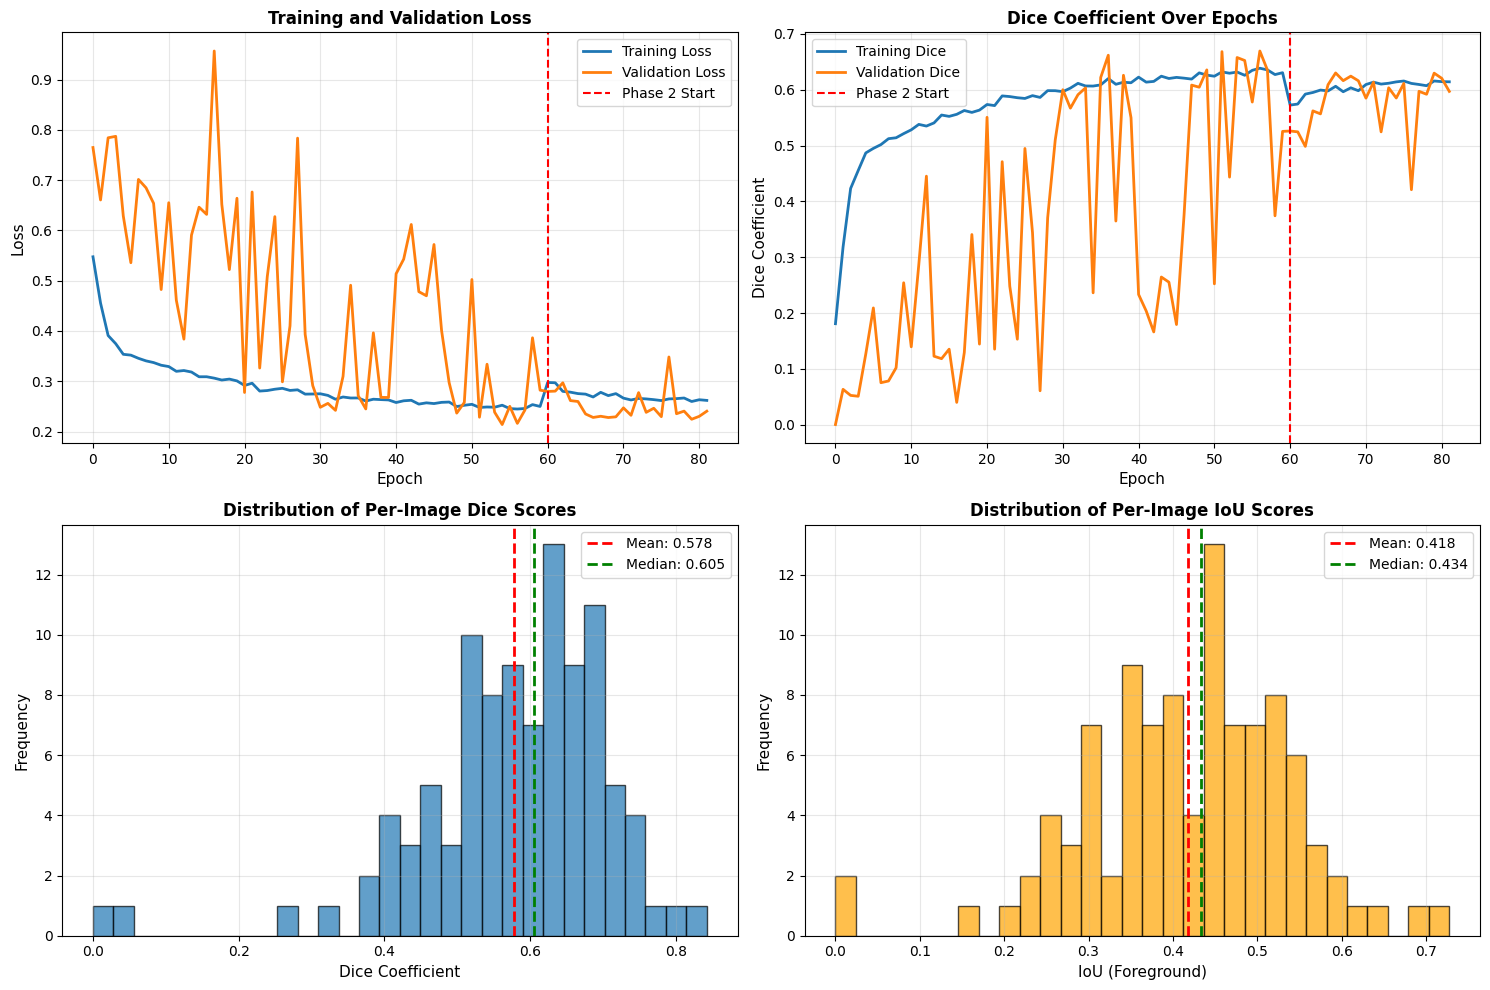

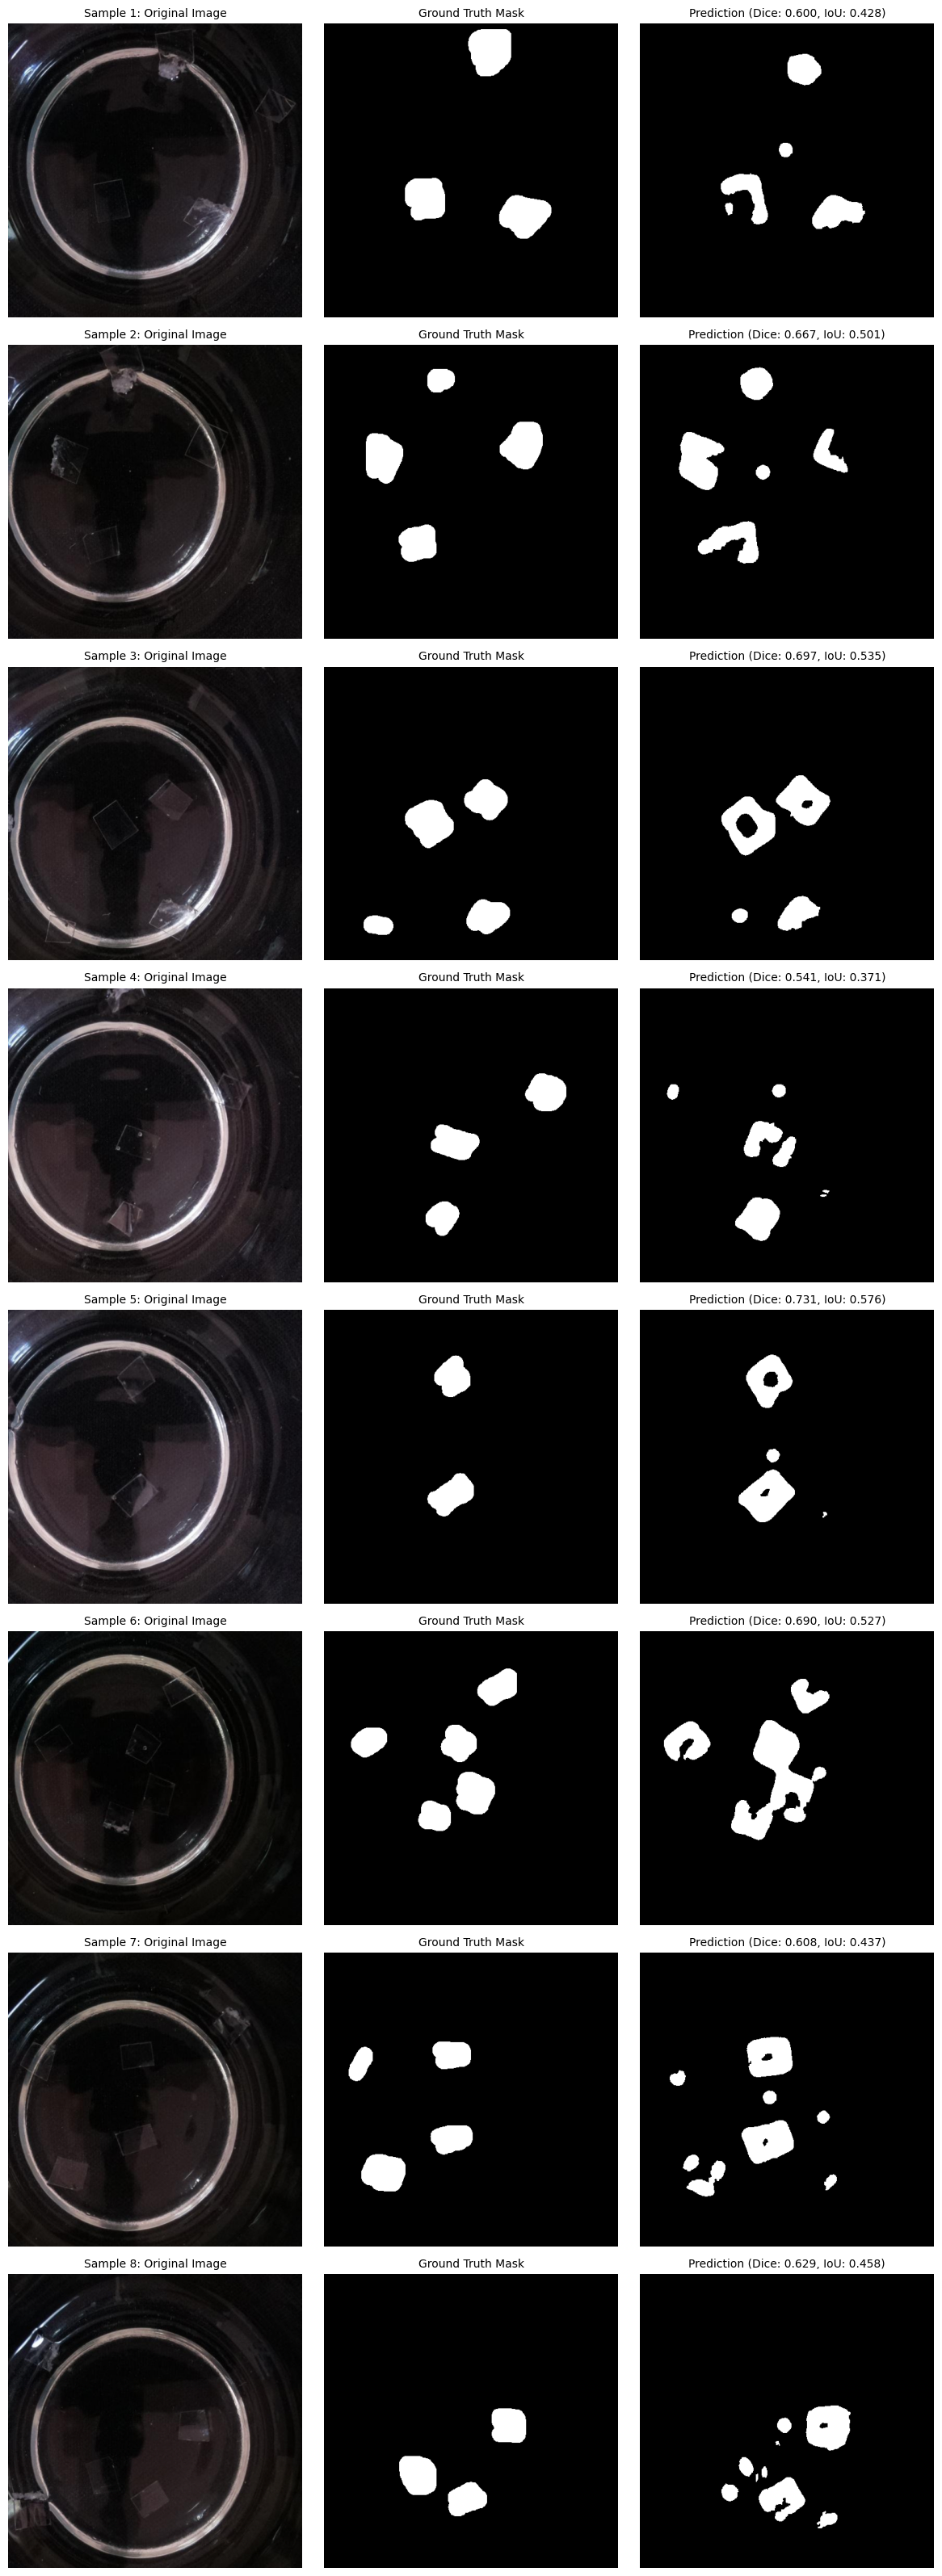

In [6]:
# ============================================================================
# COMPLETE TRAINING AND EVALUATION CODE - SEGMENTATION ONLY
# ============================================================================

# ============================================================================
# FIXED: COMPLETE TRAINING CODE WITH NaN PREVENTION
# ============================================================================

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight

# ============================================================================
# CRITICAL FIX 1: DISABLE MIXED PRECISION (Primary cause of NaN)
# ============================================================================
tf.keras.mixed_precision.set_global_policy('float32')
print("✅ Mixed precision DISABLED - using float32 for stability")

# ============================================================================
# CRITICAL FIX 2: SET SAFE EPSILON
# ============================================================================
SAFE_EPSILON = 1e-7  # Keras default, safe for float32
K.set_epsilon(SAFE_EPSILON)

# ============================================================================
# CUSTOM LOSS FUNCTIONS (NUMERICALLY STABLE)
# ============================================================================

def calculate_class_weights(masks):
    """Calculate class weights for imbalanced segmentation."""
    if masks.ndim == 4:
        masks = masks.squeeze(-1)

    masks_binary = (masks > 0.5).astype(np.uint8).flatten()
    unique_classes = np.unique(masks_binary)

    if len(unique_classes) == 1:
        print(f"⚠️  Warning: Only class {unique_classes[0]} found in masks!")
        return {0: 1.0, 1: 1.0}

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.array([0, 1]),
        y=masks_binary
    )

    n_background = np.sum(masks_binary == 0)
    n_foreground = np.sum(masks_binary == 1)
    total = len(masks_binary)

    print(f"Class distribution:")
    print(f"  Background (0): {n_background:,} pixels ({100*n_background/total:.2f}%)")
    print(f"  Foreground (1): {n_foreground:,} pixels ({100*n_foreground/total:.2f}%)")
    print(f"  Class weights: {{0: {class_weights[0]:.4f}, 1: {class_weights[1]:.4f}}}")

    return {0: class_weights[0], 1: class_weights[1]}


def dice_coefficient(y_true, y_pred, smooth=1.0):
    """Numerically stable Dice coefficient."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    if len(y_true.shape) == 4 and y_true.shape[-1] == 1:
        y_true = tf.squeeze(y_true, axis=-1)
    if len(y_pred.shape) == 4 and y_pred.shape[-1] == 1:
        y_pred = tf.squeeze(y_pred, axis=-1)

    y_true_flat = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_flat = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true_flat * y_pred_flat, axis=1)
    union = tf.reduce_sum(y_true_flat, axis=1) + tf.reduce_sum(y_pred_flat, axis=1)

    dice = (2.0 * intersection + smooth) / (union + smooth)

    # Safety check
    dice = tf.where(tf.math.is_finite(dice), dice, tf.zeros_like(dice))

    return tf.reduce_mean(dice)


def dice_loss(y_true, y_pred, smooth=1.0):
    """Dice loss for binary segmentation."""
    return 1.0 - dice_coefficient(y_true, y_pred, smooth)


def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    """Focal loss for handling class imbalance."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    if len(y_true.shape) == 4 and y_true.shape[-1] == 1:
        y_true = tf.squeeze(y_true, axis=-1)
    if len(y_pred.shape) == 4 and y_pred.shape[-1] == 1:
        y_pred = tf.squeeze(y_pred, axis=-1)

    # Clip predictions
    y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())

    pt = tf.where(tf.equal(y_true, 1.0), y_pred, 1.0 - y_pred)
    alpha_t = tf.where(tf.equal(y_true, 1.0), alpha, 1.0 - alpha)

    focal_weight = alpha_t * tf.pow(1.0 - pt, gamma)
    loss = -focal_weight * tf.math.log(pt)

    return tf.reduce_mean(loss)


def tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, smooth=1.0):
    """Tversky loss - generalization of Dice loss."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    if len(y_true.shape) == 4 and y_true.shape[-1] == 1:
        y_true = tf.squeeze(y_true, axis=-1)
    if len(y_pred.shape) == 4 and y_pred.shape[-1] == 1:
        y_pred = tf.squeeze(y_pred, axis=-1)

    y_true_flat = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_flat = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    true_pos = tf.reduce_sum(y_true_flat * y_pred_flat, axis=1)
    false_neg = tf.reduce_sum(y_true_flat * (1.0 - y_pred_flat), axis=1)
    false_pos = tf.reduce_sum((1.0 - y_true_flat) * y_pred_flat, axis=1)

    tversky = (true_pos + smooth) / (
        true_pos + alpha * false_neg + beta * false_pos + smooth
    )

    return 1.0 - tf.reduce_mean(tversky)


def improved_focal_tversky_loss(y_true, y_pred):
    """Combined focal and Tversky loss."""
    focal = focal_loss(y_true, y_pred, alpha=0.8, gamma=2.0)
    tversky = tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3)

    return 0.3 * focal + 0.7 * tversky


def iou_metric(y_true, y_pred, smooth=1.0, threshold=0.5):
    """IoU metric with per-sample computation."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    if threshold is not None:
        y_pred = tf.cast(y_pred > threshold, tf.float32)

    if len(y_true.shape) == 4 and y_true.shape[-1] == 1:
        y_true = tf.squeeze(y_true, axis=-1)
    if len(y_pred.shape) == 4 and y_pred.shape[-1] == 1:
        y_pred = tf.squeeze(y_pred, axis=-1)

    y_true_flat = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_flat = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true_flat * y_pred_flat, axis=1)
    union = tf.reduce_sum(y_true_flat, axis=1) + tf.reduce_sum(y_pred_flat, axis=1) - intersection

    iou = (intersection + smooth) / (union + smooth)

    return tf.reduce_mean(iou)


# ============================================================================
# CRITICAL FIX 3: ADD NaN DETECTION CALLBACK
# ============================================================================

class NaNTerminator(tf.keras.callbacks.Callback):
    """Terminate training if NaN is detected in predictions."""

    def __init__(self, X_val_sample):
        super().__init__()
        self.X_val_sample = X_val_sample

    def on_batch_end(self, batch, logs=None):
        """Check for NaN after each batch."""
        if logs is not None:
            loss = logs.get('loss')
            if loss is not None and (np.isnan(loss) or np.isinf(loss)):
                print(f"\n⚠️  NaN/Inf detected in loss at batch {batch}!")
                print(f"   Loss value: {loss}")
                self.model.stop_training = True

    def on_epoch_end(self, epoch, logs=None):
        """Check predictions for NaN at end of epoch."""
        preds = self.model.predict(self.X_val_sample, verbose=0)
        if np.any(np.isnan(preds)):
            print(f"\n⚠️  NaN detected in predictions at epoch {epoch}!")
            self.model.stop_training = True


# ============================================================================
# PREDICTION MONITORING CALLBACK
# ============================================================================

class PredictionMonitor(tf.keras.callbacks.Callback):
    """Monitor and visualize predictions during training."""

    def __init__(self, val_data, val_masks, num_samples=4, show_interval=3):
        super().__init__()
        self.val_data_raw = val_data[:num_samples]
        self.val_masks = val_masks[:num_samples]
        self.num_samples = num_samples
        self.show_interval = show_interval

        # Manual preprocessing
        val_data_scaled = self.val_data_raw * 255.0
        self.val_data_preprocessed = (val_data_scaled - 128.0) / 128.0

    def on_epoch_end(self, epoch, logs=None):
        """Called at the end of each epoch."""
        if epoch % self.show_interval == 0:
            preds = self.model.predict(self.val_data_preprocessed, verbose=0)
            preds = np.array(preds)

            if preds.ndim == 4 and preds.shape[-1] == 1:
                preds = np.squeeze(preds, axis=-1)

            if np.any(np.isnan(preds)):
                print(f"\n  ⚠️  [Epoch {epoch}] WARNING: NaN values in predictions!")
                return

            fg_pixels = (preds > 0.5).sum()
            total_pixels = preds.size

            print(f"\n  📊 [Epoch {epoch}] Prediction Statistics:")
            print(f"      Range: [{preds.min():.4f}, {preds.max():.4f}], Mean: {preds.mean():.4f}")
            print(f"      Foreground pixels (>0.5): {fg_pixels:,}/{total_pixels:,} "
                  f"({fg_pixels/total_pixels*100:.3f}%)")

            val_masks_np = np.array(self.val_masks)
            if val_masks_np.ndim == 4 and val_masks_np.shape[-1] == 1:
                val_masks_np = np.squeeze(val_masks_np, axis=-1)

            for i in range(self.num_samples):
                pred_binary = (preds[i] > 0.5).astype(np.float32)
                true_mask = (val_masks_np[i] > 0.5).astype(np.float32)

                intersection = (pred_binary * true_mask).sum()
                union = pred_binary.sum() + true_mask.sum() - intersection
                iou = intersection / (union + 1e-6)

                print(f"      Sample {i+1} IoU: {iou:.4f}")


# ============================================================================
# PREPROCESSING HELPER
# ============================================================================

def preprocess_test_data(X_test):
    """Preprocess test data using the SAME pipeline as training."""
    if not isinstance(X_test, np.ndarray):
        X_test = np.array(X_test, dtype=np.float32)
    else:
        X_test = X_test.astype(np.float32)

    if X_test.ndim != 4 or X_test.shape[-1] != 3:
        raise ValueError(f"Expected (N, H, W, 3), got {X_test.shape}")

    max_val = X_test.max()
    if max_val > 1.5:
        print(f"⚠️  Normalizing from [0, 255] to [0, 1] range...")
        X_test = X_test / 255.0

    X_test_scaled = X_test * 255.0
    X_test_preprocessed = (X_test_scaled - 128.0) / 128.0

    print(f"✓ Preprocessed {len(X_test)} test images")
    print(f"  Input range:  [{X_test.min():.4f}, {X_test.max():.4f}]")
    print(f"  Output range: [{X_test_preprocessed.min():.4f}, {X_test_preprocessed.max():.4f}]")

    return X_test_preprocessed


# ============================================================================
# SEGMENTATION METRICS
# ============================================================================

def calculate_segmentation_metrics(y_true, y_pred, smooth=1e-6):
    """Calculate comprehensive segmentation metrics."""
    y_true = (y_true > 0.5).astype(np.uint8)
    y_pred = (y_pred > 0.5).astype(np.uint8)

    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    tp = np.sum((y_true_flat == 1) & (y_pred_flat == 1))
    fp = np.sum((y_true_flat == 0) & (y_pred_flat == 1))
    tn = np.sum((y_true_flat == 0) & (y_pred_flat == 0))
    fn = np.sum((y_true_flat == 1) & (y_pred_flat == 0))

    precision = 0.0 if (tp + fp) == 0 else tp / (tp + fp)
    recall = 1.0 if (tp + fn) == 0 else tp / (tp + fn)
    f1 = 0.0 if (precision + recall) == 0 else 2 * (precision * recall) / (precision + recall)

    dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    iou_foreground = (tp + smooth) / (tp + fp + fn + smooth)
    iou_background = (tn + smooth) / (tn + fp + fn + smooth)
    miou = (iou_foreground + iou_background) / 2.0

    total = tp + tn + fp + fn
    pixel_accuracy = 0.0 if total == 0 else (tp + tn) / total

    return {
        'dice': dice,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'miou': miou,
        'iou_foreground': iou_foreground,
        'iou_background': iou_background,
        'pixel_accuracy': pixel_accuracy,
        'tp': int(tp),
        'fp': int(fp),
        'tn': int(tn),
        'fn': int(fn)
    }


# ============================================================================
# CRITICAL FIX 4: ADD GRADIENT CLIPPING AND WEIGHT INITIALIZATION CHECK
# ============================================================================

def check_model_initialization(model):
    """Check if model weights are properly initialized."""
    print("\n🔍 Checking model initialization...")

    has_nan = False
    has_inf = False

    for layer in model.layers:
        if hasattr(layer, 'weights') and len(layer.weights) > 0:
            for weight in layer.weights:
                w_vals = weight.numpy()
                if np.any(np.isnan(w_vals)):
                    print(f"   ⚠️  NaN found in {layer.name}")
                    has_nan = True
                if np.any(np.isinf(w_vals)):
                    print(f"   ⚠️  Inf found in {layer.name}")
                    has_inf = True

    if not has_nan and not has_inf:
        print("   ✅ All weights properly initialized")

    return not (has_nan or has_inf)


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Validate required variables
    required_vars = ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test',
                     'train_dataset', 'val_dataset',
                     'build_efficientnetv2b3_mrfm_attention_unet',
                     'IMG_HEIGHT', 'IMG_WIDTH', 'BATCH_SIZE', 'EPOCHS', 'PATIENCE']

    missing_vars = [var for var in required_vars if var not in dir()]
    if missing_vars:
        raise NameError(f"Required variables missing: {missing_vars}")

    # Calculate class weights
    if len(y_train) > 0:
        class_weights = calculate_class_weights(y_train)

    print("\n" + "="*80)
    print("BUILDING MODEL")
    print("="*80)

    model, backbone = build_efficientnetv2b3_mrfm_attention_unet(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )

    print(f"✅ Model built successfully")
    print(f"   Total parameters: {model.count_params():,}")

    # CRITICAL: Check initialization
    if not check_model_initialization(model):
        raise ValueError("Model has NaN/Inf in initial weights!")

    # ========================================================================
    # PHASE 1: Train decoder (backbone frozen) - WITH FIXES
    # ========================================================================

    print("\n" + "="*80)
    print("PHASE 1: Training decoder (backbone frozen)")
    print("="*80)

    backbone.trainable = False

    # CRITICAL FIX: Lower learning rate to prevent gradient explosion
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3,  # Reduced from 2e-3
            clipnorm=1.0         # Gradient clipping
        ),
        loss=improved_focal_tversky_loss,
        metrics=[dice_coefficient, iou_metric]
    )

    print(f"✅ Model compiled for Phase 1")

    # Prepare validation sample for NaN detection
    X_val_sample = X_val[:4]
    X_val_scaled = X_val_sample * 255.0
    X_val_preprocessed = (X_val_scaled - 128.0) / 128.0

    callbacks_phase1 = [
        NaNTerminator(X_val_preprocessed),  # CRITICAL: Add NaN terminator
        tf.keras.callbacks.TerminateOnNaN(),
        PredictionMonitor(X_val, y_val),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_dice_coefficient',
            patience=20,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_dice_coefficient',
            factor=0.5,
            patience=7,
            min_lr=1e-7,  # Increased minimum LR floor
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            '/content/efficientnetv2b3_mrfm_attention_phase1.weights.h5',
            monitor='val_dice_coefficient',
            save_best_only=True,
            save_weights_only=True,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.CSVLogger(
            '/content/training_log_phase1.csv',
            append=False
        )
    ]

    print(f"\nTraining Phase 1 with {len(X_train)} samples, batch size {BATCH_SIZE}")

    try:
        history_phase1 = model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=60,
            callbacks=callbacks_phase1,
            verbose=1
        )
    except Exception as e:
        print(f"\n❌ Training failed: {str(e)}")
        print("\nDiagnostics:")
        print("1. Check if data contains NaN/Inf")
        print("2. Verify data preprocessing")
        print("3. Try simpler loss function (dice_loss)")
        raise

    print("\n📊 PHASE 1 RESULTS:")
    print(f"   Best Dice: {max(history_phase1.history['val_dice_coefficient']):.4f}")
    print(f"   Final Dice: {history_phase1.history['val_dice_coefficient'][-1]:.4f}")



    print("\n" + "="*80)
    print("✅ PHASE 1 COMPLETE - Check if training proceeded without NaN")
    print("="*80)
     # ========================================================================
    # PHASE 2: Fine-tune entire model
    # ========================================================================

    print("\n" + "="*80)
    print("PHASE 2: Fine-tuning entire model")
    print("="*80)

    backbone.trainable = True

    # Unfreeze only last 80 layers
    for layer in backbone.layers[:-120]:
        layer.trainable = False

    # Keep BatchNorm frozen for stability
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    trainable_backbone = sum([1 for l in backbone.layers if l.trainable])
    trainable_total = sum([1 for l in model.layers if l.trainable])
    print(f"Trainable layers in backbone: {trainable_backbone}")
    print(f"Total trainable layers: {trainable_total}")

    initial_learning_rate = 1e-4
    steps_per_epoch = int(np.ceil(len(X_train) / BATCH_SIZE))
    total_steps = steps_per_epoch * EPOCHS

    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate,
        decay_steps=total_steps,
        alpha=1e-6
    )
    optimizer_ft = tf.keras.optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=1e-4,
        beta_1=0.9,
        beta_2=0.999,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer_ft,
        loss=improved_focal_tversky_loss,
        metrics=[
            dice_coefficient,
            iou_metric,
            'binary_accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    print(f"✅ Model recompiled for Phase 2")

    callbacks_phase2 = [
        PredictionMonitor(X_val, y_val, show_interval=2),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_dice_coefficient',
            patience=PATIENCE,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            '/content/efficientnetv2b3_mrfm_attention_final.weights.h5',
            monitor='val_dice_coefficient',
            save_best_only=True,
            save_weights_only=True,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.CSVLogger(
            '/content/training_log_phase2.csv',
            append=False
        ),
        tf.keras.callbacks.TerminateOnNaN()
    ]

    print(f"\nTraining Phase 2 with {len(X_train)} samples, batch size {BATCH_SIZE}")

    history_phase2 = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=callbacks_phase2,
        verbose=1
    )

    print("\n✅ Two-phase training complete!")
    print(f"   Phase 1 - Best Dice: {max(history_phase1.history['val_dice_coefficient']):.4f}")
    print(f"   Phase 1 - Total epochs: {len(history_phase1.history['loss'])}")
    print(f"   Phase 2 - Best Dice: {max(history_phase2.history['val_dice_coefficient']):.4f}")
    print(f"   Phase 2 - Total epochs: {len(history_phase2.history['loss'])}")

    # Performance analysis
    phase1_best = max(history_phase1.history['val_dice_coefficient'])
    phase2_best = max(history_phase2.history['val_dice_coefficient'])
    improvement = phase2_best - phase1_best

    print(f"\n📊 Performance Analysis:")
    print(f"   Improvement from Phase 1 to Phase 2: {improvement:+.4f}")
    if improvement < 0.005:
        print("   ⚠️  Warning: Minimal improvement. Consider:")
        print("      - Reducing learning rate further")
        print("      - Unfreezing fewer layers")
        print("      - Adding more data augmentation")

    # Check train-val gap for overfitting
    if len(history_phase2.history['dice_coefficient']) > 0:
        final_train_dice = history_phase2.history['dice_coefficient'][-1]
        final_val_dice = history_phase2.history['val_dice_coefficient'][-1]
        dice_gap = final_train_dice - final_val_dice

        print(f"\n🔍 Overfitting Check:")
        print(f"   Final Training Dice: {final_train_dice:.4f}")
        print(f"   Final Validation Dice: {final_val_dice:.4f}")
        print(f"   Train-Val Gap: {dice_gap:.4f}")

        if dice_gap > 0.1:
            print("   ⚠️  WARNING: Significant overfitting detected!")
            print("      Recommendations:")
            print("      - Increase weight_decay (try 1e-4)")
            print("      - Add dropout layers to decoder")
            print("      - Use stronger data augmentation")
            print("      - Reduce number of trainable layers")
        elif dice_gap > 0.05:
            print("   ⚠️  Moderate overfitting - monitor closely")
        else:
            print("   ✅ No significant overfitting detected")

    # ========================================================================
    # EVALUATION
    # ========================================================================

    print("\n" + "="*80)
    print("EVALUATING BEST MODEL")
    print("="*80)

    print("Reconstructing model architecture...")
    model, backbone = build_efficientnetv2b3_mrfm_attention_unet(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )

    backbone.trainable = True
    for layer in backbone.layers[:-120]:
        layer.trainable = False

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    steps_per_epoch = int(np.ceil(len(X_train) / BATCH_SIZE))
    total_steps = steps_per_epoch * EPOCHS

    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        1e-4,
        decay_steps=total_steps,
        alpha=1e-6
    )
    optimizer_ft = tf.keras.optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=1e-4,
        beta_1=0.9,
        beta_2=0.999
    )

    model.compile(
        optimizer=optimizer_ft,
        loss=improved_focal_tversky_loss,
        metrics=[
            dice_coefficient,
            iou_metric,
            'binary_accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    print("Loading best weights...")
    model.load_weights('/content/efficientnetv2b3_mrfm_attention_final.weights.h5')
    print("✅ Model weights loaded successfully")

    print("Preprocessing test data...")
    X_test_preprocessed = preprocess_test_data(X_test)

    print("Generating predictions on test set...")
    test_pred_raw = model.predict(X_test_preprocessed, batch_size=BATCH_SIZE, verbose=1)

    # Check for NaN predictions
    if np.any(np.isnan(test_pred_raw)):
        print("\n⚠️  CRITICAL ERROR: Predictions contain NaN values!")
        print("This indicates a serious training problem. Possible causes:")
        print("  1. Gradient explosion/vanishing")
        print("  2. Learning rate too high")
        print("  3. Numerical instability in loss function")
        print("  4. Corrupted model weights")
        print("\nRecommendations:")
        print("  - Check training logs for NaN during training")
        print("  - Reduce learning rate")
        print("  - Check data preprocessing")
        print("  - Add gradient clipping")

        print("\nSetting all predictions to zero to allow evaluation to continue...")
        test_pred_raw = np.zeros_like(test_pred_raw)
    else:
        print(f"Predictions shape: {test_pred_raw.shape}")
        print(f"Predictions range: [{test_pred_raw.min():.4f}, {test_pred_raw.max():.4f}]")


    print("\n Applying post-processing pipeline...")
    print(" This was DISABLED in your original code")

    test_pred_processed = stable_postprocessing(
        test_pred_raw,
        threshold=0.4,
        border_width=5,
        size_percentile=2,
        confidence_threshold=0.25,
        morph_kernel_size=2
    )

    print(f" Post-processing complete")
    print(f" Processed predictions range:[{test_pred_processed.min():.4f},{test_pred_processed.max():.4f}]")

    if len(test_pred_processed.shape) == 4 and test_pred_processed.shape[-1] == 1:
        test_pred_processed = test_pred_processed.squeeze(-1)


    y_test_eval = y_test.copy()
    if len(y_test_eval.shape) == 4 and y_test_eval.shape[-1] == 1:
        y_test_eval = y_test_eval.squeeze(-1)
    # ========================================================================
    # SEGMENTATION EVALUATION
    # ========================================================================

    print("\n Optimizing segmentation")

    best_threshold =0.5
    best_dice =0.0
    threshold_results = []
    for threshold in np.arange(0.3, 0.71, 0.05):
      y_pred_temp = (test_pred_processed > threshold).astype(np.uint8)

      metrics_temp = calculate_segmentation_metrics(
          y_test_eval.astype(np.uint8),
          y_pred_temp
      )

      threshold_results.append({
            'threshold': threshold,
            'dice': metrics_temp['dice'],
            'iou': metrics_temp['iou_foreground'],
            'precision': metrics_temp['precision'],
            'recall': metrics_temp['recall']
        })

      if metrics_temp['dice'] > best_dice:
            best_dice = metrics_temp['dice']
            best_threshold = threshold

      print(f"   Threshold {threshold:.2f}: Dice={metrics_temp['dice']:.4f}, "
            f"Precision={metrics_temp['precision']:.4f}, Recall={metrics_temp['recall']:.4f}")

    print(f"\n✅ Best threshold: {best_threshold:.2f} (Dice: {best_dice:.4f})")

    y_pred_binary = (test_pred_processed > best_threshold).astype(np.uint8)

    seg_metrics = calculate_segmentation_metrics(
        y_test_eval.astype(np.uint8),
        y_pred_binary
    )


    # Display results
    print("\n" + "="*80)
    print("FINAL RESULTS WITH POST-PROCESSING + OPTIMIZED THRESHOLD")
    print("="*80)
    print(f"\n{'Metric':<25} {'Value':<10}")
    print("-" * 40)
    print(f"{'Dice Coefficient':<25} {seg_metrics['dice']:.4f}")
    print(f"{'Precision':<25} {seg_metrics['precision']:.4f}")
    print(f"{'Recall':<25} {seg_metrics['recall']:.4f}")
    print(f"{'F1-score':<25} {seg_metrics['f1']:.4f}")
    print(f"{'mIoU':<25} {seg_metrics['miou']:.4f}")
    print(f"{'IoU (Foreground)':<25} {seg_metrics['iou_foreground']:.4f}")
    print(f"{'IoU (Background)':<25} {seg_metrics['iou_background']:.4f}")
    print(f"{'Pixel Accuracy':<25} {seg_metrics['pixel_accuracy']:.4f}")
    print(f"\nOptimized Threshold: {best_threshold:.2f}")

    # ========================================================================
    # SAVE RESULTS
    # ========================================================================

    os.makedirs('results_efficientnetv2b3_mrfm_attention_512', exist_ok=True)

    print("\n" + "="*80)
    print("SAVING RESULTS")
    print("="*80)

    # Save per-image metrics
    results_df = pd.DataFrame({
        'Image_Index': range(len(y_test_eval)),
    })

    # Calculate per-image metrics
    per_image_dice = []
    per_image_iou = []
    per_image_precision = []
    per_image_recall = []

    for i in range(len(y_test_eval)):
        img_metrics = calculate_segmentation_metrics(
            y_test_eval[i:i+1],
            y_pred_binary[i:i+1]
        )
        per_image_dice.append(img_metrics['dice'])
        per_image_iou.append(img_metrics['iou_foreground'])
        per_image_precision.append(img_metrics['precision'])
        per_image_recall.append(img_metrics['recall'])

    results_df['Dice'] = per_image_dice
    results_df['IoU_Foreground'] = per_image_iou
    results_df['Precision'] = per_image_precision
    results_df['Recall'] = per_image_recall

    results_df.to_csv('results_efficientnetv2b3_mrfm_attention_512/per_image_results.csv', index=False)

    # Save overall performance summary
    with open('results_efficientnetv2b3_mrfm_attention_512/performance_summary.txt', 'w') as f:
        f.write("="*80 + "\n")
        f.write("PERFORMANCE SUMMARY - SEGMENTATION ONLY\n")
        f.write("="*80 + "\n\n")

        f.write("OVERALL SEGMENTATION METRICS\n")
        f.write("-" * 40 + "\n")
        f.write(f"  Dice Coefficient:  {seg_metrics['dice']:.4f}\n")
        f.write(f"  Precision:         {seg_metrics['precision']:.4f}\n")
        f.write(f"  Recall:            {seg_metrics['recall']:.4f}\n")
        f.write(f"  F1-score:          {seg_metrics['f1']:.4f}\n")
        f.write(f"  mIoU:              {seg_metrics['miou']:.4f}\n")
        f.write(f"  IoU (Foreground):  {seg_metrics['iou_foreground']:.4f}\n")
        f.write(f"  IoU (Background):  {seg_metrics['iou_background']:.4f}\n")
        f.write(f"  Pixel Accuracy:    {seg_metrics['pixel_accuracy']:.4f}\n\n")

        f.write("PER-IMAGE STATISTICS\n")
        f.write("-" * 40 + "\n")
        f.write(f"  Dice - Mean:   {np.mean(per_image_dice):.4f} ± {np.std(per_image_dice):.4f}\n")
        f.write(f"  Dice - Median: {np.median(per_image_dice):.4f}\n")
        f.write(f"  Dice - Min:    {np.min(per_image_dice):.4f}\n")
        f.write(f"  Dice - Max:    {np.max(per_image_dice):.4f}\n\n")

        f.write(f"  IoU - Mean:    {np.mean(per_image_iou):.4f} ± {np.std(per_image_iou):.4f}\n")
        f.write(f"  IoU - Median:  {np.median(per_image_iou):.4f}\n")
        f.write(f"  IoU - Min:     {np.min(per_image_iou):.4f}\n")
        f.write(f"  IoU - Max:     {np.max(per_image_iou):.4f}\n\n")

        f.write("TRAINING INFORMATION\n")
        f.write("-" * 40 + "\n")
        f.write(f"  Phase 1 Best Dice:  {phase1_best:.4f}\n")
        f.write(f"  Phase 2 Best Dice:  {phase2_best:.4f}\n")
        f.write(f"  Improvement:        {improvement:+.4f}\n")
        f.write(f"  Total Epochs:       {len(history_phase1.history['loss']) + len(history_phase2.history['loss'])}\n")

    print("✅ Results saved to 'results_efficientnetv2b3_mrfm_attention_512/'")

    # ========================================================================
    # PLOT TRAINING HISTORY
    # ========================================================================

    print("\n" + "="*80)
    print("GENERATING TRAINING PLOTS")
    print("="*80)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Combine phase 1 and phase 2 histories
    all_loss = history_phase1.history['loss'] + history_phase2.history['loss']
    all_val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']
    all_dice = history_phase1.history['dice_coefficient'] + history_phase2.history['dice_coefficient']
    all_val_dice = history_phase1.history['val_dice_coefficient'] + history_phase2.history['val_dice_coefficient']

    # Loss plot
    axes[0, 0].plot(all_loss, label='Training Loss', linewidth=2)
    axes[0, 0].plot(all_val_loss, label='Validation Loss', linewidth=2)
    axes[0, 0].axvline(x=len(history_phase1.history['loss']), color='red', linestyle='--',
                       label='Phase 2 Start', linewidth=1.5)
    axes[0, 0].set_xlabel('Epoch', fontsize=11)
    axes[0, 0].set_ylabel('Loss', fontsize=11)
    axes[0, 0].set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)

    # Dice coefficient plot
    axes[0, 1].plot(all_dice, label='Training Dice', linewidth=2)
    axes[0, 1].plot(all_val_dice, label='Validation Dice', linewidth=2)
    axes[0, 1].axvline(x=len(history_phase1.history['loss']), color='red', linestyle='--',
                       label='Phase 2 Start', linewidth=1.5)
    axes[0, 1].set_xlabel('Epoch', fontsize=11)
    axes[0, 1].set_ylabel('Dice Coefficient', fontsize=11)
    axes[0, 1].set_title('Dice Coefficient Over Epochs', fontsize=12, fontweight='bold')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)

    # Per-image Dice distribution
    axes[1, 0].hist(per_image_dice, bins=30, edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(x=np.mean(per_image_dice), color='red', linestyle='--',
                       label=f'Mean: {np.mean(per_image_dice):.3f}', linewidth=2)
    axes[1, 0].axvline(x=np.median(per_image_dice), color='green', linestyle='--',
                       label=f'Median: {np.median(per_image_dice):.3f}', linewidth=2)
    axes[1, 0].set_xlabel('Dice Coefficient', fontsize=11)
    axes[1, 0].set_ylabel('Frequency', fontsize=11)
    axes[1, 0].set_title('Distribution of Per-Image Dice Scores', fontsize=12, fontweight='bold')
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)

    # Per-image IoU distribution
    axes[1, 1].hist(per_image_iou, bins=30, edgecolor='black', alpha=0.7, color='orange')
    axes[1, 1].axvline(x=np.mean(per_image_iou), color='red', linestyle='--',
                       label=f'Mean: {np.mean(per_image_iou):.3f}', linewidth=2)
    axes[1, 1].axvline(x=np.median(per_image_iou), color='green', linestyle='--',
                       label=f'Median: {np.median(per_image_iou):.3f}', linewidth=2)
    axes[1, 1].set_xlabel('IoU (Foreground)', fontsize=11)
    axes[1, 1].set_ylabel('Frequency', fontsize=11)
    axes[1, 1].set_title('Distribution of Per-Image IoU Scores', fontsize=12, fontweight='bold')
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results_efficientnetv2b3_mrfm_attention_512/training_summary.png',
                dpi=300, bbox_inches='tight')
    print("✅ Training plots saved")

    # ========================================================================
    # VISUALIZE SAMPLE PREDICTIONS
    # ========================================================================

    print("\nGenerating sample prediction visualizations...")

    num_samples = min(8, len(X_test))
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_samples):
        # Original image
        axes[i, 0].imshow(X_test[i])
        axes[i, 0].set_title(f'Sample {i+1}: Original Image', fontsize=10)
        axes[i, 0].axis('off')

        # Ground truth mask
        gt_mask = y_test_eval[i]
        axes[i, 1].imshow(gt_mask, cmap='gray')
        axes[i, 1].set_title(f'Ground Truth Mask', fontsize=10)
        axes[i, 1].axis('off')

        # Predicted mask
        pred_mask = y_pred_binary[i]
        axes[i, 2].imshow(pred_mask, cmap='gray')
        img_dice = per_image_dice[i]
        img_iou = per_image_iou[i]
        axes[i, 2].set_title(f'Prediction (Dice: {img_dice:.3f}, IoU: {img_iou:.3f})', fontsize=10)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig('results_efficientnetv2b3_mrfm_attention_512/sample_predictions.png',
                dpi=200, bbox_inches='tight')
    print("✅ Sample predictions saved")

    print("\n" + "="*80)
    print("TRAINING AND EVALUATION COMPLETE")
    print("="*80)
    print(f"\n📊 Final Results:")
    print(f"   Segmentation Dice:      {seg_metrics['dice']:.4f}")
    print(f"   Segmentation Precision: {seg_metrics['precision']:.4f}")
    print(f"   Segmentation Recall:    {seg_metrics['recall']:.4f}")
    print(f"   mIoU:                   {seg_metrics['miou']:.4f}")
    print(f"   IoU (Foreground):       {seg_metrics['iou_foreground']:.4f}")
    print(f"   Pixel Accuracy:         {seg_metrics['pixel_accuracy']:.4f}")
    print(f"\n✅ All results saved to: results_efficientnetv2b3_mrfm_attention_512/")
    print("="*80)